In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# reader = Reader()
# # file_name= "./cornac/data_c/indexed_interactions.csv"
# file_name= "biased_movie_lens.csv"
# rating_data_pd = pd.read_csv(
#     file_name,
#     sep=",",
#     header=None,
#     names=["_","userID", "itemID", "Rating", "Timestamp", "movieID","genres","Drama","Children's","Action","War","Documentary","Animation","Comedy","Sci-Fi","Romance","Musical","Western","Crime","Thriller","Adventure","Fantasy","Mystery","Film-Noir","Horror","Gender"],
#     dtype={"userID":int, "itemID":int, "Rating":int, "Timestamp":int, "movieID":int,"Drama":float,"Children's":float,"Action":float,"War":float,"Documentary":float,"Animation":float,"Comedy":float,"Sci-Fi":float,"Romance":float,"Musical":float,"Western":float,"Crime":float,"Thriller":float,"Adventure":float,"Fantasy":float,"Mystery":float,"Film-Noir":float,"Horror":float, "Gender":int}
# )
# rating_data = rating_data_pd[["userID","itemID","Rating","Timestamp"]].to_numpy()
# rating_data
# # rating_data = rating_data.drop(columns=rating_data.columns[-1])
# # ,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
# rating_data_pd
# # user id itemid rating and timestamp

In [3]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [4]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [5]:
movies = movies.drop(columns=["movieID"])

In [6]:
movies = movies.sort_values(by="itemID")

In [7]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [8]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
# movies = pd.read_csv("./cornac/data_c/ml-100K/indexed_movies.csv")

# movies = movies.drop(columns=movies.columns[0])
# movies[:4]

# unique_genres = set("|".join(movies["genres"]).split("|"))
# unique_genres = list(unique_genres)
unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
# for genre in unique_genres:
#     movies[genre] = 0
# for index, row in movies.iterrows():
#     genres = row["genres"].split("|")
#     for genre in genres:
#         movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
# item_features = {
#     str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
#     for item_id, row in enumerate(item_features_numpy)
# }
# ids = list(range(0, 3416))
# item_feature_modality = FeatureModality(
#     features=item_features_numpy, ids=ids, normalized=True
# )


users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")
users
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
# user_feature_modality = FeatureModality(
#     features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
# )

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

In [9]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [10]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [11]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data
unique_genres.__len__()

18

In [12]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df

In [13]:
# genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
# genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# # upper_bound = inter_movies.shape[0]
# indices_to_delete = set()
# mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
# mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
# mask_f = inter_movies.index[mask_f]
# mask_m = inter_movies.index[mask_m]
# upper_bound_m = mask_m.__len__()
# upper_bound_f = mask_f.__len__()
# for i in range(100000):
#     rm=random.randint(0, upper_bound_m-1)
#     rf=random.randint(0, upper_bound_f-1)
#     indices_to_delete.add(mask_f[rf])
#     indices_to_delete.add(mask_m[rm])

# inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# # sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [14]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]
user_features_numpy[:, 0]
# item_features_numpy[0]

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,

In [29]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()


models = []
# alpha_values = [0, 0.1,1,10]

alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
# alpha_values = [10000,0]
# alpha_values =[0,0.5]
# alpha_values = [0,10,50,100, 500,1000,1500, 2000 , 2500, 3000, 4000, 5000, 5500, 60000, 7000, 7500, 8000, 9000, 10000, 200000 ]
# alpha_values = [0, 0.5,0.8,1]
# alpha_values =[0,0.8]

# lr_values = [0.01]
# alpha_values = [ 0,  0.1,    1,     10,   100,    500,    750,     1000,    2000,   3000,    5000, 7500, 10000]
# alpha_values = [0,   0.1]
lr_values =    [0.0005, 0.0009, 0.0007, 0.0007, 0.0006, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001, 0.00005, 0.00003, 0.00001]

#kheyarocks
for i in range(len(alpha_values)):
    # learning
    models.append(
        MF(
            k=20,
            seed=123,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",
            alpha=alpha_values[i],
            learning_rate=0.001,
            top_k=50, max_iter=100
        )
    )
# models.append(MF(
#     k=20,
#     seed=123,
#     name=f"a={0} mf",
#     backend="pytorch",
#     verbose=True,
#     optimizer="adam",
#     alpha=0,top_k=50,
#     learning_rate=0.01,
# ))
# models.append(MF(
#     k=20,
#     seed=123,
#     name=f"a={0.4} mf",
#     backend="pytorch",
#     verbose=True,
#     optimizer="adam",top_k=50,
#     alpha=0.4,
#     learning_rate=0.1,
# ))


model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 = MF(
    k=20,
    seed=123,
    name=f"a={0} mf",
    backend="pytorch",
    verbose=True,
    optimizer="adam",max_iter=25,
    alpha=0,
    learning_rate=0.001,
)
model_4 = VAECF(
    k=20,
    autoencoder_structure=[100],
    act_fn="tanh",
    likelihood="mult",
    n_epochs=100,
    batch_size=100,
    learning_rate=0.001,
    beta=1.0,
    seed=123,
    verbose=True,
)
model_5 = LightGCN(
    seed=123,
    verbose=True,
    emb_size=64,
    num_epochs=600,
    early_stopping={"min_delta": 0.001, "patience": 20},
)

# models = [model_1, model_2, model_3, model_4, model_5]
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([   0,    1,    2, ..., 1181,  182,  175]), array([4., 4., 4., ..., 4., 3., 4.]))
Number of users = 943
Number of items = 1349
Number of ratings = 79045
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (627, 55), (621, 56),

100%|██████████| 20/20 [00:04<00:00,  4.93it/s, loss=0.527]


[306.0464782714844, 342.1849365234375, 302.4686584472656, 295.2138671875, 326.7811279296875, 325.9599609375, 271.9602355957031, 308.7167053222656, 337.1856689453125, 297.573974609375, 283.3768615722656, 289.5381164550781, 316.951904296875, 302.04217529296875, 271.8714599609375, 306.5566711425781, 298.7339172363281, 296.51800537109375, 322.9667053222656, 304.9065246582031, 294.3880920410156, 274.53594970703125, 315.3965759277344, 275.6567687988281, 289.5830383300781, 278.09478759765625, 274.8415832519531, 324.7020568847656, 326.63653564453125, 283.2771911621094, 313.38616943359375, 349.0744323730469, 316.4858703613281, 285.00872802734375, 336.644775390625, 353.6553649902344, 306.6543884277344, 297.857177734375, 327.77947998046875, 296.2918395996094, 309.24029541015625, 302.7019348144531, 303.89288330078125, 276.2209777832031, 300.55560302734375, 319.861083984375, 339.8202209472656, 313.76898193359375, 311.02740478515625, 316.5869445800781, 322.82257080078125, 302.04217529296875, 331.012

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2188.08it/s]



[a=0.1 mf] Training started!


...


[a=1 mf] Training started!


100%|██████████| 20/20 [2:19:15<00:00, 417.77s/it, loss=0.0345]    


[428.70542534092795, 339.06980165803685, 348.9065328480759, 439.32392218033687, 325.06492906962563, 482.2046466146354, 231.0454231734835, 333.474366196, 319.7902044996183, 262.8260622473168, 287.639123204838, 254.37616326530627, 283.9197780909904, 253.455166247159, 177.19246152486983, 304.16316208253573, 210.53785200881276, 329.1707473081511, 383.6512201348531, 307.7035886868768, 251.41897425005942, 306.9252913904416, 382.20956288156304, 293.26170251884554, 284.0160031758063, 309.47903482013686, 318.6602504984097, 242.6260520104925, 278.5370689256838, 220.3480128893667, 251.97293924466342, 456.95019287605237, 293.0356315499173, 219.42067350430122, 223.1190016332877, 256.0803617010967, 272.3364988722559, 403.9043255594976, 338.89162014011924, 216.80990712274055, 296.8345176955594, 296.7196615878321, 258.7501204441532, 226.94429024943327, 377.4120745601474, 251.02752619143573, 417.17114665686097, 288.5527354000306, 298.3935303110389, 244.8434164464439, 330.6741731175231, 224.472395761025

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2519.50it/s]


TEST:
...
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 0.9496 | 0.5751 |      0.6638 | 0.0519 | 0.1983 |  0.0942 |       0.0462 |    0.1156 |    4.0811 |   0.5796
a=0.1 mf | 0.9487 | 0.5746 |      0.6628 | 0.0521 | 0.1983 |  0.0946 |       0.0467 |    0.1163 |   78.9054 |   0.5221
a=0.2 mf | 0.9481 | 0.5740 |      0.6649 | 0.0523 | 0.2007 |  0.0957 |       0.0474 |    0.1178 |   74.9921 |   0.5396
a=0.3 mf | 0.9476 | 0.5731 |      0.6670 | 0.0528 | 0.2024 |  0.0967 |       0.0480 |    0.1195 |   77.3394 |   0.5548
a=0.4 mf | 0.9477 | 0.5717 |      0.6702 | 0.0529 | 0.2021 |  0.0977 |       0.0487 |    0.1217 |   79.6838 |   0.6393
a=0.5 mf | 0.9488 | 0.5699 |      0.6755 | 0.0529 | 0.1971 |  0.0976 |       0.0492 |    0.1224 |   80.1330 |   0.6858
a=0.6 mf | 0.9516 | 0.5669 |      0.6

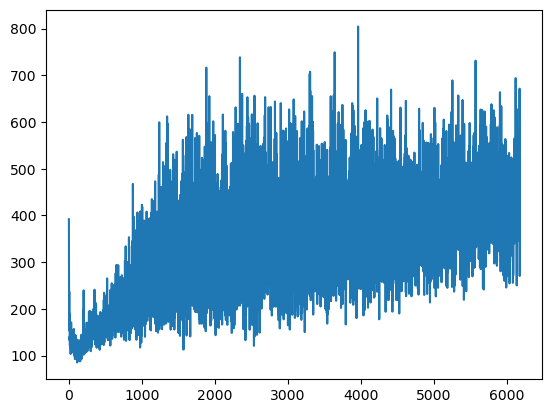

In [30]:
y =  [391.9077473236105, 261.4503517733069, 253.825604915793, 184.72090350950825, 199.73288816033318, 236.96334359810723, 153.98268984598903, 190.4063126474656, 158.38658041442773, 162.6054782086774, 160.46759405065472, 132.61406054687495, 141.63058201535125, 138.9622940676065, 120.83092886814923, 139.82580466288852, 117.62716716795954, 121.43728624375703, 123.66947009467971, 124.06450722774326, 122.79850682340708, 118.93422836400916, 127.41007985067759, 115.72710687035917, 103.52878430407844, 136.18696796763155, 121.34776670155837, 131.23773737551258, 134.8884105916853, 121.0234773245474, 126.93976854907503, 171.2917629967178, 124.29852114050938, 112.18042782596396, 147.11437378878162, 137.6760936067354, 132.39087237672194, 105.87766560460268, 140.35846324912347, 131.00474678586022, 135.6588043270111, 123.35846665092993, 154.5447018770382, 119.70444441053624, 118.51795176200575, 118.64293430774393, 127.14007029032209, 132.98040416701843, 128.2222111246508, 126.23187374438056, 133.45929184486127, 133.07672753712484, 116.77618922587467, 124.93960211513661, 129.42354408697435, 110.69632937874003, 110.19894812374132, 134.66733843416065, 122.69850363915592, 120.54737972451126, 123.69151349492238, 120.41308478722172, 132.46106799977065, 120.27301478608766, 133.87066325229316, 116.90871947663334, 117.74866699259613, 125.7960479981875, 157.03453965770018, 106.7220584974217, 120.10729360686386, 109.33381992436412, 99.92186840534771, 126.6805343888765, 113.39460703105391, 129.30611505522526, 114.18715080848091, 140.58268899982136, 114.05337583720862, 122.83804160603013, 125.82281043807575, 102.83082571707449, 116.71195950089111, 92.6091051432289, 138.72043194377085, 121.55663703027183, 121.60555033863845, 133.68933080841109, 130.10024189975408, 102.45635309606759, 144.19652909398295, 106.78542716802048, 117.82135210733841, 112.95607241985098, 108.29726463693461, 115.93781400251598, 105.88769661543284, 119.10515563185112, 122.10712382553547, 118.4531602028538, 134.03633292583132, 135.90607927229024, 116.40173277837303, 127.92074696378785, 119.2749235690099, 102.99970332969653, 93.54878566573154, 108.09766323691909, 102.87694983816299, 112.06633797339217, 105.16055267487515, 86.05372622826161, 85.36029394594968, 127.39590370642364, 105.53591787351644, 116.01456317745445, 113.07487091537602, 111.26262577067193, 132.90473218521197, 111.02253549464253, 98.48576617900025, 127.64810502018604, 107.33169160500532, 122.55825289451748, 123.07507732512295, 132.74551960675865, 110.09250388395651, 104.60798905806101, 100.9565209072453, 97.59642139443261, 98.45364060233136, 90.05832340859925, 105.94380651896438, 111.4520964313835, 89.82238905217788, 97.99731513447722, 88.02374225844667, 102.71706354815268, 121.84963423797146, 98.31737895580821, 108.39425600065462, 112.75958273051715, 111.86381333084799, 100.75204955546972, 110.83867924117925, 95.1282833894357, 114.5182623778327, 113.48168740906833, 109.0652176616494, 100.47317030272, 132.9701217594377, 104.50579596744026, 105.14968357130041, 87.84986067345166, 108.54946099175332, 91.12344679822101, 89.55683172346596, 96.62449240224628, 94.48719582532463, 99.9052676688167, 96.6617336611935, 103.91233165155722, 108.06909751548432, 100.3599651908859, 122.871198436441, 109.17736158183979, 107.9499675588897, 104.84152409963878, 119.67978456424783, 125.4546438634942, 128.2901682407853, 99.16240134171494, 144.86156378250794, 128.29665277426147, 125.87930255791206, 93.41957404599566, 115.27092943905467, 105.01028715203351, 130.8833072865313, 104.2384733321489, 126.77975397380104, 115.58045227536441, 112.53040516678001, 130.03477552321846, 127.53800169117372, 102.92067727607585, 107.26189601978969, 101.70707282616719, 129.9573654711665, 102.56848381288717, 123.50018112186649, 104.37951350771155, 113.29221911364387, 113.62086942020935, 151.24329332090548, 130.56813664590888, 106.95044539544512, 111.28247809578835, 197.78299234795082, 169.9660174851395, 162.9400406919248, 107.60522133955993, 239.68182411737232, 144.3420263134459, 125.963668415934, 154.28141358162162, 144.42909959117154, 104.31828591813493, 102.53519233547495, 120.33151840424867, 117.88226810300588, 121.77576773633312, 104.83401402112655, 120.8745969993844, 121.05203169437857, 120.04930545383033, 112.92060235021854, 114.01950666639509, 111.88566355755651, 117.08783523959268, 143.2670823065228, 127.07104410160545, 114.10924554122161, 106.00133786975825, 134.30177696637202, 119.59573374809845, 143.0163534045816, 132.88640598549443, 148.642491215037, 147.33046285377378, 155.74401667937363, 119.45299960432382, 119.42247787300172, 124.46260009431839, 154.0435494492457, 135.9045315024295, 125.94989828896686, 114.76296108349727, 120.19348684788322, 107.66429340101814, 107.61878937658115, 147.70232706504902, 112.29647165197096, 170.7443352121049, 122.07078230211023, 122.43838717794948, 131.73106021871058, 136.04875932412327, 118.0495860368222, 134.7246420376103, 111.77557019667971, 127.70641207066188, 134.57544014064757, 116.06276591467449, 117.24698173078919, 145.60181260850712, 128.2823816171785, 147.27238884417324, 140.61565573069953, 119.01807791265712, 110.92935413681617, 162.63486585829014, 152.467268257731, 123.27873585107353, 154.66268664344565, 167.5352283358613, 140.38260933362326, 153.2020356705416, 116.68306251857601, 135.007018220394, 145.63768620101555, 123.55357957116195, 125.73770102761027, 147.0999503766676, 141.8208429787, 194.32430730514375, 122.24119786408389, 144.43280991562858, 168.99319296615633, 177.59541011919816, 132.85902908400806, 142.1239779544951, 181.14265767415353, 160.5376503379839, 146.17810770670582, 140.65913522712287, 169.1163917091229, 150.55352393934476, 195.62086296183907, 152.98721577474913, 173.84355431279775, 155.0594716661242, 141.2540669616105, 169.4651225808139, 146.24328851052834, 163.36202917405103, 141.07652639816558, 156.8434105175919, 136.1377728454067, 109.42715781550513, 143.10474352159002, 162.84253829930975, 137.645528246404, 158.44299253605737, 150.80799961922162, 149.94499401739336, 164.7652725903913, 134.5737938917515, 117.31107952996646, 120.62388078189048, 143.50144319738504, 153.70998941902872, 141.94470555862296, 155.42095243831474, 137.7729406536537, 124.2702224338824, 137.07446728667583, 129.1533083270039, 135.64270024375838, 156.4520884769964, 148.73534747619829, 136.5991557992157, 192.8616648571898, 145.93861612789908, 194.19324024742468, 178.7199801378751, 139.04791797754376, 145.83548849337308, 172.78054578926873, 161.7130666366043, 195.89714152961147, 146.1429376670876, 159.55768167571267, 199.4180888380153, 173.5515859058521, 161.80001488433754, 181.084248501707, 173.5472313507257, 141.09682200294202, 146.7385993392251, 146.47193442789717, 168.03660414258678, 156.85724841236737, 162.0670607187556, 143.21349732903505, 147.48530874096488, 186.79683065106786, 221.9855095331145, 165.61840957984393, 162.00660798313365, 133.91103005883895, 241.01680311168315, 193.73798051375513, 176.796174209837, 207.07290834255934, 158.84702853477717, 170.78474556489192, 218.73770731741052, 150.1745935152207, 124.17805730289257, 186.66782410395666, 179.52974828675292, 177.29695549219147, 169.91819965048794, 156.4213985596033, 151.7135177205402, 126.57552393788532, 212.84618638258695, 137.96728488279174, 169.72310046885764, 140.63498265316605, 193.31668051546626, 209.33887647904675, 133.84044374807283, 149.6124976329911, 157.39784225335285, 138.28736070237747, 159.89631089274087, 148.6333870359623, 146.27575045571277, 116.95419209262793, 182.73274187915604, 147.11738885681024, 127.61613913883112, 158.18770892975377, 137.7068108152614, 124.64538664507248, 141.4175917593974, 130.87130629387426, 163.78348249400776, 185.67035391564704, 131.10370193303785, 168.63154195335457, 142.87397787721153, 154.67723382402409, 153.95823841745414, 174.525910531955, 181.74382021651292, 158.38533303599365, 128.80920289412796, 169.84173388779118, 138.01443408373888, 128.40881825764984, 147.5039238891485, 133.71932415486384, 135.75977118598078, 117.46191471203471, 147.80104275843337, 183.7356560373015, 130.3754682005986, 156.95504972671742, 144.86504763060213, 138.0224865086182, 166.81795948159873, 161.31781206356604, 116.93147256042872, 141.72095537010904, 134.7614499797689, 138.80450275904943, 137.40382142314093, 146.45129958263976, 144.8569304882967, 112.59274238716705, 159.88534796000022, 136.92242461282348, 180.15522000131745, 178.488961902242, 119.96187375123503, 140.30521140871323, 127.02900498642421, 188.96508658645507, 180.87168731953977, 193.4734539900155, 186.6701694574568, 143.57753130537733, 161.11957915270511, 183.27846535523935, 163.43054177593234, 173.19627356560696, 174.8292534329098, 161.20088889220293, 142.89170808932923, 139.87051971105637, 124.632106287402, 124.37745478634798, 181.11555494625895, 142.59938883286142, 142.60794595138705, 164.23200664008522, 163.1314440917967, 149.60282483882577, 164.59976061542193, 135.4731721099834, 184.16317226798077, 163.43005806413254, 171.0576858423197, 165.36953075077685, 138.75871775961474, 177.99599976486383, 187.855187157994, 146.47002569681237, 138.06206523391882, 140.86868448559346, 144.39163968797772, 129.33509965797447, 153.37638919353356, 165.2559632273447, 186.19955330521572, 145.58243438376405, 161.41825642943854, 187.44624498011092, 197.20946201079113, 151.11250706977427, 155.96099260874973, 140.94911564546112, 181.42043127291714, 123.58357556743937, 151.01870992295713, 219.07882539993898, 162.66679735572723, 193.45901399194338, 123.54167311267064, 161.5511558949864, 234.42736733786455, 198.90905935070458, 162.1338371381217, 128.40097458596463, 146.22204242992532, 145.08364840385565, 168.3546249852036, 149.89629044065356, 148.12690080873028, 154.44336768663197, 150.83232782924927, 164.15752294146827, 209.94026562319166, 228.00108180119415, 164.12733556914736, 144.37348265288975, 195.7514354799411, 169.11847460544607, 145.05193434787347, 160.37923231912595, 169.1584365170425, 194.8057445463882, 184.82467345874363, 206.25197196097426, 210.59538071702795, 142.17378097187822, 153.88326897596744, 178.2381287115202, 140.35239432062681, 169.99620801846947, 150.80759329237893, 180.67138642801143, 152.9539391960258, 228.44265658601873, 155.31854058684235, 153.57798751406847, 167.21229623094538, 173.94626426752123, 150.6524599977863, 160.5661063392934, 203.81256883027046, 265.2134168377401, 224.62047152951283, 153.53195775125198, 172.2159051325042, 161.50530875800456, 164.87501337042733, 180.4880873481108, 144.9622790506728, 136.69489081774816, 136.71770997265122, 183.52736171645617, 133.2212518410279, 169.57345325083898, 165.9363760309282, 203.52491727079226, 164.54065587069312, 146.0503961798159, 199.3363425428601, 184.364452156169, 170.7003988839025, 142.14854703362766, 172.68817025346368, 155.22985925948896, 176.90473463270408, 202.84881589263082, 170.0738412790744, 181.56523256086416, 198.06804298662865, 207.87550132816685, 160.91561591382288, 155.46567901387536, 165.47792068011114, 146.61221274531192, 136.0190298588243, 133.45999279938945, 174.73467477283253, 172.06337657296683, 205.01556062203468, 176.3470988075406, 173.92336498483843, 188.61345207188313, 166.14114425036678, 173.0391751185157, 161.9027044848512, 121.58997220747415, 191.80612069878913, 170.95222857671598, 240.79023535727327, 174.62308713555944, 179.43959942615044, 177.03166053148072, 141.67076799196946, 177.23443518169523, 177.301378136594, 172.01888438646694, 136.68575404116996, 230.30582230640528, 191.39118023517045, 153.6942909078404, 230.89468719270684, 164.5180292682503, 198.29140299317675, 166.2793895472214, 254.71818482070316, 171.65598794263775, 186.97398291095394, 205.07308591345574, 137.74912944406702, 151.75381578528794, 135.86145327716523, 156.33034575784635, 165.26979799068863, 224.65437302200888, 162.4534527357381, 188.430212334658, 181.18718124126923, 186.07911907257264, 221.41370749379385, 162.26776814072952, 227.8405101065008, 196.0015882607748, 191.77788556660644, 157.0563563624434, 162.0597325495757, 216.711018651234, 176.8911632135696, 216.2250794160721, 193.94242358912908, 152.79508039431462, 219.79631227112307, 202.1179847544675, 206.0958285501858, 161.26253922816653, 172.73978422823052, 193.1343710239061, 206.3828975503971, 173.02378337740157, 164.55903671315772, 166.61471059030717, 251.8077365510083, 191.97779777018252, 184.2308915045528, 162.72470874602485, 198.65992125079816, 195.72559777934296, 177.79524827919096, 141.5348981283645, 158.8444530729384, 208.9148653238494, 193.7679655169452, 157.1674150105793, 226.42148388308033, 224.02748427898558, 138.774684469346, 188.97004634863686, 200.48277401695879, 166.83058219473543, 276.35999557022643, 168.8664429173323, 177.76990239947207, 215.13918097318734, 179.2845304452487, 162.83799137783953, 233.17791420014802, 222.00733574307125, 178.16541171295444, 236.864224092772, 163.5481975008459, 172.69292719776485, 294.19994459770146, 186.285196302133, 151.89072957046136, 230.20999889189838, 221.84165434833773, 194.12846266374737, 238.87506392033063, 189.24494574395533, 222.74443459664124, 199.32489964887304, 251.40685956265645, 258.786806549055, 260.99353876602305, 164.5407052431153, 154.80371256822744, 151.1180405369177, 219.34119716388932, 207.02164070913764, 242.93510614013678, 281.6798759781969, 197.3911738236695, 220.79472486662246, 177.33411514391594, 293.4223834635418, 176.2914358641121, 190.390478907101, 153.80526087834264, 185.40536810598218, 221.48433187958702, 235.50696495498684, 215.32561230115442, 203.41814185124846, 174.3568833613229, 150.60906502414286, 246.22980177098657, 240.15327076613386, 159.96438010001995, 242.09727325227593, 165.49071630092502, 172.6730653305263, 256.7554612000281, 211.77478698454624, 198.69132326162543, 154.37038970703514, 183.31921977922042, 169.63336722959446, 172.21375829791606, 239.97590476428272, 166.93733765490316, 240.9947504280301, 184.6641826196843, 204.73803440318352, 267.9646521531491, 217.0271048950143, 240.34763982390544, 196.03748820393878, 204.64280236791737, 170.3126281612118, 210.82191358499637, 190.9511241993179, 235.34914363878042, 248.37583742001326, 203.2576717989238, 159.16929496232405, 140.54219844155693, 201.75883441902886, 239.26581987816587, 184.01985407579235, 199.33205391061546, 183.3403814958151, 230.66497953856248, 193.16667758167637, 235.5803164117166, 272.06665507918467, 249.5538844120385, 148.77520545372596, 265.1371973325129, 249.58415822723765, 197.78722257322275, 195.31979911231002, 154.23326300727, 182.5556434006418, 226.78101131779223, 231.92980537574914, 185.41581020170216, 203.45445666183392, 200.88756693594573, 222.69156462301166, 211.98807554650062, 183.83338094354832, 186.92592935356038, 242.10756494940534, 169.11860976845657, 181.26527741013092, 203.08736897409688, 152.0231610661176, 193.36831804632362, 183.94095332533482, 228.08552839530444, 192.2724988888472, 182.79894889856786, 263.0175259562348, 133.93907475523443, 265.9141676088535, 246.3014720884747, 180.83431995620074, 262.592419250944, 220.90520005621357, 146.0344453992446, 222.47236442673793, 189.19873662437533, 236.31655371674952, 216.7842084404283, 153.55840620904905, 187.45056361797484, 302.2117425894773, 261.1732974906019, 291.96779817764616, 258.2115618240561, 261.4492281780709, 266.62468070585743, 255.68735732365738, 256.30019202765635, 202.69046351321506, 266.94462677714813, 333.9277775638941, 244.34914875753879, 246.027649657226, 188.73843997038063, 218.56947622496256, 202.44673534439917, 131.65409589683776, 188.2602435872385, 176.05217086309318, 253.83286676393988, 167.47115635396676, 277.59570676698416, 195.14517967549045, 224.53605414367163, 198.90269599838024, 182.62628954848364, 154.66593373581912, 276.726743039981, 255.50801197368423, 265.76335877369064, 271.1926259836632, 201.91653719220832, 221.80139091289814, 178.68003778427735, 216.65892001667285, 300.012852678183, 174.09857290942145, 168.76095691031793, 216.62840347453647, 182.4452011384002, 162.37619341133558, 189.73516301750078, 297.3226636647192, 228.04769699129957, 228.15445909104915, 181.73059323952458, 234.9257606278732, 169.15714773293303, 186.25056993076623, 241.66630692332964, 152.7497650180734, 167.8937985794208, 204.6132974829633, 173.43322865870556, 253.38892278118226, 353.44000111027674, 174.88601894286495, 224.97008067623014, 236.57640336940617, 164.36633525446234, 164.49828614144465, 181.7504277349872, 163.2876025524222, 133.35759652084508, 221.38973534728635, 206.13633553857258, 201.6425261314513, 249.2726963438513, 231.7477771135073, 194.6867916977196, 246.54587166451086, 243.9739717271594, 273.57709611987053, 183.1991410384771, 190.03496361443223, 278.9151975836085, 285.5531057527321, 172.0561840900999, 213.0031124362328, 187.3057569926301, 148.13264722569315, 221.63835170685306, 189.77289538225415, 249.98662965194035, 167.40942929842626, 294.2072257527671, 247.30602858497213, 162.62701770028423, 279.17059967048107, 204.95415142611807, 218.43274180762947, 212.02029652737212, 157.87046112032124, 261.06370263644914, 233.03601603740887, 335.08446566936055, 184.10595062559352, 200.0024460616614, 267.3353005336827, 265.88018764986214, 172.5678329694049, 199.1881921317046, 308.3246766690694, 345.4092698544845, 245.0161357448827, 203.51410459737028, 207.18715001965242, 289.967228489425, 229.05433988804515, 467.414670205241, 300.34992197242735, 318.64568271924185, 300.3435071749042, 324.5606255781241, 225.44913691243818, 162.3206388954216, 384.1008272579547, 231.6067416596665, 248.2128151691935, 304.3602467856043, 218.1242661311601, 397.0363449067665, 374.8213818827454, 206.33347522181327, 241.55013499776126, 347.4811184461523, 252.78783643916975, 210.20188151610003, 253.6137228944325, 166.69310675543716, 238.48161247567586, 320.51273248094117, 298.6068252842624, 231.33340546332485, 242.08849748306636, 305.97878952221924, 268.7377825667427, 236.0588670405638, 199.58455698386584, 368.4812625618655, 156.12799433255384, 317.4015207675123, 313.5872051655057, 207.68996310122373, 295.7946778915116, 239.4476955819347, 366.19920663198445, 305.76788570543505, 219.57315275307448, 326.50773582319744, 223.3699408553744, 201.93956238073406, 194.3719941230669, 339.6943858586237, 162.65390768498247, 178.71441810019166, 186.80009066733118, 133.92184582601232, 208.2111608920892, 280.1267112295692, 209.78395804850294, 146.9148426448043, 315.16602831041513, 233.23619131348306, 169.39809821440937, 224.94019191598508, 296.2829301170766, 289.4720450701033, 198.00569786003032, 385.2949429779429, 236.14213803794874, 406.3342018476498, 231.1776548040979, 350.9744088714657, 348.20710770971965, 159.0478798246608, 324.42555428407246, 188.88698090261462, 247.38240901917615, 200.68461022202393, 387.05054771411073, 274.40105026129896, 332.9752296654713, 264.59413872897255, 166.88658977783712, 241.42655998108887, 318.7330730619883, 370.49792839501345, 307.11791262957, 144.13394433426566, 277.7999703459734, 359.4625490486038, 386.77186520966313, 180.92458967756147, 199.41624334292138, 350.00260355257325, 207.66865262206198, 384.57210904026397, 206.71499482059605, 237.8621000818789, 213.53327809136823, 283.57915578240835, 271.0331967830314, 258.5534191442657, 184.3230866016446, 179.99185623411168, 280.69779956905234, 224.19638447324203, 117.29258156034555, 387.9765831983835, 408.67052000157946, 160.40676132286023, 246.35760038470661, 215.30402926418344, 236.69278586773862, 336.0216736878905, 236.25163820948777, 141.4053811997914, 230.53838429621925, 254.12187132598513, 328.4819823891882, 270.38920466984604, 217.52633982728972, 249.42613491930035, 127.84964039063082, 284.544728105315, 141.94641255504408, 194.90308368285866, 384.14572340487484, 198.39424221462656, 395.04511513581906, 290.9134677489426, 207.39346941887013, 422.80545888166125, 356.97044465479877, 189.18276356830657, 324.9884118372978, 418.4956453445667, 250.97944893539875, 260.0253829468918, 199.10435198287814, 273.8266369123478, 246.64723364013352, 301.4217539390944, 231.46388392779093, 274.545527105087, 228.4472315577816, 262.87426085713435, 255.56047343772312, 172.95521482421316, 164.04075420587725, 235.0700223928221, 214.45666698189538, 201.6492752732723, 192.23355919022987, 194.3003968387596, 222.40526417864803, 213.56029714482176, 249.14749178898523, 174.3784781944022, 218.26230221406647, 241.5681469654373, 267.6009494084951, 259.57713129633976, 388.9178451761658, 225.58130809309932, 180.30827404723516, 304.4437831599638, 239.90621289113048, 186.51328507692762, 241.9248604269125, 230.46053344392624, 199.26758288039335, 376.6932511368111, 356.8249567203343, 140.36651173869518, 226.08892968768433, 201.46535643962744, 204.0876329677113, 224.47983321879062, 166.17258308179447, 298.13692709946906, 266.21000593243207, 185.62126149074365, 271.9073497143126, 327.7527665911639, 289.3617498290665, 201.09643746134418, 265.50084645145506, 198.0103371758115, 283.35003760738624, 351.04385162959824, 324.655884171665, 360.55643236888864, 218.37403914909265, 312.2141522560734, 295.46053303668185, 408.19705772386317, 229.27383224387614, 314.0261927054776, 380.35138947365436, 386.8183301003998, 245.13922269938755, 314.8700174527106, 348.71124633894783, 290.2961904759017, 213.6278651955279, 174.69340689929487, 393.3113858193019, 214.90571261788855, 185.49917910927215, 347.31623961357786, 263.29615527786143, 333.64719501211897, 334.4836836188899, 207.5505590421167, 272.2919772575549, 207.75008848948872, 347.17163036409556, 357.74332104052127, 272.1876659413452, 259.271656206473, 233.05482391086161, 283.07841472154337, 367.9797892398803, 243.15205700752563, 333.8074538105416, 189.35567834316134, 253.48800929137485, 363.3303375136719, 289.7236702933892, 351.50860216362787, 275.31773501309476, 381.2182090197112, 284.3141234954328, 185.3603455679241, 313.3815649731307, 342.5939143801957, 185.8235612570902, 255.70123057433412, 202.92293247258496, 394.05665778385725, 353.0130498714337, 294.9492235643428, 210.54483704012205, 221.10123336130079, 160.76163037122166, 338.1156948904453, 155.77528177374182, 167.26750231207012, 268.14534796754424, 246.69147701330365, 253.75553953094297, 309.9965511784083, 373.69645294164025, 337.15463539208866, 153.87204362953753, 337.43471536360084, 405.32142384847003, 267.31518869122715, 203.75639468056997, 274.9245021918669, 268.8890508941457, 360.72494346551605, 399.19705156579124, 286.0391107517293, 350.3464733000442, 188.33299939736554, 206.6822917016978, 434.79737068597996, 303.6511681623518, 306.67654027549395, 186.4791994570253, 345.4360003480891, 233.4967135748074, 415.13417968375285, 364.06455773254777, 261.1987600084722, 197.37652071145519, 206.64250586794117, 285.13820767442076, 297.4929447345254, 201.63875835131407, 183.28802056035138, 314.81446488621117, 399.9199686659072, 307.0510501822346, 311.597194338692, 430.9533885117761, 351.2326207754321, 269.53846303839657, 226.36463607764887, 306.1373823214378, 263.68100789539216, 186.3397060371169, 417.0822789298782, 350.45516318122856, 333.11028656981296, 212.2692571925064, 210.20811687073365, 392.1771540375244, 182.6217888225137, 197.82527305382635, 226.0813737955865, 189.35182251191983, 308.44692028860743, 347.4924759860805, 329.4186936124434, 343.09800135772787, 384.1696037492279, 220.01947655016374, 302.6487893302617, 268.2555717447776, 435.31681373858385, 472.96475073295, 168.08728734718161, 332.67111815286336, 345.18360016017704, 345.93068196213517, 320.1894766982847, 326.5458331427903, 251.2234619008828, 316.2177396926744, 276.6723822514478, 222.66685549562794, 332.9615115625944, 179.2814233490915, 152.40515843435983, 234.84683687405658, 317.5528501487797, 253.07184393988712, 367.103889504457, 208.18219050269852, 375.1631574182854, 220.20971422768764, 405.3036410031076, 258.1145404719954, 200.74712392363887, 269.82660066036465, 220.94838867976839, 353.1010234828366, 408.1659212119909, 222.28857777103474, 280.3505253302359, 161.2024080535312, 212.2036105105876, 256.2723392991957, 254.51098020137388, 247.6421764097041, 256.75437652830084, 370.18932720879434, 326.5110294785274, 300.3024982602842, 149.0411293922405, 263.00958867099394, 190.57283595207844, 321.5308165801346, 377.41970910699524, 386.32593656257745, 353.6104965949781, 323.66877290852875, 191.13910893267646, 210.94707783532522, 235.78442706787683, 487.45009632769757, 427.68478868811735, 326.209969099735, 287.6561536369627, 345.24552439459524, 239.16475583408308, 599.3109717596625, 156.33353792958474, 408.8918532843697, 278.36753766596405, 190.74612424981655, 324.7390496728969, 237.1032655418096, 295.67816688838394, 300.2669340088288, 291.5078747897677, 426.2421073848839, 187.655973461718, 341.2411110929661, 342.78589777608966, 274.1804358738963, 378.8652413913764, 344.7585718431949, 427.5671737855182, 186.3721568533852, 269.0187602408133, 354.6431667603717, 317.4080011398279, 178.2138382303873, 271.2982418308335, 282.85301356212335, 461.04705136905267, 353.6359141760366, 282.0146158536004, 321.76339742260296, 193.1748511615996, 299.44859365332917, 275.59368563265417, 382.55809806929346, 352.37356056859846, 237.28912875514533, 163.54434850384138, 439.789334267447, 196.7585881739644, 156.48330404663076, 283.2384291043881, 230.72233396587922, 297.35744945271813, 339.24298891264823, 210.06162339175427, 343.336963594687, 234.7916400021483, 209.93042654551417, 166.48748601348953, 249.24398082765694, 205.60200855848507, 228.3759219128001, 370.0299125658288, 514.0207318786081, 426.4690593491431, 320.8102897074499, 372.698594639154, 255.0447097911003, 320.9084443598728, 355.8144894990469, 411.82481205445885, 285.80538643919397, 267.6020471218807, 401.6633828892609, 234.16034031348522, 318.9245460823149, 308.7730702274404, 476.06060195249825, 166.37370535945706, 354.05796201859397, 431.5152070713197, 427.35959457411496, 237.45332480090394, 505.16948884384533, 383.44255969208524, 235.7824591568831, 199.6431126722061, 301.24753791293847, 265.7319938003192, 306.9401204958076, 267.27899713250173, 265.65732790816605, 353.7868021686379, 300.4639880494911, 228.41074430161635, 278.6750924644998, 398.1026101175052, 192.4285258436248, 328.3783853545745, 269.4760592322706, 235.42763320317633, 297.71084344897804, 393.73351865235645, 193.06787922045953, 244.1167466508233, 168.6553889084748, 304.04929937199154, 321.9528743768662, 555.2526985215338, 373.0274554066989, 352.4683239200363, 386.14300181369316, 265.80519038732905, 244.98845389229913, 298.638586822624, 332.16975618367854, 462.633544920321, 334.3787302345668, 489.02659466027086, 611.8694389286703, 246.926106075816, 207.1962931575138, 306.5986276832294, 363.8546891502097, 205.11136239607436, 596.4274066206591, 210.8410065978769, 350.5318093934921, 328.94753970923, 187.32200957718774, 377.94502332410025, 413.4532138465632, 227.08280621607418, 225.14579053274525, 455.8808859799797, 366.1973098909013, 172.3176414539542, 232.6583682107519, 245.10102151925201, 383.54252827237144, 462.30780641232354, 206.26084839884442, 338.60701955808827, 385.88875296319657, 475.0616761031553, 408.9691048986465, 438.6405186343613, 242.91257959878342, 419.8244917932683, 362.1726062028843, 348.7735220381079, 358.02464739023753, 374.7392721400898, 276.13040536191386, 402.1159040100222, 276.45181791295715, 268.1826192312718, 455.0446413847604, 387.67553668801855, 191.96113080097948, 268.90429302368705, 497.48365692784546, 456.93062994088797, 387.188035017116, 192.78531576456874, 473.6447918625175, 239.6856022263299, 200.75408502541583, 155.53199396435366, 236.8300262558133, 461.31985043763353, 285.2001552274727, 435.97256341307747, 356.629178939504, 249.97947279921522, 281.4244928977271, 342.46941770627456, 381.7860373471818, 202.72951903831455, 235.794015559408, 265.1416517146184, 249.5631235163907, 249.54578939797923, 253.42519684884374, 196.39505995013792, 174.06773032980388, 261.66423940004273, 294.25826584178105, 257.32581505902124, 376.2520640297888, 468.0303229845749, 271.00950337460176, 163.35380259687048, 324.3666993099643, 464.9782238228848, 448.0344832356772, 207.6878710373163, 366.33156332674014, 429.5706016547387, 291.74069426173145, 430.77377777264877, 374.96564540015856, 530.9106885677571, 292.93414664741005, 310.11377805791375, 447.16471189283135, 287.63220611132414, 198.15212297615201, 430.6467740849726, 481.41437866756155, 342.8165896513779, 171.20952169501368, 513.491089856896, 440.8914692511925, 332.96595307549364, 310.538723800332, 438.85558811218823, 251.43393763412945, 155.89280042500968, 230.1894498126128, 490.2643479382252, 382.07340165340077, 448.7955622389092, 519.1182282567586, 463.68305136003164, 247.69812705442362, 423.94518564902194, 181.22149897325312, 320.2989191421645, 301.66136700809363, 285.8415098149896, 452.6985724131387, 341.1979217903011, 500.8108867713592, 480.10164903849295, 344.17041671515693, 425.8720895250321, 221.11080948836556, 259.80671467253035, 347.256093761057, 408.26138008782084, 300.8465616409867, 489.88236871835824, 312.44366618278184, 258.74319381918804, 303.0816290276718, 442.13405046893564, 202.46306236456007, 227.12261343078012, 342.6713493241339, 536.3198149278428, 462.2326710325563, 379.9441648689067, 432.2028424275714, 339.2979610948279, 304.4688805332533, 323.2322325377065, 321.2199521702198, 222.54070071708438, 192.96471136975646, 303.4384943781848, 353.2122889122893, 212.3786271521548, 390.59437940949334, 322.38386423473656, 395.0638119385977, 389.49879320534336, 353.8157097242698, 191.402782080078, 153.60915498160665, 203.89783196885568, 314.5676006964919, 363.58384103769305, 350.8643179829912, 268.98085023270755, 148.40054005002872, 268.26098233558196, 280.80511560831235, 238.6716653346057, 286.802211828399, 192.54346780339364, 206.18828745821946, 432.0367136760389, 392.2303042805993, 364.4513975443296, 232.33712944123414, 319.4343705723918, 161.1164600598647, 295.4346171927501, 407.7660854178211, 298.9482591553095, 398.4917591091782, 257.2655800045238, 391.9144583935707, 277.78538003389116, 142.33493634723817, 325.7868124575409, 244.80772992915837, 211.92942731195734, 277.28597648092546, 198.81431739320362, 280.59075043693406, 222.67867397477673, 257.7461735121472, 199.1040136317851, 444.74782777981056, 267.9419225658069, 219.52653189798335, 445.57254892280923, 365.93435551351195, 258.8394344117693, 197.36830366068693, 473.2887306605766, 445.98146185298424, 360.1502069379026, 389.3824025654861, 300.3249374287176, 197.5959253302527, 432.08138870727277, 309.64908770751936, 283.2815580402177, 330.381426261221, 441.411640482315, 290.03037608723696, 489.21026577322823, 177.8247937180312, 280.39423713206116, 411.645289397348, 230.52180329326896, 342.42371000394854, 470.10631578013704, 277.1635554677258, 181.62666215692974, 173.83155530358616, 218.52236340609477, 561.6554133483659, 326.0929837986798, 203.01155087328723, 282.61393154205973, 168.94503824938687, 528.6377062399026, 388.568253522717, 440.4762470013162, 112.89426793130383, 348.1247527217259, 254.01803787346805, 354.2446123113259, 225.63844657325023, 266.04328932639027, 454.95112520005955, 187.65465943430317, 404.86107341858315, 335.16180009502824, 193.06906343446707, 361.1186210464522, 444.28896363783895, 220.21530089729302, 267.09807673913906, 240.47969239117344, 342.84244858866975, 380.0499147529117, 224.03675255777097, 286.2263671258301, 353.1590427916324, 391.7883931610887, 200.94381455645168, 493.0166567826386, 320.1674173395887, 476.3208334304546, 351.1836789940183, 466.6527543273926, 413.90060258985415, 273.5545563535149, 268.00564710828985, 391.12317299829976, 454.575081836656, 484.212996873105, 438.2186100933488, 506.28012830835803, 387.7697304828972, 186.3145586041046, 383.52026956743816, 307.6538695940877, 567.6899858518843, 333.38454435370915, 387.36797032005376, 143.2441925417964, 322.5753339190645, 367.23028301049254, 297.8966789406226, 217.71873744133768, 367.21920560950764, 477.09535661824555, 457.7953232246857, 263.3984398529835, 245.53971298537198, 322.6703283661921, 295.91864603629966, 261.864880752101, 265.17619144818855, 373.2973392951667, 437.0205884942304, 198.2012076594759, 204.5943136879251, 490.034265698827, 350.8934382068602, 322.5210676760746, 178.29487494308685, 240.01545941414082, 402.23535702640294, 615.477270945588, 401.88778366815524, 270.49031228666536, 440.4109694369802, 307.3537463819746, 296.991662172607, 332.24812930037405, 430.0311719428169, 320.57617702988694, 357.93495126297563, 238.44015178045547, 338.5583223571101, 287.79436218802084, 356.55581304654316, 501.2769211515126, 240.88453198371093, 585.1318181370021, 420.7057117120049, 369.66225674886596, 273.9754610706592, 337.7290781328421, 363.5609108515675, 369.98586161556375, 331.79439819626407, 280.1316288221253, 286.99195105511865, 140.92608460968592, 332.08526122368704, 239.92048745098094, 208.25038190489914, 316.8292832951221, 306.15363347574873, 338.5595951565215, 278.88889824947836, 242.89933075031757, 383.749320414108, 438.8746235362067, 380.610300676152, 475.764552981728, 401.675657390102, 430.36774975585956, 439.431917025254, 494.46134719278854, 511.1850232981673, 430.1191025869013, 314.2363777252946, 220.93947068741522, 528.2641033562926, 387.0472945088088, 284.84096684007477, 321.1712212861411, 464.20536909832, 294.79667439214836, 615.3417135171956, 320.6980403275175, 334.6805665624474, 310.7642699554306, 352.2408693145646, 310.2589959330498, 206.45022614950105, 320.29494219621915, 308.4119580895009, 459.9002034492965, 449.7099849215177, 393.90952650821254, 396.3625083724267, 285.61934950070133, 402.2823202361623, 301.6858185335954, 353.5513260278338, 343.5579109948117, 230.46300951570862, 252.83672868216345, 446.6460464929877, 393.8999261045478, 287.9483373100626, 469.889514891192, 404.17003571864205, 328.5977454572638, 224.31121485515084, 356.4687313755181, 342.79391487915774, 310.0730165393612, 204.7075586108416, 349.8180470439668, 198.3001911081353, 344.2958674315148, 444.2296577057716, 314.9459567056949, 435.372421827799, 328.81137706885295, 499.7157974862044, 565.544122750639, 553.445880506644, 445.29910823241175, 460.11101337995586, 391.74034377544126, 193.41589001788205, 509.7731926137089, 364.535599491007, 322.41457353693846, 403.9185001070963, 560.4633060226672, 279.53773945493776, 431.1277409393448, 384.5077337642284, 259.1895013273605, 306.36833726605914, 413.1300576442205, 308.205913852379, 319.118249539462, 193.25007726520028, 370.25587369623526, 472.95271744173345, 199.05852916073653, 415.24480714714525, 333.4457785611604, 576.4798871746422, 343.5455406577326, 317.13628174982193, 431.85963286502744, 418.02035641411663, 336.1938244276911, 306.5264771050345, 276.07787018306647, 453.60496291005364, 353.3664067477756, 374.70056748385554, 421.8478649182586, 350.3815319294507, 374.689744249398, 434.8507599843742, 451.7997683119777, 439.72307021762293, 397.50565223357955, 237.62534339935624, 346.17706204052564, 317.4730601771143, 191.31074075055017, 368.6762522821412, 476.5978694248102, 254.41053563865663, 497.6004987261813, 291.20304072634633, 268.56724158045245, 314.12755911178897, 396.3637993151613, 178.40480208943933, 340.67839101792663, 570.377164294143, 369.706056896026, 363.5287577519641, 213.28485824584928, 212.47409184534595, 276.1691313875268, 168.06699572566816, 263.02532868813876, 408.9665269547664, 220.84749536044342, 314.00951335187165, 319.9582388394978, 345.9009270242259, 497.60862946193873, 204.40289014762027, 179.4087683128609, 251.58748054197773, 302.9962318772537, 340.0319584047736, 339.1724969102646, 413.755087057773, 312.9165543091964, 331.3230109344716, 289.2531249311544, 458.5610228723392, 398.84788173529967, 249.21796257712643, 214.6563354457109, 420.00262588938836, 352.08853432105536, 283.1220067101989, 414.57600414338657, 375.42225579022835, 429.013271495645, 270.7602346092116, 168.38149372097973, 316.81299420768914, 508.544687915978, 523.352470300217, 348.6752484525004, 335.93420690436795, 370.7264315240325, 348.0671707665457, 206.30286447287682, 247.69819012843791, 306.6720210237603, 304.76927133898255, 519.4796009538328, 286.97689722165035, 499.68716789759094, 395.0383022837204, 449.8099012804789, 203.35694515708275, 325.04206652708996, 501.46713436688793, 336.08131157595295, 362.13369125801904, 182.7960128720776, 447.4536076241153, 303.82385408775554, 403.58702663992375, 365.5652184388049, 274.0993647283049, 387.7676322498473, 253.00640347567494, 452.6530469037151, 305.72694375535116, 324.1839320527425, 319.0476353902136, 201.01471151844115, 301.9900910619324, 274.65721214740887, 444.41678736000256, 160.1039704525111, 260.2318675417597, 384.85286909856774, 547.2998459907204, 282.5547022483097, 221.82674479324905, 403.9716770269861, 352.1358233176296, 236.01651920410762, 169.44629694469185, 318.26763098870873, 490.0460159783192, 334.45269879063994, 161.34740708527772, 408.88810385798786, 297.82196429111394, 152.13079743601338, 159.13808482795707, 398.0990686654269, 307.681071027863, 506.4521860448065, 245.87103788692022, 201.17970927846073, 362.5100831625059, 716.1627813445261, 334.6262433972939, 249.0562276438595, 195.24444113538487, 356.0088836523058, 258.791674122706, 472.91284442052734, 366.35041999345947, 417.7827345710226, 191.25325663813857, 304.9082183473214, 369.26226946375675, 345.42978839055587, 397.1931773932481, 476.42215070944087, 340.46461320334475, 396.6182686663307, 342.21501108349497, 200.88125497497393, 263.732925693183, 260.34461663278273, 375.10808653270504, 360.21434608289945, 379.3472120736315, 398.36185375440203, 394.63225814887164, 385.22630608272044, 504.6026145754215, 251.36976545348867, 598.454844363088, 382.1931111077843, 277.7107137768851, 404.2257953294648, 222.7527695034515, 295.2978275312569, 578.7493176854621, 313.6583735134549, 381.32190518226156, 458.5453222086836, 514.8539140972402, 583.431146697703, 655.108387548927, 482.62552213101594, 520.8481820770053, 275.6669032478801, 415.88823222913254, 250.57601042437295, 330.1214799909495, 381.46035933653184, 393.38780917358395, 232.2761637611591, 282.78681123130315, 333.3062488912811, 260.85666196449733, 456.9739519898418, 457.0774693187367, 331.7505964718452, 164.40734016864718, 225.00819796876868, 460.9690268604469, 419.5418938703313, 391.7595676630454, 426.245663558122, 177.91148768693188, 521.2866160254555, 363.97031280002886, 233.3001473200006, 175.29430303919378, 556.6916689901304, 343.0313230469746, 305.06184801045936, 322.77076650618136, 544.7261749599227, 461.5972617958584, 395.1702642898036, 349.66584873298814, 385.44201763033107, 245.16818211766383, 214.69982029420296, 325.68794115496223, 209.52556155636495, 407.94947904173836, 393.9348133132634, 263.4716064399329, 323.9215792466804, 278.6242517198966, 268.5933969930013, 198.002559011984, 275.25302222743994, 356.99074000850806, 256.7411492323132, 532.0516133814613, 305.71014797618284, 384.1614493006479, 361.1053990956485, 601.4186781690225, 208.7921153291364, 466.44061759820977, 286.3048018565313, 568.3875346482728, 268.9901136570055, 394.25327558708506, 489.23158927678236, 463.7766054448653, 384.9487655172531, 223.3220622355141, 363.2174224889566, 380.7062160187518, 498.1816211864287, 228.53202846653147, 369.6201943726556, 347.69506234960596, 179.11005324537138, 399.3486363945125, 339.3842316876485, 282.2926789500713, 231.84292565992607, 423.52600623116194, 456.4802125730755, 572.1391595891859, 263.5061050131002, 371.0181097276476, 253.1940715664332, 252.3215815669788, 160.42132645352044, 352.6054437726469, 445.27056510875104, 143.79815410353746, 273.76680396826754, 371.8403393814412, 268.26097260747724, 261.4399324307147, 290.24248336194137, 349.1575625995259, 227.97685477608707, 181.66575610466714, 291.08020719937264, 389.96916191374936, 468.6643482519078, 196.80976675425805, 230.22252182736614, 337.1632084488168, 279.2830802103014, 433.3988971338234, 239.8999709546457, 326.87311772972487, 288.06476447735423, 381.3307223507463, 458.3826384225179, 450.07737851776403, 370.58630658201633, 162.98185137092918, 204.50433238152033, 161.59573400442912, 416.19561421444524, 488.64894553501875, 440.3747599181779, 251.87566039767805, 195.5819974340154, 425.8400340316596, 243.10456328757954, 330.28867448305937, 354.99885125872726, 375.16171453338114, 336.6291594476142, 243.42839836924554, 362.56003872207395, 318.8480103857985, 236.48445166846523, 389.9846471260624, 348.35272604117705, 385.3312172626171, 414.5787603681583, 159.3910412206405, 452.2221180818179, 288.98733129237576, 415.7677070926432, 448.365920228727, 401.5629920340477, 381.8714633789065, 267.547855424035, 319.9530290885077, 339.86862812672666, 420.0914781423713, 285.01005333639733, 420.3650173502722, 315.55839529660096, 383.19204216980387, 177.58128565816776, 189.33327086498122, 191.19412065127102, 298.7817604977463, 452.12152773755935, 438.18730207915337, 397.2769310771289, 406.7204116736136, 423.67407302263507, 276.9054255867958, 460.124157521874, 455.3316606728114, 233.12328057884562, 237.27329757619296, 238.50867145138142, 374.7876798887581, 382.3280737676457, 364.8634410448904, 368.75180067973815, 475.2447706748512, 259.21560646047953, 262.8775818565597, 254.65185157617736, 304.7827671842311, 338.94226161669917, 456.894545560336, 312.46765622721546, 344.98404929763166, 359.0590561649349, 166.5235666350971, 500.2639490776704, 344.42504925644226, 340.6647048592905, 234.80919068949606, 428.11974102928514, 299.0243000550631, 531.5079655164407, 303.3095237205064, 425.40121008443555, 615.9535978652489, 377.8541258688618, 205.2372280831621, 291.8734365236649, 261.72275107500957, 311.7020199788412, 390.35048768566264, 197.02974026222995, 239.32101049825775, 475.13312353322857, 395.15302228529185, 285.7771800711173, 305.2025888262208, 409.9370115515487, 346.92561771492575, 540.0385480178116, 212.02435250704534, 429.8228994401368, 246.0142629599581, 479.61355396825934, 372.3659693700891, 242.79952042854447, 310.99670054683, 489.03034569394333, 354.9789209301399, 330.84508283572586, 478.71774910189765, 332.34302553408526, 335.2199615187103, 385.43680475215103, 458.96887937674705, 236.12093443203895, 556.4474237421508, 185.646737201559, 581.1901911510413, 321.8347027347407, 462.3637384975884, 243.48146406666348, 362.17412141905055, 348.6470349325062, 262.61734805273136, 176.19433703500266, 262.4225102871992, 219.17543073053608, 479.65326560736344, 291.3456713178656, 265.90107068108284, 207.91748460505568, 234.68125513116226, 507.02826001416804, 204.55940654487358, 336.32614698482905, 347.3158245789576, 265.69601946091666, 280.17088051096215, 329.1933901010081, 345.33455847231426, 291.62651647900765, 277.7525267168691, 346.84374139789793, 293.1155503722034, 165.9231847895282, 430.9860916232146, 455.54646764436995, 316.7138592058308, 312.46981664654555, 296.54346324080814, 403.325388611772, 232.2712793786305, 338.5381806666553, 387.7317512334007, 202.8442379842963, 195.6590153107946, 283.8183437342479, 241.34650413372836, 390.02702978693605, 382.90360619303414, 265.2817683033173, 269.2729381867557, 242.15038667692957, 328.65314221853276, 292.2985472771214, 202.05851836209894, 334.6648104033148, 414.07340011809333, 303.2115663913926, 225.36898595956646, 340.66237311309254, 276.38111051922226, 225.3953010006644, 451.391640739322, 186.15661765404036, 282.5465577894579, 278.8917775102684, 381.4034239633259, 231.16483185243, 206.17561464072216, 392.2623132264589, 444.35899841851113, 440.21095039195893, 228.74809347483657, 461.22068715170354, 289.3820572365383, 262.19759529266696, 289.1624092464016, 251.00887538426818, 400.1746902355535, 286.9890008184308, 413.9932904407555, 404.72263817869595, 510.9065366917936, 220.0654838364623, 174.7424909510757, 415.2698806075897, 328.86643919789674, 277.15334502326624, 235.9064485365948, 496.95612948994005, 453.72610352214616, 266.48042580473094, 511.2959286233313, 317.67846048275453, 148.59332791975442, 257.08737143698886, 391.6689345859497, 182.81353486210043, 243.15853521566254, 391.57142097903005, 282.1148320001207, 231.31806819612987, 300.58180955545174, 253.79120214963422, 237.29250993193574, 298.5875556623553, 389.39285918782554, 209.42551932243742, 306.1787971445449, 514.0584699248186, 334.70470086585857, 578.465433776763, 463.9091117792963, 399.41032858921346, 240.6287719916943, 222.92878307249927, 365.2317110210914, 364.1896913333705, 423.5332365115055, 201.40014950900203, 372.69132257427856, 451.04168575556577, 158.63130045696033, 441.88236329578194, 410.0975805955409, 384.55222827204756, 511.6521527654733, 468.7918912291475, 511.14673949058374, 410.1132999504155, 165.0294010195737, 190.55574868021853, 195.54840200391226, 214.83783560087704, 346.0242911127279, 518.1643269400308, 370.0674414475459, 203.23177019685554, 333.84408718957854, 263.5593819902853, 569.9134920504789, 317.610522592582, 493.1778689560291, 487.3412567294262, 448.1909532527004, 224.65062053147176, 281.519651900285, 631.2003775925591, 315.0140106277402, 264.45695532601735, 498.1015903016328, 250.78265841919267, 361.197131678781, 322.047662664169, 218.8747659390746, 375.183179248383, 254.54420177539123, 340.42746323415054, 241.2108123786149, 198.63122956736382, 376.1277518624507, 431.55737860126857, 391.4349780338739, 430.73567432331583, 529.0586186308839, 213.60527806768366, 229.67988356836696, 333.51738227335625, 281.28008239184965, 336.36380044557416, 303.39454508459795, 418.7641089255589, 304.1920219912254, 306.9704763698719, 243.70366543843713, 419.3513070571629, 596.199553286933, 458.315345826396, 389.38114619916746, 384.86917725692325, 207.61849902026964, 348.1701363576111, 287.5561390528825, 289.757949803561, 327.1349935394217, 538.4004742133559, 207.42398738752448, 448.82906506362576, 208.93994727625793, 461.3616834804843, 442.3121052556854, 458.23524523642504, 574.8504782574875, 401.3381438254704, 367.4571559170828, 286.73336565451154, 376.58353034154027, 471.6087515687474, 228.97707596910158, 327.4963320659195, 431.71358413902186, 367.5103309942803, 474.4325217773147, 380.6493771001641, 281.61859930588275, 331.9048163918461, 738.4358472263391, 207.02287184357397, 268.2230539334032, 244.7543377621642, 261.8856986228536, 411.11213381049686, 346.51618905027937, 475.1156113413221, 221.42160150202372, 255.9753458150227, 496.5413589059674, 550.077222140194, 476.3483842453875, 396.14617789413035, 272.71575389938903, 457.55300884242536, 392.30658529006797, 283.22912228086483, 434.3923899801413, 239.44865029936807, 251.92265094478543, 397.59304124309426, 402.40294862535256, 641.9706323471406, 424.2331187572504, 371.7374976080313, 247.0108492858827, 390.330298126162, 399.94036018394604, 381.5273493943215, 660.081484257555, 324.32081364051317, 324.3877206436444, 211.97353945539896, 309.0855240426011, 427.5822858304179, 522.1395497870673, 352.9938823204482, 487.7686370121035, 364.0110969795084, 326.8687958950112, 394.34234306223107, 281.8334509000895, 529.4493860858418, 341.279434644911, 549.7024827207742, 156.82973015335318, 285.11962023720173, 200.71691362754652, 306.7932253062668, 303.90973486023177, 356.6786406793563, 203.90816394418118, 261.9315536334817, 294.1264929239417, 456.9674272095442, 387.1750977055597, 264.20304066801555, 370.02373160927135, 338.15941138722957, 393.40006151606264, 328.4851507343492, 217.9197241056191, 390.2810216842516, 255.74166514649934, 230.089447181276, 386.6361806651822, 227.9921121853457, 275.08692594827255, 495.9739508281731, 425.2809679745559, 200.13336160530991, 374.8240615081383, 211.2157608394837, 532.9842786493866, 133.0662141131126, 189.0666387292109, 264.5721168132558, 295.4265666038051, 258.03278265041774, 147.1307093158855, 531.8241977384967, 298.6166566002321, 184.75705881915425, 222.83595531958917, 389.2852790834084, 411.65799769975985, 350.2264477716671, 358.0080135091145, 560.3684383969738, 484.07617023609305, 469.0628242634701, 286.0945625308564, 208.8196038519423, 280.96384448044455, 591.3922572609346, 366.93856425762544, 269.0022118969988, 204.93731358092376, 439.3590169111264, 395.12760137909544, 365.6339617134963, 652.9205249600341, 352.8309642260591, 362.40844948743586, 316.9162442391379, 447.9028372203519, 518.4184778492468, 263.22033510763947, 375.00491312468995, 210.46273007541217, 450.45664731378446, 610.2365621804784, 487.52771260244083, 403.1696999422946, 492.0239430682141, 415.65990334476555, 254.55247282918313, 353.0959463765742, 596.6942136902001, 481.27179749828105, 246.48991160392538, 397.98359177701985, 415.1346823237041, 467.53035504936344, 593.7451450219439, 380.60577764027323, 350.25605170126204, 376.39044878549106, 536.1544478002305, 283.50257337480116, 380.60602641350204, 565.6063232406374, 155.34314494230944, 428.6829523874908, 315.6313505457319, 448.6620190537473, 333.50206488908753, 553.311308741299, 377.5563447240753, 333.7526897644361, 229.38606062079592, 395.7133709957724, 219.7337647368232, 418.4039985793037, 454.0120651990388, 211.62943387125705, 271.0101387286467, 205.27455694173167, 525.2336190944716, 272.0795126139526, 360.24075036172127, 166.0083768819173, 285.8335751091912, 426.11242978869916, 187.92072526919293, 290.93743035777345, 210.44236473601822, 320.3447076166947, 439.15955623659255, 497.187428907428, 452.6926762528201, 451.9508571192323, 616.257443045609, 412.63490221133543, 182.69193460385912, 423.87962573551164, 224.33848240576413, 508.5055638348615, 329.0844111977802, 239.92505727965002, 535.0532975325598, 317.5621571284177, 209.47608762209404, 362.65186580784814, 459.33536942832467, 307.34372435088846, 606.1256298009096, 490.09850221018326, 327.12518443868606, 165.05695939221158, 459.56702437884326, 439.34506071273296, 242.95761053220212, 278.4339111315606, 314.9410803261922, 540.9506181757165, 295.64593084979515, 333.8575209839582, 311.83749778790093, 269.00376485474044, 355.79679046783235, 120.92347707510471, 301.63503223761984, 159.2039258282772, 218.459821896023, 439.08092690455004, 287.9512063243942, 496.2387818524991, 656.1147719284094, 140.7387670370029, 336.83975860411977, 359.0793059878545, 378.9274026939112, 512.8853853037938, 247.48015730323706, 205.7605668127644, 333.82835837256073, 446.4299829809495, 279.4652343365093, 343.8997876059791, 491.48565813773337, 428.32274210882576, 288.056913848602, 370.7304343941092, 275.5579463194359, 254.91563680640684, 301.5338598030871, 551.5865385751393, 304.1216086637591, 426.712417076623, 506.31942306034165, 298.4806665311422, 544.5214548413546, 214.86715018089618, 365.141686651405, 249.67256047860593, 300.45422372108385, 414.3363655473098, 229.40973672031097, 190.97857549273795, 193.13797102186422, 163.88008319526855, 312.1325360463573, 144.46364898923815, 380.68197954943616, 340.621567663654, 205.38885564425485, 327.69840661976764, 411.80008474455025, 372.3060323607739, 262.2889122526709, 597.1321284841227, 264.5474942459033, 541.3826361694133, 414.86765299633464, 193.43531585952536, 468.29250388722977, 344.43370720468334, 221.49720345112368, 398.65940416303755, 385.424048357187, 424.6648558730957, 199.84292131894165, 360.02387183574325, 464.09339465332044, 529.5767872885372, 260.9137571230501, 470.9924443836926, 448.76515045669515, 528.4050404311672, 511.9824140167394, 333.7181508864927, 337.68627197893755, 259.1821531393116, 458.16938810560424, 322.3601977122196, 322.0811005592988, 385.2830344986886, 432.4716725234446, 149.16107625057816, 372.89391650147445, 357.267188441983, 273.104976149619, 452.8942380191116, 438.07508370511766, 226.9127037030388, 294.81258821873877, 283.97311424324107, 459.1679989123396, 548.5436278313531, 307.50410048686035, 203.10426086510193, 294.42749466274824, 418.15449921281333, 264.8474167072037, 511.3858725871914, 415.9064205240013, 376.19115132087614, 356.66162975477664, 365.1726456246999, 272.6523125880698, 381.28901857299195, 303.077848322572, 413.5316047355455, 240.35524883955713, 200.64120841776258, 308.21454305981837, 387.81455732369386, 321.4253997061981, 305.1313685518336, 547.4978616783051, 336.592255177299, 397.17323853863974, 393.8234800855846, 354.96472778253434, 442.624691848933, 348.3062479617923, 451.4738978739492, 387.5902585562247, 502.7610918366698, 530.3280467939007, 497.6585833760728, 380.39192051307833, 354.39751351835207, 436.79138689364567, 470.0524113093301, 271.07794690348294, 429.3232905372806, 304.29411312373566, 327.8197494468231, 289.05383902982214, 440.20315886556443, 554.1981177919985, 374.1352768844215, 253.32854727216855, 551.3669228957933, 442.7928924830944, 550.9207105954805, 369.04872506948595, 374.90663070123844, 361.22031989032837, 462.8699877035323, 331.0474668401518, 221.40006222096432, 567.0114018730092, 304.9134694753536, 370.8888647542606, 236.37343545914257, 560.7514716181659, 614.3700602797256, 400.9364166154202, 288.4713621335004, 498.6643840203045, 590.5009592620698, 653.1819337614289, 541.0814770665304, 441.05215040976447, 277.2797393275948, 473.02075044983087, 447.21864698665706, 535.3337150721725, 533.5622011844695, 433.0847501729328, 290.39634378364457, 249.8592675791088, 484.98024684307404, 333.93532944803854, 281.84047506628986, 422.0684737957715, 375.30556915275895, 316.5470543395994, 336.28793703454636, 508.8236223101432, 412.96093534448835, 305.7649873855861, 420.73954202114777, 467.1028343925347, 358.3497168269447, 324.0465949364667, 346.7307532277733, 360.78736362056213, 336.9988337738241, 357.1134248468846, 258.13507207902285, 264.34920500688065, 318.06215770132985, 315.52110175571227, 230.60501834657498, 302.65964725206413, 440.4721702432696, 297.704290444737, 477.07281347485457, 318.2850940135196, 443.9154628562404, 470.7380822228739, 441.3845976159608, 304.28030875003674, 269.6734884514704, 248.27806568813236, 288.1866369254823, 389.80561356922436, 441.65971710925174, 631.5015686892465, 580.7085959937904, 336.85250919125286, 301.91595787741915, 263.06659544995614, 412.8021911621097, 451.2262167302913, 289.01705619458596, 311.6248973975108, 322.3819908328005, 376.6481563288413, 414.8265738508481, 479.65721426395567, 465.4647958398733, 343.791163184705, 361.7716596871409, 464.63211842854827, 534.5989009954455, 525.7633942260743, 427.2767309250943, 387.7611272101413, 440.0104310418171, 288.0115544033401, 401.24444237668564, 378.8331643282708, 501.3147795701564, 328.86625980131237, 198.476407757739, 494.97653476792476, 632.0492779966902, 335.3272295993382, 279.71321977491505, 416.39812856113747, 303.22904484606215, 312.2213994495288, 207.97423168519657, 292.5681091796453, 334.35914386171305, 463.43387069209933, 338.63859640678317, 343.4804521731762, 247.04461115693385, 328.8189310125256, 304.7780697459492, 185.80715536934997, 267.6836114013671, 445.06370997614994, 223.8791264880927, 381.02241636532415, 257.545749741063, 250.92501583468697, 233.10034610906712, 284.61896604234823, 424.4577460538575, 513.9780743808645, 236.4337810310052, 240.8469123227286, 320.00067734957264, 387.68452400378294, 389.3188826400207, 450.7819780227036, 466.65121585411174, 395.16698189909005, 460.735788158784, 392.3771617272764, 264.27099474772933, 406.134843407942, 274.9770539592307, 204.3936351562754, 313.53662268755534, 508.25602964077075, 317.6256119130739, 397.04485024600507, 325.41962468407417, 233.01532790913134, 362.88990689150916, 272.35068823426957, 349.2645840664313, 413.80116992458983, 297.0653927423607, 219.01429205225168, 385.82850233413427, 494.1831736867991, 563.6447308764826, 381.5097577507115, 323.48620047872134, 227.83525838530701, 643.7440589883856, 453.14408215439096, 482.9423656587945, 317.6340140716337, 502.4932473094577, 267.6038932355781, 286.83878811265276, 568.5236970369316, 299.566851509496, 226.04905703721406, 226.66034605101706, 428.0262426860663, 374.3454162126875, 204.74576451188554, 318.06757108893163, 227.0191858988303, 453.40666490303465, 449.12016044347155, 576.8011658756753, 508.6295592854713, 380.9317733854113, 341.4501581749551, 532.0263428949017, 377.39821558094144, 470.23407763560255, 445.0247243075649, 301.9858147444295, 291.2995073217027, 363.73288049475224, 219.36287655703666, 219.436917029052, 268.7092075790856, 249.21587931448795, 404.0228754309453, 478.81984670403403, 349.6945793001152, 307.3057917356933, 430.9208645969738, 405.27172132170585, 307.33806104860594, 242.85130567953615, 353.7300082870015, 279.11666572653917, 458.781984054978, 395.90093069284035, 260.17466100056936, 450.76885596742045, 224.5332846547185, 188.1353568058139, 478.2282812377492, 175.78911507771815, 209.8318564640108, 479.88035960799516, 324.46936068337186, 325.37998441913317, 296.68442889163833, 255.95616354389486, 360.3106578042469, 293.940985156081, 476.4875439813185, 235.52030964528322, 250.37561156145594, 417.7610507207515, 247.5801049817727, 206.14555928141255, 267.57823975284, 158.29339404630912, 196.51691130280054, 177.6492423708899, 466.9930415711081, 174.96225874061608, 206.31589698484458, 351.86629859581956, 267.2178721525744, 329.325183087397, 237.50588018878608, 311.28377634757965, 223.92265615896207, 507.6957595811636, 640.3739079520889, 195.70819066209117, 209.41407807831342, 367.1518143621476, 380.1004401137172, 384.0798604427584, 543.6732692833916, 429.11522958216517, 337.01780489794055, 500.97819790481583, 202.26189521235574, 314.41038290159736, 513.5743118902822, 360.94243966301775, 416.55865612925635, 436.2373611410361, 271.57807122093914, 321.7898311151086, 465.9715937778911, 581.5271717308714, 221.26577822942482, 426.43410137939475, 189.01661773184023, 547.0680658140087, 367.43612013464457, 186.69563231580975, 297.89312844341066, 350.1323804809367, 285.38291889154823, 255.96777629414692, 256.4835667609324, 519.9822088643875, 362.0508688189535, 214.9066867857587, 223.13438007960463, 405.8496844329602, 482.58718126463793, 581.3400003959997, 349.5612623885339, 371.4585125155765, 177.71279105899868, 408.79176158630787, 332.0866876381927, 401.64054094549834, 344.88310231387607, 279.8300980265741, 403.8793170041623, 259.4305431357683, 435.67432481884526, 373.2591818596081, 318.52420908859, 542.8471184824934, 477.7981989361795, 300.3892361900298, 220.96947331394037, 366.65633051044136, 404.0983288154401, 306.1121334303115, 367.33837716765714, 198.70237844645163, 482.8502163520628, 365.48208082733714, 338.05978028796966, 275.2575692550357, 397.80023359813924, 202.0070782123746, 267.9236305011949, 490.1248061694586, 244.3372751384694, 328.7808320820509, 446.3887626702033, 201.03171062179464, 586.0710138119013, 441.70577869833187, 362.96997488002603, 255.11674711194738, 509.32305209428824, 336.950881596567, 257.24996476818256, 190.70077194888168, 276.014682668286, 222.52827440641389, 473.3746483661915, 358.5446167424219, 217.66967668795246, 369.1412418540674, 341.16691494117293, 307.9772457994015, 422.9436687354658, 449.55927175408567, 326.95565971502174, 377.6738673203163, 490.77526485012135, 269.7137197935035, 558.4825119872912, 257.40657780230083, 212.16497308773953, 231.90304618810498, 417.5787928287129, 165.04279021228734, 429.6452789675917, 256.08939778373053, 260.9252855471276, 384.1030767402445, 361.36870509489205, 256.19480034062633, 452.67589368108673, 385.70614330676386, 512.886420562066, 330.12497310768964, 539.6399702367241, 418.99937324614183, 271.77547591004986, 382.1153656833662, 340.99620341243923, 626.9732166909162, 362.63615685810913, 272.6405941482511, 269.27694426121957, 338.6842323639779, 339.1755043770573, 332.37443215347383, 302.25514909036906, 425.7036889352571, 155.79934416482814, 272.4584282103427, 424.0235565000592, 397.9155235936622, 389.40116152639683, 328.10046414572435, 337.9590609176907, 597.6620796479684, 501.4686618197069, 264.62363702841174, 265.7374979797362, 466.3062012718217, 196.81319600595629, 192.1248663714432, 284.6420852975995, 393.7574967732685, 300.55860380352124, 413.8643034500256, 287.68752491810676, 302.8161289642345, 327.7613884990552, 461.3048720014895, 274.31947413833797, 381.6646331274075, 440.0901848036025, 595.9297568951956, 438.4336253794746, 293.1191396844324, 456.558097405258, 251.3404629099768, 281.9070561675052, 403.67478276671693, 428.1145631107506, 302.15145555127174, 187.34705502481495, 258.8835273014498, 332.8158750151698, 284.8923697844044, 445.98325618839397, 248.9301197897418, 409.6964990866795, 310.72284243070146, 284.1402601173296, 439.999012356349, 326.2193238896909, 332.6248526197115, 511.55581666223634, 392.04597499500613, 324.4799215795409, 339.05257364176794, 475.0879383486029, 234.29279429183484, 497.26568326340947, 648.2838617217377, 443.18099376560923, 553.8992141885111, 408.83900613955166, 439.87457742027937, 340.4814651682037, 315.21945647498853, 412.16424430290084, 249.59732679286265, 340.2418479101642, 281.88916838672156, 361.553887930816, 279.38266216778624, 600.070229349807, 367.125959182027, 380.5470237066807, 448.2670844037034, 180.58681632136182, 426.36736479184793, 194.57416694040003, 277.76351411998775, 612.7882846682699, 271.64707487318276, 431.00603831162897, 463.24160504658306, 284.2556024124208, 234.67407546267438, 249.4341540908066, 413.37721979796476, 497.59073810649886, 281.21133415052606, 507.8815018244295, 360.51148340944525, 483.4937685569477, 204.55360191212264, 284.74777728966956, 510.93438403129414, 262.1338580575359, 557.6500477807847, 367.2427554376666, 339.8290981420013, 419.1133486041158, 427.50633029029484, 292.5364568967206, 418.85922940676636, 346.428566387146, 580.6071442135744, 298.9290795457664, 344.69518024430243, 221.25833810136882, 356.93035717081216, 302.82489148874254, 243.96098900921257, 403.8054202707838, 399.9513313717096, 183.88725803486778, 499.7721953004777, 264.41613623457357, 370.98054625118425, 344.87294342156144, 438.02587471766776, 435.76601995559315, 226.7349108040377, 334.2761398946876, 515.4051294948781, 330.78324820866675, 238.6135588155167, 340.8376533051761, 311.83782287419683, 210.52269544914424, 243.46097552595694, 358.0851605172714, 432.64194514350464, 304.9115451247491, 410.8092894758106, 242.90052498555193, 348.52288704395073, 221.8107218834599, 352.68552018426846, 422.7931350857201, 406.0662367226105, 467.7123776943586, 434.18024518937887, 297.40240721349176, 353.50978859148114, 413.49206478257196, 255.01301194496463, 565.4453359107322, 224.1130820909902, 335.4645338747959, 273.04839593563406, 479.96616361268934, 261.90808541377396, 482.3230098463399, 384.92230059278944, 251.5837510777379, 541.2161778444556, 186.59797481699871, 303.8558812714773, 517.1392965201585, 303.061475743982, 336.1297935781059, 439.3508329738053, 442.98480634867997, 480.2580102847377, 176.52808046395927, 295.35295210383475, 372.91296445816283, 504.19760894580054, 379.8708740759027, 390.0507750313339, 601.493998524825, 282.2693022856116, 319.4887523415341, 271.7377860825396, 191.26097218506732, 401.8448850187341, 284.16500824788386, 440.63727087402333, 543.9051787225889, 368.2484149863862, 394.2069385473441, 587.0586546900131, 484.5738219194392, 257.21377896395586, 235.27427652387163, 461.62818810734115, 349.0181338071661, 283.94120967211194, 302.65221514439065, 398.44934937272086, 358.2231051739336, 331.5959522992718, 311.30720378650676, 285.0346693911072, 205.79811094818982, 516.4553514679551, 225.0945077464414, 516.7671566078352, 528.239639001956, 453.4810074762714, 559.5219360580666, 495.9341625164335, 266.7455296948931, 622.4174504732576, 284.6559040301968, 440.87583431475196, 243.94225538550407, 274.63633025734316, 398.1473218052429, 467.1401911346472, 217.68987629733036, 150.33694369876724, 442.19428977546943, 238.1667973994658, 376.2587693783038, 306.71251988560084, 213.05318870813696, 526.3423317747834, 468.13829207997236, 305.4516700102097, 305.26165878914173, 459.1720689329623, 232.36712078862988, 507.47718377278625, 406.9529270296341, 405.9530973623984, 380.6985058471281, 330.1749497804419, 361.5097509651795, 230.58374719327384, 294.77082496521973, 355.35192055818897, 292.46427459913116, 444.99127014439534, 445.0371370453056, 248.1283207441354, 249.20882804969688, 332.80582896903314, 198.67533587756463, 383.4796710356554, 263.20338128578817, 400.2382055580031, 382.3573433439203, 293.635514440153, 438.5337530512816, 429.2581027338197, 345.8430135008942, 527.239392290862, 405.28611110754207, 586.1747402855261, 317.6260174868591, 459.8870194830342, 514.065757731651, 392.2039284568698, 412.1624943276056, 288.20799804628155, 234.9059365223075, 345.08634367646897, 297.54780254221146, 374.8141981690437, 381.06958979051893, 233.37103169595812, 452.84960805228974, 446.35672260915504, 482.68067969136655, 333.22675864674005, 402.0210979843213, 541.6310073412328, 488.98421909002053, 380.7097578171158, 323.47245138821063, 309.39579239133803, 316.0916384703367, 526.1516304268716, 442.92554294118884, 391.1285435562564, 591.6410234563705, 431.7095838322996, 269.0764520076631, 702.8320500583225, 330.2461891424842, 227.76670140806223, 397.1596929630328, 518.8547132311718, 707.5285509655333, 554.0402008113208, 666.7837289674119, 261.6470584128975, 227.71378467875766, 485.9018438452016, 329.6857128937982, 254.01654262661452, 321.2559784684614, 218.66183370003745, 399.10507872512176, 533.0940046229774, 522.2874758919377, 313.57596275123416, 413.4367354742917, 444.12793788628454, 344.1598110194716, 243.24414801000185, 381.9636122291361, 387.37213210856095, 371.7477483007226, 532.4960914542987, 366.33312403893825, 332.6904209590012, 415.48370560077274, 362.852777577647, 535.5372175717406, 655.326680810949, 410.5198620634535, 263.75829989465194, 496.06655069404275, 430.9385706318151, 497.1090132934283, 414.42199315389, 315.15521348360375, 300.7697509238951, 359.73763842623265, 351.80127160935155, 500.87016683459507, 600.4268994513616, 317.55245712832345, 581.7546550843989, 217.90369211736686, 187.79463313093822, 539.6067931590358, 379.5939299535541, 412.1651859910996, 459.3497220092754, 331.9001920260677, 439.87068200735354, 262.4518495563757, 253.43921708382769, 387.5430622078271, 437.45704198745415, 316.6312392540577, 263.0715119710705, 237.53726388002042, 414.6659901468914, 410.45833889960153, 454.474241597641, 330.9830225375846, 247.12595184122716, 373.23743972254766, 436.39226039156125, 354.56288584079243, 348.7897391059498, 272.1139661110343, 252.14922462663745, 250.2894801454505, 437.9560937699857, 476.55651737204454, 263.52890914656535, 358.18348256515, 260.7314227968519, 469.41405612252254, 308.248982784695, 379.1864759770146, 473.6368245170247, 237.56910884386244, 257.3530291035973, 340.77795804644023, 301.9978262225583, 284.84286641419436, 328.0446760835704, 277.4186092289499, 258.4885018143505, 467.8274911182182, 342.2395672985992, 247.11951069733846, 421.96894860269595, 484.26541392877607, 362.64481118020393, 551.3596944383429, 526.9342148239114, 351.7581115275027, 250.48013567947774, 363.86635690577936, 309.5564857732495, 210.39284199490012, 363.31855828761707, 429.4234494574082, 310.5257204888743, 285.301440736083, 348.89997648329404, 313.7135393364836, 406.9765246374469, 239.91823303490392, 475.1014971096728, 435.9064811388983, 232.17015732889334, 272.2490822945968, 459.8213894672159, 397.7092492954097, 375.17970077134385, 528.0442467954215, 360.35422676817484, 414.2906664008653, 454.89191748347105, 523.189462842817, 381.9480263547334, 425.99862170935177, 300.10799634773605, 548.5144082398206, 338.77646776982795, 438.27114873046884, 267.3495748050331, 311.8755564890199, 326.83780133576914, 356.7855581863793, 249.91586021984807, 318.03273492996544, 496.2613562200099, 317.5976027226854, 518.6447454951833, 479.43213595501607, 265.9169392814414, 432.14422485740573, 230.6060249464311, 498.51895748810074, 421.515660085839, 467.20972190071996, 435.57709000764027, 460.7806496135238, 316.79964376870964, 205.14660318939627, 416.80358138907707, 297.21210229879125, 380.8537830815082, 264.48829150636664, 336.83432451212826, 271.98932517351426, 496.88954683661314, 270.23214155069985, 292.4508869134813, 491.55678679677476, 347.69492488945866, 364.8248483145493, 264.05615010148887, 332.85813089244914, 313.4097588463484, 286.30016738281256, 553.5276070062254, 247.91153172107505, 361.03858124506826, 393.9603251895438, 263.9370285016046, 351.85033101796944, 245.64329277785274, 343.29229156786187, 287.7884023552788, 352.25092952109884, 432.4340457209837, 393.2922591619242, 318.31971122168926, 392.870151202755, 538.7306261230199, 318.1892859373619, 361.84910272140434, 381.92427464803063, 239.02590365763223, 448.37693681870684, 226.02325882236096, 418.3245412895818, 409.00470261257203, 441.26207778200967, 314.14673994518466, 383.96151427571914, 313.4142955180736, 243.09608541007242, 421.6122456591868, 238.42094937569522, 269.9924797846933, 481.94671843064435, 224.76517785655912, 227.7730548654329, 287.5757882100532, 408.0148143507967, 551.6611726004617, 354.43353916605713, 282.5241695845348, 333.0277221447267, 557.1123251085826, 333.5438658947797, 287.0499573827674, 509.01863304388206, 386.0846642693944, 332.60602124180184, 336.4412026760045, 344.3182957103593, 200.0741768139215, 428.33253472530487, 329.34227413630435, 249.02867334041954, 290.86050167501253, 255.31773307024775, 269.45992703078196, 224.98847705490925, 454.3590285633414, 421.62434587690996, 354.30374012357316, 260.60202617479797, 422.25821291739487, 212.87329289754229, 197.20031035190686, 253.32426647255446, 411.4249247045241, 357.13757914804705, 295.7981913285799, 399.0312645304263, 190.92745957103938, 225.67586825363043, 269.6905765511141, 386.5020739859122, 341.43792243947775, 540.3799126678922, 168.53251721224223, 313.2978629017425, 413.0735296470242, 188.51934585957355, 428.57319865804754, 388.50085360119306, 284.67598869015785, 252.2273065936592, 255.41628940545962, 467.6881600520729, 423.1596853124949, 441.59260870111467, 254.13568019450204, 239.2085431576314, 472.26952742574196, 394.3868227798992, 482.8700003368032, 482.94527093056564, 312.93820445263873, 360.54194339812915, 199.22731716427901, 394.89210398507043, 277.7794039317072, 222.1041644829045, 360.29999674929854, 377.3979174304945, 310.6372662586542, 328.24867811466373, 279.83499334092056, 281.79085302696444, 333.5045580805883, 254.06047287782386, 241.12921186881726, 268.7670560198948, 411.70063672807186, 480.9457041254189, 368.4741777230034, 272.54513743770065, 319.184991752469, 255.22702701638318, 406.4688405505168, 519.8558122164877, 308.83712239309216, 545.1558255107436, 275.4407335512637, 444.9302336612543, 254.84129986780735, 504.6773750389361, 654.9284444656299, 360.83866830505417, 515.7079426157806, 339.85824219039034, 216.67198012021197, 250.84206869414345, 318.33248182699896, 340.5942233771244, 354.9762730464098, 355.8257814659921, 331.8790073243661, 531.133819382814, 286.28794352156, 348.5344118788626, 498.00248609598975, 295.90732592548886, 607.3709313207097, 294.97210118597434, 246.75696362221075, 297.9021876525878, 336.85092461795534, 485.83682570074905, 259.9551906023613, 344.6486673474012, 507.8109427658839, 235.1482048280448, 492.7165539703726, 332.6307716038404, 574.0078844647992, 476.54236844272066, 399.99394207711515, 284.53861956471417, 392.88150978393577, 326.1539562765533, 240.40879471390335, 623.613418077456, 477.1525094921008, 383.66017323861956, 227.91108744523174, 452.5414942714004, 446.83050335093446, 656.798231468507, 360.9890483634082, 420.7721806241137, 381.7029991397847, 235.9262663485337, 450.13181312363304, 251.74729016833155, 318.38229384790134, 252.20507301759025, 496.4867174222408, 589.4471058247885, 360.95386279129957, 444.5172901249672, 749.1626169582354, 331.47609323590456, 483.09937835577915, 427.8552097295165, 296.4057333607719, 461.1177979134014, 445.1381344353058, 425.0934878116642, 282.92237019180976, 347.2986363546641, 291.1457712388425, 403.5250523195065, 538.0067864435787, 475.2614436047486, 476.39686687986494, 244.7727221240635, 248.47399665683636, 228.23978736706334, 344.95781530507077, 483.87811031986905, 217.50134629267714, 424.7819569773997, 346.57765511741013, 477.39935764028445, 274.9387237197253, 297.01202640606203, 269.0800576106666, 274.81617011683113, 327.34963958819543, 249.17054701573164, 465.2339940159073, 290.4488552396929, 295.6289664895677, 438.1208775418822, 355.03921894623187, 424.9000262266336, 347.5677640386888, 309.28836493089597, 356.6188263569268, 488.5741559832536, 405.64980274985953, 412.3857555987733, 285.8203984582783, 596.5095089613619, 295.9507038296334, 531.9894670384404, 393.8489390723821, 358.42762430164385, 344.19936823129495, 327.88232135337904, 494.81020594889304, 297.41408458675915, 255.1238898580244, 282.1207961508559, 354.28491145932446, 621.0624566675981, 323.7738418746274, 320.0061785626763, 389.9601733225526, 232.39387209683258, 475.3372428487141, 571.60141144863, 486.2492571115755, 459.1063301445895, 317.2176065191741, 230.01572856123755, 433.08377524159846, 307.5127671357427, 369.0962095792545, 316.534372856406, 288.15396582032173, 340.27313577472296, 362.7629578009234, 546.1790503695883, 260.6183833022144, 498.7948528397773, 593.8654019809367, 549.6629289899975, 573.7728106607607, 394.97240323259234, 256.71127414519503, 229.4578361712465, 242.8460227708246, 295.4154020777352, 263.454739874051, 254.6382315029445, 292.15663559207667, 202.00791468171346, 259.278508896315, 489.82243149690646, 435.1714373066947, 287.95887859989494, 260.2114294971867, 470.628297085232, 461.37991102406664, 479.22521941205736, 300.31609239350945, 354.05419676945587, 581.85862822561, 391.3495642451702, 499.8175725516732, 274.09779007615737, 241.00632279151378, 507.5944942315658, 372.7330078593815, 248.33933881106807, 636.5624380093218, 584.0875803810712, 341.3189231727388, 311.1449101793255, 481.00967752912055, 210.50230551570732, 296.3973392050332, 345.4368081664778, 342.05157078823885, 519.4102511267624, 468.9689605120388, 267.901128592755, 240.76121095578398, 583.4041190477132, 395.2808269261159, 264.2777058538852, 474.46992166360667, 318.9094114866457, 333.15529258219397, 278.440720072817, 264.92608420071065, 475.50850297198406, 275.71121930767004, 437.00618602921094, 443.55531217040027, 510.4733764060041, 261.06295219743333, 400.6158922203615, 414.0288195557191, 413.6608377925419, 314.9764685119616, 280.8550493034815, 343.7329989765503, 346.2618337504068, 308.38667397750055, 279.0284746936244, 264.7188157671671, 381.97752628593696, 255.45718442543253, 352.53477059442065, 262.1325216041548, 395.61823789472555, 452.1622533039441, 541.6939373561238, 479.885530910453, 561.4844173149482, 166.66696681914252, 261.66727931177263, 409.471982233363, 473.6974787758714, 241.83112067215632, 479.3159890337284, 461.1880775838501, 445.73364344818265, 274.67338158162426, 341.3818273750171, 404.84871544929047, 367.785959820716, 300.0088958619169, 322.9204958963088, 456.61445084874845, 271.2977300120925, 420.0216545442477, 395.93587277184037, 449.39577749785616, 474.1429734986487, 404.85217138618407, 266.43601445855023, 337.22319145976644, 382.2802561805056, 345.93459515041764, 379.3326432379567, 309.33510823075494, 379.19198880652203, 385.099588401512, 338.0109051768709, 442.4270506165064, 263.31158946796194, 417.3825432709666, 280.69747484271414, 303.5491110600887, 309.73459276640494, 416.68995222065325, 466.5982459824884, 392.6217518935888, 271.12348404313275, 269.67227043957894, 295.1050929782991, 370.5310696002236, 330.4565251272192, 489.17415556650315, 302.80279176793675, 353.1235732067717, 493.9068488566083, 381.5674356357507, 465.65405620331074, 298.9580108827096, 266.6513830525564, 353.54884007989295, 436.5783279835092, 523.5785468098015, 371.2633793304708, 313.1487143088125, 442.1646655689586, 260.4331068257559, 301.9538909177343, 299.01907298598513, 275.1158500810104, 213.2065592730485, 425.69212738876575, 400.4524914225319, 504.89560918151733, 437.0601938299541, 322.8182866745704, 272.199244725664, 272.5682162702922, 470.8317278700269, 528.2751286212995, 471.2012500217541, 254.66402270358253, 441.7515004270678, 454.0300613526655, 360.574948743127, 575.7395483737524, 313.9509207089071, 223.49692344090082, 467.49955594734405, 273.65702556684084, 267.6328371645368, 260.647822825237, 344.3524847948229, 436.88091398755523, 437.374360282301, 558.3663623482498, 640.3229409210579, 271.1079765023784, 324.93633876951276, 514.2949507346651, 252.74456482717966, 317.1835718809331, 634.5990501606982, 450.2913613722058, 565.4678424973654, 619.6019276827899, 283.91442864386994, 332.7752521725731, 386.9514033286593, 433.59927951437606, 303.6204992482785, 208.6604085924368, 303.14623090232953, 625.0784930150274, 331.1100299735258, 219.62220423380538, 341.72344079713156, 527.8311061518673, 253.40430728750633, 521.0037716735258, 341.63006265711607, 277.29665638722446, 313.47085411822627, 383.7797233557325, 564.5384807090074, 403.6265230665327, 356.46784236310225, 363.6963955446272, 415.1254854870432, 329.62268380262594, 371.8524507518618, 356.62030561191204, 591.2517185134062, 292.90918215254567, 243.3052505734021, 318.0967450003618, 324.6318853016118, 219.74249105413838, 249.9805360040359, 378.4990932922896, 524.8569000896396, 275.69808431236027, 380.81390908726183, 245.41658784089228, 283.4064406681789, 367.45238141128476, 469.7012769555534, 569.0128073376567, 436.92942331769, 561.3307521604877, 422.9011511355414, 386.41094863831313, 338.1984650300678, 322.1883548700887, 504.71414064036026, 180.29840446606022, 411.0329842427662, 360.23351458539145, 401.5784955762437, 253.62549885433089, 380.95834110395145, 401.00353211887426, 280.47418993606317, 358.8586343422913, 387.17190022397335, 386.91457550014576, 241.76694233870862, 398.7412415912577, 319.09453818248124, 374.9592176301691, 253.03296111713644, 437.9796877600967, 437.77220583217166, 245.19686340520403, 312.03069450290747, 303.75589569743875, 408.09824389944595, 804.336035472171, 395.3525573819355, 301.0483244994241, 308.1274483943765, 360.0254973569892, 336.0881461575501, 446.9353035087895, 281.69170337445246, 318.37738767639485, 361.1634699373364, 259.8864042079439, 501.40258613404984, 307.3588248459528, 501.9224803524751, 305.2411734819325, 281.3084674023719, 316.70931229105094, 446.66489258988054, 305.2301567300593, 362.5607882220682, 371.33838754257863, 302.4420387486408, 331.4692268402628, 352.55909764925394, 380.1794864582961, 481.8367471220997, 293.74802658863837, 524.944901461037, 539.9043017537634, 344.72995218400024, 327.74098773532427, 242.4696797472365, 281.50934742276627, 402.968182985485, 396.83433651435644, 390.2253461819374, 287.01402703315705, 333.3243755530404, 378.60767775819755, 362.64811229718566, 336.3068443165729, 273.7495690828773, 323.8145690368276, 338.52301912358143, 422.1002477591686, 544.2814106968583, 550.8779084068047, 303.20675578499856, 375.4639702363191, 363.35516356664334, 252.57163711498546, 415.7850739484643, 288.1932533557, 485.60090341547493, 459.90804525221444, 439.77560781621634, 319.8008919838236, 267.11679886695777, 271.66445134119544, 321.1822734312798, 413.42448984942536, 257.2376445120351, 259.72381548429763, 477.4656618364766, 240.79750652891582, 342.39072166530576, 326.06293799344024, 474.37287981585973, 190.250098161817, 586.282298930994, 428.045442807043, 502.82368822305074, 339.59372232742544, 486.18333643876, 185.97032467455145, 441.44857129080447, 576.0388864444267, 505.3966051102831, 296.33010876450385, 559.2266164417841, 313.20013046282486, 282.84155595210564, 308.0955550961548, 214.48367341947716, 483.36231949066877, 424.2756854876551, 276.88478362313555, 260.73574297225844, 599.6530298970846, 396.36212262168726, 354.1679336147734, 197.67086983736, 491.10507824196713, 331.0982077069175, 501.001397832733, 367.26968132685886, 454.5887371916452, 247.22571249703458, 401.3288214393182, 305.85419032913353, 310.6636761908635, 357.92635624982336, 625.0850422450683, 259.87880610705565, 322.88397512503695, 225.36291234531808, 246.5300386740554, 362.37180795509306, 409.64479174341903, 397.63363194416274, 298.02294728724667, 285.8743365725188, 361.57666718084124, 294.1950256435139, 377.53492411891904, 393.39918904819274, 405.2519371061154, 429.72515946318003, 446.76742606268994, 244.07800232894581, 313.15941340702426, 391.4635144264503, 552.371628097844, 332.9231777350155, 369.48749268092496, 261.17833406852947, 286.96660407912833, 241.81480768377133, 379.41106107584596, 298.3909781844528, 337.9619848095045, 439.75653316630104, 485.6756747062677, 231.0225796857446, 279.27048488899777, 319.14481406359306, 202.52951184700905, 341.01911617053935, 319.4327985231706, 288.4346569937006, 303.9264184592822, 601.427833151532, 357.46127489569267, 333.51078343709287, 313.98188628811295, 275.97958266494265, 452.0126200050524, 332.070359558526, 263.65964315740894, 408.6270174574021, 258.0235147694141, 355.39589325358077, 384.46736412749425, 321.39460013598256, 262.5548829896202, 372.6858129879571, 344.43335063555065, 354.24180393646014, 315.6385909805325, 394.4384671785416, 475.3985691978242, 601.9130611671203, 400.85227622834356, 377.0518568705955, 326.4703657300543, 299.17365205855526, 301.3965884679124, 410.12549920463664, 296.44837847088866, 405.25407447498026, 488.0655259369442, 213.6364541758637, 472.12502045268815, 257.6725415049051, 255.6056887629764, 510.5438727903867, 272.10822630931705, 338.7975896800107, 261.21046485541046, 449.1756419950856, 381.94568512986524, 349.23737092032235, 420.87650438919604, 449.44521720672816, 360.2803222278052, 357.29260329573776, 453.99469680028614, 338.90406517582056, 390.21559711468444, 260.5872378369725, 240.16980442511436, 392.4429822114888, 468.64049800279383, 365.3212371833182, 367.0573141952458, 495.08677197629464, 287.23749795794987, 286.8462015415606, 583.8152114379391, 323.67943691690954, 289.04902287109326, 361.44465643138574, 269.51810309015934, 320.5213873467394, 263.2649504027678, 299.3604720286267, 372.28427870008676, 328.5830816728504, 436.148253882063, 348.74259679711224, 568.2335943393283, 362.6954453651052, 509.94738089132915, 342.3242526444717, 305.59456633881507, 263.84971028116826, 407.2394278801811, 306.5146103891701, 224.23746500120396, 419.347058053927, 379.088317051448, 464.2856180638924, 361.65121003298873, 225.2198552345524, 292.61310058606335, 416.5904508238437, 464.6278721452184, 387.3580839766644, 362.3914429193141, 255.32471797979426, 388.5188074753494, 428.08388090233007, 416.31669996686196, 307.33289620841833, 349.25684552743695, 260.42980573605246, 388.1513248455173, 322.53407870615433, 330.9510464406688, 321.8488113427542, 278.86516024896736, 415.68358714206056, 301.29222011048125, 358.8585365531324, 457.0660481623311, 289.3838811087404, 371.94732479794254, 392.0773747199881, 259.78338769149616, 537.348347127242, 292.80559109650744, 434.55907010011094, 526.9384187221312, 298.8880468976291, 315.0878849590943, 394.8917235494314, 293.8677911932496, 271.1778146910052, 313.82125050366983, 295.66601068151954, 539.8337606711558, 257.5413149712456, 650.4305459972653, 236.6099190496028, 293.6782271875899, 350.8008959042527, 346.47812195353276, 524.4132670511632, 462.1234324077361, 400.0001620561647, 502.58762568530693, 334.64659203570824, 271.1157776254847, 308.80780765173506, 484.03269879241327, 379.3082081017126, 343.2195056027605, 515.7000723479298, 351.0841217827075, 460.0991493586027, 454.6840219311445, 285.5099771464751, 319.86916687339715, 379.4995442262726, 277.40759154184843, 386.4241380757974, 303.70214096168206, 315.0600985468083, 487.9930640898894, 516.0421617415002, 177.69233153226105, 501.588539046585, 268.4877692893697, 403.33437005503174, 291.68504066568994, 285.58346104115265, 402.7396691972782, 384.2146147252944, 341.4544330657475, 410.320300985831, 335.2694140430206, 413.8575883715081, 586.7932436650808, 575.9827080242086, 544.7365047932556, 283.53962585773695, 343.41313427603836, 327.9848836974321, 460.62010289011897, 280.8377091540254, 377.3434952978768, 354.1234233475421, 353.15979477553304, 410.6302715303995, 384.92718822312145, 331.09800734942894, 539.0568921263489, 292.30337928489405, 415.6157276140776, 260.15145133305305, 564.8348666411691, 390.54339518519834, 336.95935137457957, 313.92811137494726, 369.23793602680814, 331.4318371353572, 268.859142078673, 257.6549065753432, 428.78467318886203, 419.44180376318525, 294.35734139697433, 404.15579644025763, 498.8140564756625, 300.7427282431652, 454.9494198878446, 368.98584094503667, 426.1323286275871, 427.1491383146651, 474.1456996769099, 478.980010319284, 326.30895387101305, 455.6618158437613, 427.4875091914329, 426.275876526921, 507.26772948604616, 351.49763460453255, 311.7384386309455, 297.1900993828657, 518.8489819348226, 338.16204936681567, 340.8486698627106, 470.72540224369664, 291.2393073944354, 273.532332262085, 399.7969338574926, 282.18170852311255, 306.7670704908678, 255.7500985111049, 298.7286419345997, 444.6290809763542, 447.21008407373216, 456.54321680975676, 297.2480210895274, 370.7884875944826, 381.67012402246854, 550.7368076394115, 328.167190518475, 406.84414521613564, 445.0737284385128, 503.3590361239312, 321.4049821524333, 333.6744749483377, 281.19059323474124, 343.4072967834473, 283.95540167315863, 484.435889781899, 508.1432297419799, 193.86868783719996, 344.48142648481905, 303.85149906391416, 338.20330565541366, 433.9074255459467, 328.10522421634533, 325.03787636520514, 412.86163303722043, 308.834709497786, 317.89814041488137, 265.6559638718114, 527.0424499428483, 332.12618637730736, 243.38902546690056, 338.27066408118696, 444.7543444600086, 357.15801122278594, 349.9017701745345, 273.8431531205622, 501.6173873234625, 428.49733679384184, 287.9992177454907, 334.6329508511821, 613.837926847129, 342.37649341824067, 219.6208778204258, 343.43394073438094, 316.16541739538945, 605.045825876501, 374.3535733467809, 376.48087682622116, 417.04683109340056, 419.5086329487682, 423.0906592197585, 446.76979924054865, 313.23999203326514, 307.1218380407952, 251.32289619520023, 310.2593297790393, 328.24656844565254, 447.55408575150403, 469.7100416283437, 277.3822517147715, 219.26920409834165, 455.25515577127965, 270.72290565238796, 353.19072937011725, 312.0763806307731, 309.10020575265685, 439.3266604886496, 387.5544065863038, 308.3143106174606, 305.98670261591957, 588.5085618827237, 402.50269376278504, 317.7287246680307, 447.5773458679722, 248.68422864385494, 459.6587562648406, 311.3721597393848, 310.53597279192127, 520.4312676975359, 402.93524994806614, 473.96492315820115, 310.87988367181117, 411.5666541495608, 479.1824914083119, 576.5600664331046, 290.36357551947685, 412.86067285486143, 392.01999082169533, 387.8868572270012, 250.69869726874282, 378.1392171672526, 393.1991085935744, 669.2805848915655, 337.4163841595524, 404.9423240960017, 239.8626703860478, 404.5159111960963, 368.2776352185291, 266.6568631783612, 331.28618667273236, 318.48054219994697, 475.0247913500648, 391.99541518918875, 397.79081176682234, 420.39803063753266, 400.2146761968611, 426.4038296709171, 344.8901851440938, 264.7333695240221, 350.34268236287426, 194.08705934576312, 547.434757544476, 290.7681356271652, 526.0255139738686, 362.606600645167, 287.6657615783608, 296.1865183351674, 251.72720088080973, 218.40383857520857, 580.8575962256735, 294.73252627023487, 253.6677665429289, 261.4662279135965, 384.81725621675105, 570.1345844640688, 417.8374223269295, 456.51238383366524, 363.5527889751095, 433.1487432512357, 528.1356887998508, 390.1432589112843, 396.59558404685606, 546.2500814741438, 356.9856469815148, 314.415413451189, 374.25664091597395, 338.8845536531953, 305.3748917786909, 333.81044993392106, 354.4547955534008, 394.3869434828986, 319.0627763445251, 564.1541466923557, 394.59739110726383, 317.3643239905181, 369.075717687179, 268.139306804546, 290.6766797996617, 321.80328567087554, 406.4425571473347, 522.2090465775906, 404.80713095369475, 312.08372402728065, 312.6380315730215, 386.1864344202341, 327.31166470123446, 363.091025974656, 262.40077930797236, 493.2243732254592, 293.05884271185096, 320.1289529381439, 406.90640172414254, 304.5656712461522, 390.0032896650099, 464.18601722751197, 218.79641253095875, 383.1858238150548, 364.87917584719366, 370.16164092892006, 318.5530278649529, 474.9434846904374, 348.1011361726408, 513.2993957318761, 304.0806569112141, 247.16156396437165, 466.1554019367777, 366.47711106617686, 397.82155643663924, 431.71724775526263, 419.04859967103584, 374.6736159867177, 276.66554506859467, 333.67399888504093, 254.9903466675885, 396.13253909850965, 355.5168876420794, 432.6225915288231, 218.9535041991665, 315.69023747942424, 261.3399394244109, 271.77363895230656, 308.46843642133797, 472.0583985127682, 298.5578458069143, 313.175509855471, 282.51662444890513, 326.24233896130175, 517.1128257697749, 275.81574956022473, 417.206054173833, 347.48342611850853, 363.545172776587, 243.06199368911118, 305.81977160819935, 190.23175927680805, 362.11870994543955, 413.0480894890306, 277.2153492601257, 346.12709107227806, 287.72817070039787, 441.5404922504327, 424.901461148287, 369.1155156529122, 325.2109656927874, 304.75983160471145, 354.1767221057646, 424.7114159683123, 448.1891182823264, 471.5212446655376, 432.4893158680019, 417.9846852404662, 630.7422710778578, 328.42590062857727, 306.93987503923756, 356.9075906359293, 520.9995673068366, 363.81018538563603, 256.86758067518406, 309.412650616098, 360.0396373814977, 420.34485015353124, 378.43845056734386, 356.046902175593, 393.4634826267203, 289.6853201936898, 237.78323372944865, 313.1566222399135, 360.6722473399153, 277.99000529598436, 358.5219224587462, 442.96273119713675, 344.1237284645114, 338.09104833733755, 386.69577736017203, 363.1280935440914, 454.08752403767903, 394.8664447909886, 381.3253364946901, 350.8970020661529, 375.6912094363654, 319.7894648030196, 344.07879307371553, 376.87159721234764, 331.8937919980002, 504.42387781359685, 335.0587433629127, 310.1045899572909, 358.72960932681434, 354.678088195099, 287.61835152343724, 368.8426053212219, 364.15282917713665, 372.67604311229445, 381.7067976691693, 374.7712534224359, 381.8017453983776, 303.49019525212134, 259.20788383530123, 449.2659812089134, 304.50587143823316, 374.63379471584193, 350.41102594405453, 331.47169019045543, 509.4642348423812, 342.1962104020115, 403.9713127662701, 445.4429790043023, 441.8049834216614, 342.87004649453337, 532.4454577528902, 425.59019293891055, 330.2915764490498, 525.3067969316785, 350.303876609722, 270.3122437800177, 525.7324341513822, 361.6472826664797, 349.1905150039806, 571.2331845051705, 293.0838030230448, 402.5142981985775, 320.4568258384421, 398.9491373917325, 414.3343039025761, 235.18360235108827, 645.140392029222, 394.71963004524036, 373.4182796338806, 227.149416128802, 505.14732693599285, 339.83995932373875, 395.36720995512445, 279.28582005690885, 375.7902047645952, 522.8264757830243, 447.46948238664055, 488.96419602689673, 544.1542074631202, 483.7608616223216, 262.18805960880115, 340.1638423019716, 258.52382248466176, 414.0640921346303, 432.01251713558327, 424.4648851033972, 444.85719770372157, 352.0109924270168, 495.6651336491144, 372.9607778917021, 412.4476917016459, 462.67721126043034, 334.8802688979996, 307.0220866394043, 443.0522454202674, 437.1056134539911, 332.56256477203107, 331.6584526647573, 479.86413870424434, 481.5624063205574, 301.19929352205554, 527.8417691896943, 404.6907094163161, 392.2893027910446, 286.68950234749474, 343.55300939308006, 327.9615271088798, 357.2060705813727, 232.4373997029384, 257.0494595005283, 295.8341287046492, 318.2461875958487, 332.9077188643192, 273.25308302773595, 461.2616664769755, 351.8915843187641, 368.9329401695075, 406.79416089894653, 272.54679310231234, 319.2719640309219, 451.78272880604067, 306.48630770207524, 255.88962543374686, 299.84379058057027, 251.09658907251827, 375.62179795114633, 363.76254424155127, 359.04356174747625, 519.3290590563122, 289.59262730956857, 301.2909203139168, 443.01764768489477, 389.8602533562195, 372.76014092772266, 346.4863121337892, 303.11660832135135, 338.6874207954791, 425.9762672970642, 420.2543937931803, 362.1325750885184, 262.769601954992, 500.3144134777014, 373.4608309275579, 226.88336083614485, 276.21601092280105, 293.8736807797726, 472.3763438819415, 390.81422060858023, 342.1510481799412, 515.142272740656, 233.81011488538425, 336.8247941406544, 291.4277727269108, 336.29682045076606, 337.68540626545825, 316.8927690742135, 279.92592673746736, 498.72356221505447, 432.9772735324097, 388.278908102791, 307.6498058104039, 308.9882352399841, 348.784225802967, 294.1260679555325, 355.03501084943355, 281.1977947408037, 427.9903296107279, 297.49318843210403, 483.0278744444547, 269.92793551685, 347.32563693904774, 472.0082142095984, 412.3976488777839, 368.910518316404, 359.08429187685135, 481.54859586744004, 401.8924391287092, 323.61788903757304, 335.5811749296235, 392.2597721532824, 315.2860326541871, 312.0207520424707, 465.41346436304843, 534.4791557710357, 290.86009830079934, 466.01588973981177, 421.52811411894135, 477.32807031021264, 442.20768264681254, 318.4769796983254, 362.711390332639, 305.67719911641575, 269.54689575128816, 503.19321655380725, 327.9933789769644, 334.66349311694734, 413.0699326447517, 367.54307576342035, 249.80358822151717, 313.467315701689, 266.61377067157014, 456.3174973449708, 266.4410903135828, 432.2737154953475, 381.8047517480065, 373.37434207538206, 290.9927520740828, 282.9083610734225, 426.56083604949714, 371.1790310890743, 344.0838130003615, 370.8509121183226, 258.4020709498193, 315.2082531456777, 377.9810669039259, 330.22416802026913, 337.0761620557194, 404.1140330147946, 375.48481420760714, 508.53030003891064, 344.7913883719664, 379.1759699198405, 453.8235795801932, 361.58730864993646, 460.68810844107963, 251.1609009586485, 268.98322884003994, 307.3405378169509, 360.5751446282281, 423.9268653468239, 243.66025817002824, 436.04252036959423, 371.18555735512683, 344.6334070682973, 342.99424899476935, 414.9295902401034, 255.87731212447412, 308.82040582258344, 367.34579208544477, 230.55633414043174, 415.1800600226019, 458.3850215470891, 368.65594987670426, 374.9514685575986, 358.51177255968196, 451.33977867673724, 532.0937000704345, 628.468288150899, 423.1518243706595, 506.4123585072656, 421.86613744456827, 411.976887659578, 384.2296129495185, 367.09613268335943, 302.07553085113716, 582.1751332431367, 293.87408060184225, 326.4228130734232, 459.74080411635373, 465.6795214085699, 482.9827314830962, 331.7536317274307, 351.07811960942706, 300.1749262327488, 324.0656102679627, 379.43005630086026, 488.79674655052554, 342.6765139288791, 414.8331153126666, 307.68586567882744, 390.8855039263631, 435.1814376265596, 330.12736160536406, 350.0990190194187, 399.7320488743699, 347.4625921781561, 395.74054122171293, 368.67890981678795, 334.88384060142715, 353.2762152562531, 346.2405805305228, 348.57527480900524, 291.64171934214806, 491.76222677336114, 361.5098102065754, 421.9411598327512, 348.6455867348125, 493.5339979589696, 435.3517701254182, 412.8507924996874, 417.3624908315475, 389.0477141207498, 467.70210143703895, 362.2553585230518, 448.61173756917316, 323.5503086199078, 300.8802297558117, 598.0992985040083, 326.30535338953155, 432.6649825996263, 374.45167582283676, 485.45367171302854, 442.3864642322361, 394.46803533095596, 362.1803940695849, 298.7477303208887, 392.53998902576495, 342.95075159562515, 279.48732647933406, 559.9894581121462, 318.14624971581526, 409.5923156199542, 375.47300394487996, 410.2608391466897, 304.2050752884303, 463.9217479941628, 428.58633004568026, 229.85023803790318, 328.9542945602582, 401.9774370586007, 367.0175329579414, 396.1179415866569, 284.4297465799148, 468.6143071605548, 380.4731295695042, 461.5767842770248, 361.99786386714, 412.97719502666484, 332.9878306586238, 271.6663756557865, 474.8165262631755, 392.8521447268968, 313.54992153356307, 536.0117747381314, 335.2586626281738, 444.16395767349377, 329.1385138872314, 409.594850418266, 300.752869392665, 514.438603187492, 274.12922756156615, 329.84538378836083, 376.1048536142676, 332.3560174702829, 282.318240729218, 320.47005870529074, 486.87300436987687, 556.0900653748984, 419.38621006335785, 530.7177218889585, 433.3002353023259, 318.29114788171046, 345.8514147753449, 312.5863103984964, 381.1940546087572, 360.0963820376843, 318.27280833908105, 232.03963604264234, 258.7390127577037, 334.6549303406555, 277.8941940301012, 359.8637761908136, 548.495683128848, 414.3038512596717, 314.6310474738929, 258.1915175820135, 391.97324370075336, 311.9371863769582, 400.9536893324398, 343.09948637723375, 263.8344433958042, 264.69479658184645, 526.1877418633163, 404.74681471699404, 555.2866778144428, 327.5889507129019, 256.1429303324031, 416.3819202309783, 296.76896864796674, 299.102599776211, 468.19061791942596, 434.4216359457365, 363.53987386309916, 361.24314359163, 337.32593092629963, 510.9065578646631, 326.26183588345515, 408.93688220620396, 300.65225293669045, 369.9141428186744, 480.09857750816116, 368.30131898245224, 387.62523890584305, 358.81696258460533, 323.48534616832546, 403.48270466490186, 213.72858340193957, 341.08094733612126, 267.64998471559113, 547.7528577603821, 311.91359533021694, 257.3323415814801, 380.9437768286502, 319.31695734478535, 337.92943940519245, 292.1426071867098, 395.62496027988243, 301.95414390038155, 421.0047111913478, 574.0687106534426, 496.2482273508633, 351.16650394375097, 273.8734748310394, 294.4185461418651, 321.93388209688476, 565.9527196094004, 430.463903613928, 263.22119690516905, 393.8319729597636, 353.7925077945241, 318.95954100900843, 308.0149855110635, 330.0740568361953, 454.6064480428057, 379.31556517307735, 282.00967718046, 380.45539366522917, 412.45724929342185, 501.75457309977196, 500.82140414395025, 325.1169239300267, 380.9981978154154, 370.6478816601906, 363.99701553211884, 305.13669349240024, 355.4595544033986, 318.8856561356556, 354.4313340122576, 304.2132013951192, 364.237134276714, 384.74564388413387, 295.7294892398294, 429.62647071776394, 374.23282245857746, 439.96630636653924, 553.1816335096175, 377.3929995748975, 302.2904513301446, 424.9783753162872, 354.53809260002066, 353.3824258183671, 314.26363675265816, 421.941566223531, 299.42287846283597, 429.87740162665, 482.381846410526, 379.8170506860178, 630.2541907207942, 312.6622517214463, 244.5910147171634, 309.95248917346163, 272.42817214752426, 275.7355303027081, 371.14670036916766, 326.5679914904768, 395.06275756945, 395.9958164000536, 340.0739001577871, 598.8277126290321, 279.9151355829215, 377.7701086480908, 342.62317003692607, 351.70958610518045, 292.5955003671237, 460.3406348400758, 403.6359582200492, 226.79336763576975, 321.3378232419881, 279.34081542004674, 452.9375959722425, 544.2056391082931, 325.36055603893885, 547.7849002888746, 527.4755002474865, 269.8672760352175, 319.5196507212681, 353.55983353824644, 392.0013768529151, 418.2993878088782, 331.145681084527, 301.027423571467, 320.1253250485476, 378.88657457110696, 439.9036881034271, 404.53596052358165, 379.99688694668544, 393.0751179490162, 399.4964179992003, 435.1559486908896, 316.0961817728678, 400.6532653903007, 359.4060669417827, 481.7530302800732, 328.5544852412084, 284.35922815503415, 322.3464519255169, 245.12103190566597, 306.7401943293471, 472.845995324707, 552.8283243327381, 417.0079434039036, 403.4490675320292, 336.9795950745169, 457.1406907323285, 465.83540876976065, 270.250538910676, 281.3211138200171, 271.7859082854897, 393.14928528782895, 466.36551114807907, 322.6819433344058, 338.07058089504295, 436.8237270371719, 426.20511773442456, 380.93187509222594, 384.4108736774277, 472.93493537801095, 389.17939970614003, 350.07516882667375, 381.7355240478515, 354.16356360617414, 309.5844978398618, 316.6072813698096, 282.9619523656123, 398.96435035581374, 399.70748040044094, 313.0520160020849, 461.5736234598947, 334.3959114403108, 374.7083464737967, 327.1718076179693, 340.51212970091973, 478.0019955500185, 288.3633911867713, 354.19358650547866, 295.9276580356359, 471.398937439726, 323.1841913814672, 355.29287487793215, 427.4320599833172, 389.3946166184794, 507.56762016823234, 301.25004910280484, 372.92809783220457, 333.38675647430074, 257.1432724456019, 447.59660992263025, 371.74940634388406, 318.7960565901908, 399.88936894635117, 349.6671858368615, 310.3929429766247, 430.6012052764693, 413.6746336090561, 396.58536489440786, 564.6646411500776, 482.8053733749048, 423.78997260096924, 373.2296136378001, 446.5579495253892, 387.8747055287796, 336.6585259293921, 435.25104107186706, 400.48853920507497, 375.17064855957045, 435.4054564386747, 336.138720301654, 343.3814666365725, 330.4891215476631, 585.7994536544961, 405.23220127545744, 363.492871535442, 350.5896509945938, 383.76723738526965, 314.59803158198275, 605.0955252583138, 320.1062496761282, 368.2169144435412, 367.0178481573537, 345.9147988693819, 356.16124069216625, 577.8907767356668, 430.64978424451243, 578.8240027713042, 325.1555009948028, 286.9370758157297, 344.617668569014, 377.71752878690495, 356.63868693147936, 391.29401421169683, 437.77658679538314, 379.8695139742792, 342.59643080135794, 490.8670817978317, 491.3139484158171, 565.8836366201689, 446.991396014286, 322.969868708601, 465.3670311816185, 367.696647039589, 461.0880247231135, 357.54108998337557, 323.911500091688, 430.6604728444538, 341.74931040872247, 285.7361328914795, 379.53298948015464, 289.44521232186764, 403.42608029950213, 340.8687763401606, 580.6690096340866, 361.296331514741, 484.50558657910386, 249.95483176071403, 355.6468106192187, 281.0591908431918, 247.4512002665724, 306.83931520222785, 370.5714529114065, 407.2635289424602, 275.3433027363043, 393.3902011046503, 278.14157876247805, 453.70339617532386, 245.0774911481178, 342.8507829374065, 506.4405823707194, 347.706316187716, 521.9128397586624, 397.29201779391803, 380.2057058197866, 414.43297430029503, 464.77837169293724, 408.4756432753668, 353.1229931358502, 399.66249797112084, 333.1163973027001, 480.2207016891891, 317.941970985331, 317.34049171187917, 439.30682468447947, 413.44103409361145, 402.85782722266015, 398.8240223404731, 377.6527554766159, 318.6172415536026, 427.7165319340244, 594.3478314273005, 307.29718589316406, 430.5895803748165, 380.35900156924606, 505.71120627509197, 352.3294397060537, 336.1776492376878, 314.09531394000686, 352.67401940952027, 306.87925953530873, 438.1893807574517, 376.13126813077054, 286.8368144323262, 300.83336821635066, 416.29875989630295, 417.88799499684706, 446.6095307231314, 510.87697466196863, 364.6116414097376, 286.59524715026026, 446.29144460175286, 405.38952700903775, 315.0870162663092, 426.8895854140945, 364.4356798091937, 404.86756442490434, 412.22515376690757, 399.95947606983214, 384.32271782802326, 422.9953865060373, 324.72623448065156, 303.3348913306285, 417.6417772563542, 437.0079853338832, 429.57190831803666, 621.6315123713753, 437.22261481489124, 466.00340048053033, 395.2173980548729, 314.94848769298477, 530.0492708471479, 246.95605318393694, 472.2281799959599, 546.1255898430936, 529.7054607526345, 326.814912643353, 688.9627994405776, 368.6571140931146, 316.6436756681255, 320.18702418276723, 369.77017173105145, 486.44195401069135, 366.12566921115445, 363.75643875166287, 384.8166175999376, 450.4487747692566, 411.47989778486635, 425.3714069471041, 304.35959353366405, 392.285474237877, 342.4181943608468, 557.4875498370052, 374.6075151468518, 400.35853297889963, 470.9010199997662, 413.8837392670538, 389.10428463067154, 422.1832649616848, 415.25296741642876, 549.794481897909, 236.95474776434483, 357.6448295727356, 544.9831447755901, 364.95539307546653, 371.95700204450884, 249.31103583593836, 473.8957289080338, 411.8220791985606, 329.48343196522126, 254.18031463327148, 378.02110760289406, 421.8374610272827, 536.6117318687764, 402.8573639190787, 405.70008085627114, 375.0358468997084, 290.97014802601865, 482.08246719886375, 509.18382427599397, 493.22397061157216, 390.58765956842626, 293.56165466546247, 296.32696026758117, 273.9499627454353, 358.4606886314111, 442.81675475746044, 374.8435331308234, 592.7696787202034, 501.8260055916731, 379.34478598689543, 396.6483993796218, 356.97238267683434, 347.73070465712544, 413.1020294552059, 480.5543062451484, 371.0210799003765, 460.6296424285291, 368.3057534596669, 469.2952236754235, 377.02700372460606, 410.90536997072513, 476.9790695149759, 435.9443698477574, 462.5649389516689, 433.8182411240993, 333.05573842144116, 365.362437035293, 353.12442025491583, 398.35027477688243, 366.4848433527946, 367.1078346390312, 327.061598550053, 519.8676051646019, 438.51015757252276, 405.1303145781015, 437.68375602538356, 491.0631629947477, 656.6126930858472, 388.43070466793756, 421.66193498144025, 419.992892560202, 401.8032406300103, 351.64226952800146, 376.9736620542775, 494.84320314612904, 326.3627271305906, 342.94700199448124, 411.87351982838805, 469.5922822625817, 369.4344882150548, 423.00987561499255, 376.6387318787741, 353.4131045578413, 335.79919818484984, 329.1825560603067, 489.40028172703893, 342.0326829738686, 557.9838605110797, 342.5683863115741, 466.5386037291773, 386.4183773281834, 555.2891332274687, 423.6033427182202, 330.4136368376903, 262.5777457129557, 485.241668771646, 354.52056453955095, 294.22589870364874, 290.0166329166377, 343.50068641879227, 283.0455804597341, 571.1908575948077, 388.66658872353895, 368.81614574123074, 301.6705450844787, 315.91465835236943, 395.93753857082817, 390.5248665681731, 319.60902530663424, 316.31725225133584, 484.898839639857, 416.6243154199139, 433.99279819614674, 387.11239831915526, 399.72917651756825, 300.83193243359784, 387.54148699219473, 379.2071166595328, 433.69599274642195, 443.5512489007218, 343.0208777556163, 316.0019947207512, 358.7170126587665, 371.20127164877624, 466.65312205976096, 467.64963816666636, 647.0873234414286, 248.92761427373625, 405.2719367051928, 402.09814763762586, 485.86398452377875, 310.55016679154295, 420.95040011271607, 402.8072510046383, 347.5609655726226, 374.61018827136763, 493.3275481257878, 548.3916917642512, 373.5240597746938, 454.4406300368854, 399.8370227973891, 467.3305678039083, 300.3283608741133, 422.9019048927069, 219.50505755586806, 354.80004796478306, 439.65863117911766, 528.6188594991328, 595.9893179054619, 506.90111119964854, 359.2142513122558, 426.88222869673575, 334.8874036479855, 446.18315088148023, 372.321695042363, 368.2727811957464, 418.6118057601363, 384.8284632555413, 393.79160183465973, 407.1810094448815, 349.3864005144242, 465.06912701160707, 324.03015324816016, 441.8711924647299, 346.85252939585405, 346.68485633582054, 308.84509917265086, 470.45840091823993, 312.72506893222726, 324.6966836184548, 512.9546153727483, 311.92132285378216, 433.60071465931674, 318.4466805502636, 381.62385609643957, 414.47513909889176, 237.70311864562106, 301.4568032796224, 472.66431274683526, 404.3368608276232, 476.9230532976972, 367.6259883229182, 504.503111511199, 459.69141612647917, 459.90302798504587, 355.51268375059965, 367.5431765160525, 445.3907881804661, 454.20533415232507, 424.72628389680756, 350.31193569702606, 445.2315574626105, 397.8561442008311, 418.23973542646905, 418.94427171673675, 388.8894883014782, 316.6673831030182, 354.2249520232423, 459.57954166309247, 430.84737049157206, 342.2717814970793, 398.1757841517233, 336.59144448482624, 458.31217944941045, 290.7001314326851, 366.0341061013509, 537.8533628001112, 477.5013445725946, 290.9637401510296, 368.31322655787625, 373.9112545790598, 350.3268857204261, 267.9742777309214, 372.0562912672652, 369.1231127995553, 453.22912155953503, 468.48242506518204, 548.9676554361977, 487.7265954336157, 374.0124376367638, 354.7776041127444, 313.8372613745977, 403.0158034231269, 597.7496195031842, 339.02538587689463, 313.4863516898042, 363.10656038809856, 472.7512195390077, 422.06700278840276, 412.2024424992704, 406.6738384394876, 383.57196647280733, 446.8160966709061, 380.8300123275752, 382.7132196378466, 454.08905622009536, 403.7223967311188, 323.38437064959373, 302.21030405718705, 389.4975836660862, 448.2595929442461, 494.1872651441168, 322.9250282547172, 487.09036349006294, 464.86929827189533, 446.3663466509339, 437.5614924919452, 478.7407596671717, 513.2115127355478, 404.8294552701936, 363.5856103758881, 416.16314259486023, 477.7523546081141, 308.7842221567332, 424.7130887170549, 349.89140927603427, 486.6393961180796, 462.3298163071786, 402.3429742335893, 403.710197829812, 311.7262549669053, 269.60212752699925, 271.725918556587, 482.7313543477863, 476.54225984083035, 362.32131747483015, 476.56937512745776, 396.51866867639035, 381.56263674476276, 450.10144035827756, 321.702926138554, 321.26003234545533, 505.3440882349783, 534.6810712007261, 498.08284924890256, 547.7784550522385, 414.8040392961172, 337.86747697357777, 571.7115907550553, 346.2327307745677, 331.90450309007474, 323.10156384333914, 543.2986234550806, 487.83020281527155, 335.61615312798, 375.91001708006166, 383.9046795458872, 387.8615268737578, 401.19024970755663, 287.8504844433827, 577.2467428747117, 509.65224106596304, 374.4593594100375, 482.3002103013691, 403.18484753908893, 382.23809153506653, 296.27885173484367, 558.0313924391003, 362.4511204998594, 399.23275265670304, 474.41738330891917, 400.2407934973799, 392.78329197962205, 362.4564643057454, 731.200115727931, 369.5758330199672, 355.4892638630475, 339.075565712457, 331.42578648148583, 380.65552090471914, 424.6926982184317, 366.2008717712227, 505.2568307352144, 406.0647766868643, 420.931037447482, 349.6638725108425, 536.0233492331748, 333.4462849772108, 487.9892850357618, 440.92489223104064, 391.66038079349215, 386.7191504356056, 423.2688615659682, 380.04341169689775, 404.18185608095115, 499.0740742211361, 405.0295598909987, 484.6346273162806, 521.1109089866827, 454.1980783432697, 476.58830239664707, 367.38999305503063, 532.5882523990947, 367.1251400652416, 336.182626525357, 408.3601952824822, 345.2119023494363, 459.33629305971857, 335.1416532284068, 497.44749749225593, 499.0338339901639, 510.33689557154315, 337.9349074681168, 371.0802460482383, 397.3716263827852, 426.6683575912308, 494.7421617742546, 306.94414194383387, 333.6530564097869, 443.184668567666, 485.5600196882605, 548.9328083851597, 358.70109604065925, 384.9312985923073, 418.6056232170265, 323.2558823400426, 380.4455204097558, 312.2404812308808, 438.0310245851413, 391.39269069612664, 311.0181705506473, 359.12462996700776, 425.773747144192, 436.022334382384, 289.6960171806945, 592.0241663469413, 478.99717571032414, 305.2879379159434, 336.2859572233977, 443.0920790158835, 478.9409156656542, 505.65058956620237, 473.06052397986105, 626.6282579916561, 484.9627005621042, 285.1236774050919, 410.85001486496697, 378.24611994086183, 527.6425711752765, 440.6022636813045, 538.4001196156738, 340.9225220478297, 384.3990670610702, 417.65430963858427, 410.98341010301516, 441.27992612746334, 366.53466980614894, 498.11053063656584, 388.1084813889013, 338.6095231213564, 486.411347310519, 473.43779096476237, 343.75188016373096, 324.78242518894405, 462.7476342063892, 402.78841929253815, 625.4004242398898, 595.1254629987526, 291.4561817818035, 369.5473533134957, 419.5949421648609, 449.67892847685806, 359.50899680827166, 343.35099048154984, 327.4218767694843, 244.82512650295342, 494.2237124910056, 289.8512228595598, 418.7057913659154, 411.830118560334, 445.0656677189183, 347.26001903617976, 272.8780970508576, 337.35887109437687, 337.8644143568001, 241.44963415848568, 395.4327932182192, 379.294148931457, 299.13351766367117, 360.4814974828166, 398.49301647350273, 310.7031598425324, 353.3926412298856, 469.78169700837, 528.3003931655205, 440.921150862608, 353.911943158098, 311.81492777709974, 425.1849464855887, 305.90270512204665, 427.6080979993538, 622.2371419638787, 412.1862535495108, 388.2454605759996, 498.544212715441, 319.40113978333966, 397.9171658506918, 315.79665174695515, 384.19066598884785, 463.7222324021057, 348.38580438991283, 289.8961837753849, 388.8751531855962, 461.83096348926256, 401.7690954678005, 413.9467893845252, 405.0267104631695, 446.88003158349636, 590.1140245909573, 333.0827602181523, 396.1049386967276, 499.5582970074904, 568.7559834102682, 425.07732112472587, 474.31551658942124, 494.42356937436676, 431.7316431535015, 436.6103955100916, 388.91079133789765, 326.4223686088967, 479.36215759962425, 404.17915465100407, 429.81681588696694, 550.3258195531397, 345.15601277685346, 374.87204504581325, 464.65948728325463, 499.5113135222878, 451.9342495460004, 425.55920343508234, 471.7394807863442, 431.89937308521735, 332.88855420792436, 504.29495452375625, 469.63653271656574, 434.1815861985718, 397.3569352558552, 411.4584199491937, 421.4155983539052, 526.7069779608042, 343.56902716553753, 425.50169140166264, 524.8163323843776, 503.17764708480223, 427.20158165047826, 335.2162219065112, 329.2838610313251, 417.1246764319454, 407.9221533031143, 394.4958088431429, 442.5121203370649, 318.8258647078412, 455.17205392034117, 397.9608094583464, 427.81782097654326, 555.3297761021013, 409.7709354524443, 454.6106307117086, 497.9312178954439, 477.28949276103924, 544.4101333214148, 361.28361090689674, 367.6813703962868, 419.24472563837594, 533.7297932886968, 441.41826492869717, 490.99779157267915, 523.0234729112541, 375.21181892442013, 418.13199321561194, 407.288076092858, 459.71319592581654, 362.51846858811683, 595.6654574486165, 446.05918983550936, 473.175777466621, 417.93919372096184, 460.72476530039125, 564.7370546305204, 341.4518891671469, 401.3301692247482, 386.7112058617747, 637.9170026486246, 345.36278309643, 482.0824412443079, 346.7450252237356, 372.11845263217356, 345.59464556964537, 519.6511020147057, 468.1918710183388, 504.83514249926, 363.3118600381281, 410.42831681485626, 423.46740408312274, 393.47453602671476, 394.7170492134143, 411.81153237780114, 404.3045853243077, 479.05392289441636, 365.43177675939455, 367.5727040574817, 435.49116284518743, 439.4257159442156, 368.3131377183221, 507.96254356307224, 493.7589548337309, 463.9904170898941, 338.40255350286316, 410.02699086961746, 427.8630884640453, 583.7265578230599, 340.5254288303705, 624.9534371057824, 437.4529624386926, 492.3420860950726, 370.6208627389911, 394.24877229960276, 324.8136878485322, 405.5468632775934, 504.81544974665354, 452.51680446262674, 297.04917654644987, 593.4376628822954, 439.78944170688067, 609.8837475604192, 414.4734289460992, 421.4207564368152, 394.8314212756556, 431.61133074369445, 552.8009154553946, 452.8394642769577, 553.8991129557289, 403.9215183096458, 373.5250350491967, 486.7288697905485, 430.9381890982559, 513.4305714431221, 545.6329001048464, 459.30156603924286, 480.83305802212664, 353.49305274851406, 463.5687466115889, 392.58455161057555, 330.973094224483, 406.06135506990745, 409.6349373764766, 357.68882370887417, 482.737114149874, 506.6946986058864, 348.7857191913549, 413.5221455352475, 397.6386119101851, 404.9436636019622, 367.3306943925961, 373.4021385814158, 492.27286417378673, 292.2423437318543, 371.63296830225687, 300.0707528169331, 588.6533219256614, 372.1135871971063, 432.3348957417805, 438.53924993091266, 391.60308989656954, 450.12005742113496, 380.0218683442934, 333.10215883756916, 367.80475800646843, 427.6497585920297, 417.39098340754896, 401.20886505264446, 426.1662785178804, 332.0115735310706, 428.2169380459412, 450.36051370325515, 488.6679186816487, 389.6045730405817, 433.22870261413357, 418.14079402036975, 362.2896235105767, 535.730038627794, 391.47336661030323, 369.4299328649889, 323.4315406703596, 529.652544125894, 379.245351158831, 406.0221306739534, 527.3202215596384, 468.20645823797867, 446.21532970922476, 429.28450501491466, 366.4923765447615, 460.64166105740486, 403.73163050427024, 369.73358711948663, 400.2149357182879, 592.3728423749778, 399.66461076792064, 663.719208940294, 391.90732143371076, 340.91648288685207, 431.39333651260966, 326.45013336099265, 473.58938832603985, 471.13473420194646, 449.35808307125853, 385.4843335866137, 280.44513462956803, 435.19683316685604, 314.4179329035757, 524.3325498872648, 444.15250733450574, 514.1907676357696, 454.54249918356084, 344.23085964002115, 328.352509012858, 633.8279327943685, 378.64486579928973, 442.3179243400166, 396.3888495925284, 321.9600641139788, 361.0225730333728, 339.94055173404894, 485.5398909573187, 433.25727771858317, 552.379590587152, 424.13958063206064, 288.0622552018892, 496.15523203066107, 353.40659543221466, 551.2834914462305, 412.89959773846084, 363.5105113926741, 284.38017420031974, 391.6646376144582, 411.3023885173304, 508.1942233947206, 445.63953224813866, 550.2121840396942, 290.29591323049425, 386.8802872688888, 398.45889889278925, 544.7165335621047, 364.66773367243906, 271.8780630029892, 374.31176043845903, 333.41779717351926, 414.7654078312802, 394.4425316081015, 446.87711766486905, 404.23087670084635, 408.2830650337236, 460.529129909132, 382.3804706956258, 432.16293517097574, 490.7917418272714, 361.94517200603354, 461.8469587129081, 387.79917867117575, 308.47747345098435, 259.9811580922252, 371.0531995135485, 330.5045517961754, 445.49388977381295, 512.8564806250495, 398.7698700782735, 278.0758917218351, 499.4396965546656, 559.2951148008192, 448.7946685561201, 425.22853357046233, 378.49477803458956, 563.5392385519558, 411.70290975512694, 390.6231385809621, 360.3818144884752, 424.86073724931106, 534.1657327552387, 458.4617703729614, 342.10495042538173, 376.6902445020742, 481.06318469414776, 375.75728270574064, 464.19117893521724, 245.72433994374632, 415.8119283446323, 409.805134223621, 353.70060343113545, 519.7819475597057, 380.4098165258119, 405.65093839125973, 528.2175793547237, 423.7110952665125, 467.6488388654336, 456.3352656992271, 425.67081313538034, 359.27570941745614, 349.01313546992776, 524.032101431508, 385.6989525472706, 438.96679359851527, 270.48711194377654, 402.0698528795681, 442.5576833917318, 458.5616486731764, 321.53551635263506, 393.9286672541329, 350.79678157052297, 335.3089912712119, 404.0884100846866, 425.58033375884355, 399.5211813802277, 429.39650996309905, 421.43532530605256, 305.0378105881749, 455.45238504825335, 371.675186472994, 477.35720782575055, 463.33685978551995, 394.2351438634053, 424.0885755346574, 337.5674563443622, 365.6999370632093, 533.6545929428848, 389.9108068533161, 363.8310506859181, 407.1685851803597, 435.97199727786, 424.05808130143834, 435.3103077762486, 254.5906939120949, 391.35326016003256, 325.57536056866866, 458.7058849274752, 310.40564596002747, 377.0418920951121, 300.15226322338833, 325.934568924023, 394.3229615801479, 435.4234874520871, 486.1366878773807, 404.9735640316235, 416.3994845863627, 467.5776814112444, 474.5082450266035, 442.65125845082815, 363.5356085316527, 361.3235389293322, 521.5175239318139, 475.06762299083056, 381.5634086662425, 401.60371898500705, 321.28251273761936, 524.091196090105, 314.1973180981823, 376.24160844959505, 469.29860390278924, 406.3131927825761, 459.3917655737624, 394.54819421985667, 433.4191257938269, 450.2867572100604, 472.8785891230428, 478.97613651263197, 400.8458422121227, 442.6082871918712, 436.24842818916414, 414.8645998723388, 351.50326076712446, 361.4528034150082, 477.62757642976237, 354.25686163403793, 503.81248436449823, 453.5519119173734, 492.32980360973727, 521.2337360413308, 255.7300288589512, 436.8713176794832, 478.5930365918678, 487.55501676500126, 271.6157035179603, 514.7349056951864, 392.3910003695765, 471.22803300769135, 373.5073407190494, 482.50322783467755, 516.4119363635173, 443.36816981321635, 346.648260013478, 481.1573412752987, 499.6777678115197, 430.83511787820964, 349.77699051431, 509.2086777174276, 391.1862474693017, 564.1464937451858, 465.1465526916504, 340.22256762112124, 367.26988889495624, 385.64746126717466, 478.51880974984056, 416.91267447626024, 461.2540165247317, 465.4869203792983, 467.34770629007033, 496.0257827225035, 433.2554695534893, 401.3599531119917, 430.5527415842079, 443.475963085688, 443.9977038260684, 424.29067395654704, 391.332615285228, 693.8342786432668, 465.1669516158456, 471.7246659342202, 444.3707178482589, 451.52092099677196, 400.2206656172429, 470.8198152722812, 385.7868545450669, 500.7505875323196, 377.2970565917342, 402.52415861711376, 496.1448008712175, 445.7654319420409, 366.5016739513256, 370.8372684866437, 250.30956476273664, 453.615658791045, 524.0896167906158, 627.3128084828994, 430.85384503475177, 459.4066945065734, 561.0004926650001, 353.74277955260465, 449.2815091445774, 464.7182778505592, 384.60141965146477, 568.9749700742776, 419.5769639289058, 369.30270339649115, 445.72707718370236, 452.0860848814282, 508.9680296611891, 574.8139558639391, 430.26958483912995, 556.7182397056646, 437.1390389219164, 385.6820526156666, 381.4914328450659, 401.2243845562424, 400.4075080701883, 464.76847934237384, 346.14787546398804, 449.91897008757815, 472.1480421591906, 539.4640076217029, 448.63751802258065, 406.5578419053669, 465.0736681284283, 410.87884198357074, 409.5725739710499, 432.0076394192167, 402.27226424608676, 478.17002104954935, 444.1954176705341, 671.2778964121438, 508.7247553958993, 270.4478364291721, 551.6377025333084]

x = range(1,len(y)+1)
plt.plot(x,y)
std=0.9
lr = 0.001

In [17]:

         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN  | 1.0023 | 0.5773 |      0.4867 | 0.0294 | 0.0456 |  0.0351 |       0.0218 |    0.0572 |    0.0742 |   3.1693
ItemKNN  | 1.0739 | 0.5647 |      0.5313 | 0.0329 | 0.0959 |  0.0494 |       0.0305 |    0.0642 |    0.0612 |   5.3363
a=0 mf   | 0.9496 | 0.5751 |      0.6638 | 0.0519 | 0.1983 |  0.0942 |       0.0462 |    0.1156 |    4.3573 |   0.5389
VAECF    | 2.6672 | 0.8691 |      0.9311 | 0.1467 | 0.3588 |  0.2573 |       0.1112 |    0.3596 |    3.6728 |   3.1234
LightGCN | 1.6708 | 0.8673 |      0.9618 | 0.1465 | 0.3733 |  0.2656 |       0.1147 |    0.3749 | 3230.6329 |   3.0017

         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 0.9628 | 0.5767 |      0.6469 | 0.0500 | 0.1838 |  0.0900 |       0.0450 |    0.1131 |    3.5250 |   0.6284
a=0.1 mf | 0.9628 | 0.5767 |      0.6469 | 0.0500 | 0.1838 |  0.0900 |       0.0450 |    0.1131 |   70.9888 |   0.5644

SyntaxError: invalid syntax (812065790.py, line 1)

In [ ]:
from scipy.stats import loguniform

# Define the range for the hyperparameter
low, high = 0, 1

# Create the log-uniform distribution
distribution = loguniform(low, high)

# Sample a single value
sampled_value = distribution.rvs()
print(f'Sampled value: {sampled_value}')

# Sample multiple values
samples = distribution.rvs(size=10)
print(f'Sampled values: {samples}')


In [ ]:
          |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
---------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf     | 1.0002 | 0.5638 |      0.6543 | 0.0431 | 0.1570 |  0.0784 |       0.0422 |    0.1029 |    3.4626 |   0.6022
a=0.1 mf   | 0.9956 | 0.5621 |      0.6458 | 0.0444 | 0.1621 |  0.0803 |       0.0419 |    0.1042 |   18.6450 |   0.5816
a=1 mf     | 0.9881 | 0.5628 |      0.6469 | 0.0458 | 0.1712 |  0.0833 |       0.0428 |    0.1062 |   18.5143 |   0.5465
a=10 mf    | 0.9758 | 0.5653 |      0.6554 | 0.0469 | 0.1765 |  0.0856 |       0.0438 |    0.1083 |   18.5800 |   0.6016
a=100 mf   | 0.9500 | 0.5746 |      0.6501 | 0.0507 | 0.1819 |  0.0916 |       0.0460 |    0.1179 |   18.5632 |   0.5258
a=500 mf   | 0.9528 | 0.5727 |      0.6543 | 0.0506 | 0.1761 |  0.0913 |       0.0458 |    0.1192 |   18.6153 |   0.5430
a=750 mf   | 0.9577 | 0.5693 |      0.6458 | 0.0504 | 0.1733 |  0.0901 |       0.0450 |    0.1178 |   18.7048 |   0.5380
a=1000 mf  | 0.9665 | 0.5632 |      0.6373 | 0.0507 | 0.1702 |  0.0904 |       0.0448 |    0.1191 |   18.8632 |   0.5448
a=2000 mf  | 0.9850 | 0.5517 |      0.6331 | 0.0522 | 0.1743 |  0.0938 |       0.0459 |    0.1224 |   19.1318 |   0.5703
a=3000 mf  | 1.0351 | 0.5337 |      0.6098 | 0.0569 | 0.1992 |  0.1026 |       0.0488 |    0.1275 |   83.5348 |   0.5205
a=5000 mf  | 1.0860 | 0.5297 |      0.6161 | 0.0598 | 0.2114 |  0.1087 |       0.0515 |    0.1336 |   17.8236 |   0.5207
a=7500 mf  | 1.1056 | 0.5284 |      0.6182 | 0.0602 | 0.2206 |  0.1094 |       0.0513 |    0.1325 |  238.7110 |   0.5321
a=10000 mf | 1.1213 | 0.5270 |      0.6214 | 0.0600 | 0.2244 |  0.1096 |       0.0513 |    0.1324 |   18.4401 |   0.5716

In [ ]:
# # choose movies that are only available in the biased subset
# unique_iids = rating_data_pd['itemID'].unique()
# unique_uids = rating_data_pd['userID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
# users = users[users["userID"].isin(unique_uids)]
# #
# users
# # cols_to_select = unique_genres +["itemID", "genres"]
# # new_movies = new_movies[cols_to_select]
# user_ids
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.1047 | 0.5168 |      0.6426 | 0.0643 | 0.2445 |  0.1190 |       0.0557 |    0.1436 |   11.7335 |   1.5513
a=0.5 mf | 1.1155 | 0.5197 |      0.6394 | 0.0642 | 0.2455 |  0.1188 |       0.0557 |    0.1422 |   82.1896 |   0.7491

0.0001
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.1063 | 0.5107 |      0.6437 | 0.0645 | 0.2473 |  0.1196 |       0.0561 |    0.1436 |    5.6761 |   0.7831
a=0.5 mf | 1.1157 | 0.5103 |      0.6458 | 0.0650 | 0.2468 |  0.1212 |       0.0572 |    0.1462 |   70.2415 |   0.7315


In [31]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()

1349

In [ ]:
# # get the top_k ratings for all users:
# top_k = 20
# reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)
# reco_matrix_all_scores = np.zeros((len(user_ids), len(item_ids)), dtype=int)
# reco_matrix_all_items = np.zeros((len(user_ids), len(item_ids)), dtype=int)

# for i in range(len(user_ids)):
#     reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
#     reco_matrix[i] = reco_items[:top_k]
#     reco_matrix_all_scores[i] = all_scores
#     reco_matrix_all_items[i] = reco_items

In [ ]:
# reco_matrix_reco = np.zeros((len(user_ids),top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_reco[i] = models[0].recommend(user_ids[i])[:top_k]

In [ ]:
# reco_matrix_new = np.zeros((len(user_ids), top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_new[i] = reco_matrix_reco[i][:top_k]

# reco_matrix_new
reco_matrix[0][3]

In [ ]:
reco_matrix[0][69]

In [32]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [ ]:
reco_matrix[0][2]

In [ ]:
reco_matrix[7][2]


In [ ]:
np.save("reco_matrix.npy", reco_matrix)
np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [ ]:
##finding the scores and then re-arranging them in order
item_mappings = OrderedDict(
    [
        (669, 0),
        (128, 1),
        (323, 2),
        (41, 3),
        (1092, 4),
        (2739, 5),
        (1615, 6),
        (2509, 7),
        (1551, 8),
        (1234, 9),
        (346, 10),
        (420, 11),
        (9, 12),
        (3344, 13),
        (23, 14),
        (2463, 15),
        (167, 16),
        (559, 17),
        (3018, 18),
        (2576, 19),
        (104, 20),
        (51, 21),
        (134, 22),
        (1948, 23),
        (309, 24),
        (48, 25),
        (417, 26),
        (381, 27),
        (38, 28),
        (795, 29),
        (43, 30),
        (246, 31),
        (2504, 32),
        (520, 33),
        (225, 34),
        (39, 35),
        (2506, 36),
        (365, 37),
        (109, 38),
        (55, 39),
        (271, 40),
        (1976, 41),
        (229, 42),
        (529, 43),
        (505, 44),
        (141, 45),
        (958, 46),
        (986, 47),
        (280, 48),
        (1106, 49),
        (259, 50),
        (1276, 51),
        (276, 52),
        (361, 53),
        (439, 54),
        (97, 55),
        (336, 56),
        (453, 57),
        (291, 58),
        (1163, 59),
        (95, 60),
        (922, 61),
        (1970, 62),
        (382, 63),
        (176, 64),
        (1235, 65),
        (105, 66),
        (1545, 67),
        (743, 68),
        (1098, 69),
        (1911, 70),
        (2498, 71),
        (2568, 72),
        (2698, 73),
        (1348, 74),
        (71, 75),
        (87, 76),
        (411, 77),
        (1297, 78),
        (1586, 79),
        (217, 80),
        (84, 81),
        (1584, 82),
        (124, 83),
        (127, 84),
        (1241, 85),
        (1915, 86),
        (1298, 87),
        (210, 88),
        (54, 89),
        (1109, 90),
        (797, 91),
        (547, 92),
        (177, 93),
        (147, 94),
        (2893, 95),
        (950, 96),
        (1247, 97),
        (42, 98),
        (1812, 99),
        (15, 100),
        (26, 101),
        (392, 102),
        (1070, 103),
        (714, 104),
        (625, 105),
        (1344, 106),
        (1079, 107),
        (183, 108),
        (152, 109),
        (279, 110),
        (794, 111),
        (218, 112),
        (108, 113),
        (643, 114),
        (847, 115),
        (720, 116),
        (64, 117),
        (646, 118),
        (273, 119),
        (1185, 120),
        (52, 121),
        (1005, 122),
        (1319, 123),
        (799, 124),
        (1270, 125),
        (1959, 126),
        (1992, 127),
        (1111, 128),
        (100, 129),
        (1931, 130),
        (198, 131),
        (1308, 132),
        (186, 133),
        (1543, 134),
        (1049, 135),
        (2737, 136),
        (1303, 137),
        (277, 138),
        (587, 139),
        (676, 140),
        (755, 141),
        (1313, 142),
        (142, 143),
        (424, 144),
        (737, 145),
        (1433, 146),
        (1019, 147),
        (278, 148),
        (2417, 149),
        (635, 150),
        (2859, 151),
        (941, 152),
        (2624, 153),
        (1018, 154),
        (404, 155),
        (399, 156),
        (1176, 157),
        (1217, 158),
        (715, 159),
        (1997, 160),
        (840, 161),
        (1156, 162),
        (777, 163),
        (1340, 164),
        (857, 165),
        (754, 166),
        (604, 167),
        (131, 168),
        (2937, 169),
        (1218, 170),
        (735, 171),
        (1722, 172),
        (1141, 173),
        (1133, 174),
        (1274, 175),
        (1275, 176),
        (1178, 177),
        (1714, 178),
        (1604, 179),
        (2662, 180),
        (1257, 181),
        (772, 182),
        (1072, 183),
        (1081, 184),
        (2025, 185),
        (2029, 186),
        (661, 187),
        (2008, 188),
        (708, 189),
        (1231, 190),
        (629, 191),
        (338, 192),
        (2030, 193),
        (44, 194),
        (2177, 195),
        (2665, 196),
        (0, 197),
        (611, 198),
        (321, 199),
        (1457, 200),
        (174, 201),
        (1195, 202),
        (766, 203),
        (486, 204),
        (2475, 205),
        (1466, 206),
        (696, 207),
        (560, 208),
        (597, 209),
        (998, 210),
        (1517, 211),
        (2302, 212),
        (67, 213),
        (1158, 214),
        (681, 215),
        (2309, 216),
        (2027, 217),
        (206, 218),
        (315, 219),
        (236, 220),
        (633, 221),
        (244, 222),
        (275, 223),
        (1730, 224),
        (1605, 225),
        (1900, 226),
        (1253, 227),
        (2806, 228),
        (2028, 229),
        (162, 230),
        (156, 231),
        (2792, 232),
        (662, 233),
        (1651, 234),
        (383, 235),
        (21, 236),
        (306, 237),
        (1451, 238),
        (101, 239),
        (716, 240),
        (504, 241),
        (553, 242),
        (756, 243),
        (40, 244),
        (153, 245),
        (976, 246),
        (1126, 247),
        (96, 248),
        (861, 249),
        (600, 250),
        (964, 251),
        (1463, 252),
        (648, 253),
        (2032, 254),
        (1292, 255),
        (726, 256),
        (284, 257),
        (994, 258),
        (184, 259),
        (61, 260),
        (1532, 261),
        (1488, 262),
        (135, 263),
        (1456, 264),
        (209, 265),
        (1588, 266),
        (2364, 267),
        (342, 268),
        (1529, 269),
        (1542, 270),
        (121, 271),
        (513, 272),
        (115, 273),
        (1494, 274),
        (1452, 275),
        (1509, 276),
        (3004, 277),
        (175, 278),
        (7, 279),
        (585, 280),
        (1454, 281),
        (170, 282),
        (551, 283),
        (617, 284),
        (45, 285),
        (5, 286),
        (1462, 287),
        (1278, 288),
        (1984, 289),
        (539, 290),
        (1503, 291),
        (2046, 292),
        (1544, 293),
        (2518, 294),
        (733, 295),
        (1194, 296),
        (199, 297),
        (76, 298),
        (22, 299),
        (565, 300),
        (1767, 301),
        (1641, 302),
        (1764, 303),
        (116, 304),
        (798, 305),
        (1260, 306),
        (642, 307),
        (2101, 308),
        (1635, 309),
        (623, 310),
        (851, 311),
        (88, 312),
        (1423, 313),
        (698, 314),
        (645, 315),
        (1495, 316),
        (612, 317),
        (2, 318),
        (1531, 319),
        (2038, 320),
        (1761, 321),
        (649, 322),
        (609, 323),
        (37, 324),
        (33, 325),
        (712, 326),
        (1623, 327),
        (414, 328),
        (2040, 329),
        (390, 330),
        (1045, 331),
        (1860, 332),
        (722, 333),
        (426, 334),
        (1737, 335),
        (1644, 336),
        (1460, 337),
        (632, 338),
        (11, 339),
        (1, 340),
        (419, 341),
        (608, 342),
        (35, 343),
        (1795, 344),
        (2138, 345),
        (421, 346),
        (25, 347),
        (171, 348),
        (213, 349),
        (535, 350),
        (1033, 351),
        (1063, 352),
        (394, 353),
        (3299, 354),
        (1240, 355),
        (444, 356),
        (434, 357),
        (1299, 358),
        (256, 359),
        (1675, 360),
        (47, 361),
        (1447, 362),
        (63, 363),
        (2102, 364),
        (1624, 365),
        (149, 366),
        (829, 367),
        (546, 368),
        (548, 369),
        (2092, 370),
        (159, 371),
        (326, 372),
        (2304, 373),
        (2515, 374),
        (1633, 375),
        (360, 376),
        (665, 377),
        (1619, 378),
        (1042, 379),
        (2145, 380),
        (1960, 381),
        (2031, 382),
        (1394, 383),
        (85, 384),
        (136, 385),
        (1620, 386),
        (428, 387),
        (2705, 388),
        (1564, 389),
        (2152, 390),
        (1064, 391),
        (1465, 392),
        (1639, 393),
        (1450, 394),
        (1232, 395),
        (1491, 396),
        (1261, 397),
        (1582, 398),
        (1561, 399),
        (1555, 400),
        (151, 401),
        (1039, 402),
        (1572, 403),
        (897, 404),
        (1559, 405),
        (1258, 406),
        (1131, 407),
        (242, 408),
        (1118, 409),
        (132, 410),
        (1149, 411),
        (78, 412),
        (120, 413),
        (1552, 414),
        (957, 415),
        (2069, 416),
        (1295, 417),
        (2328, 418),
        (251, 419),
        (523, 420),
        (343, 421),
        (432, 422),
        (264, 423),
        (465, 424),
        (1448, 425),
        (1001, 426),
        (50, 427),
        (770, 428),
        (1501, 429),
        (1621, 430),
        (27, 431),
        (268, 432),
        (568, 433),
        (890, 434),
        (1751, 435),
        (651, 436),
        (1853, 437),
        (862, 438),
        (352, 439),
        (512, 440),
        (788, 441),
        (873, 442),
        (876, 443),
        (3211, 444),
        (927, 445),
        (944, 446),
        (1933, 447),
        (866, 448),
        (790, 449),
        (231, 450),
        (908, 451),
        (515, 452),
        (2211, 453),
        (1993, 454),
        (69, 455),
        (508, 456),
        (1708, 457),
        (932, 458),
        (1558, 459),
        (2137, 460),
        (936, 461),
        (354, 462),
        (1690, 463),
        (363, 464),
        (2151, 465),
        (3, 466),
        (938, 467),
        (327, 468),
        (1614, 469),
        (919, 470),
        (435, 471),
        (1523, 472),
        (454, 473),
        (1305, 474),
        (2155, 475),
        (889, 476),
        (2372, 477),
        (2150, 478),
        (334, 479),
        (219, 480),
        (877, 481),
        (2741, 482),
        (912, 483),
        (524, 484),
        (1135, 485),
        (928, 486),
        (345, 487),
        (943, 488),
        (931, 489),
        (1168, 490),
        (937, 491),
        (2878, 492),
        (860, 493),
        (308, 494),
        (294, 495),
        (94, 496),
        (425, 497),
        (1150, 498),
        (1124, 499),
        (881, 500),
        (974, 501),
        (1387, 502),
        (1159, 503),
        (287, 504),
        (248, 505),
        (800, 506),
        (359, 507),
        (1366, 508),
        (993, 509),
        (3318, 510),
        (311, 511),
        (628, 512),
        (332, 513),
        (250, 514),
        (2156, 515),
        (500, 516),
        (350, 517),
        (263, 518),
        (870, 519),
        (1750, 520),
        (898, 521),
        (1162, 522),
        (243, 523),
        (305, 524),
        (2136, 525),
        (672, 526),
        (445, 527),
        (3091, 528),
        (1097, 529),
        (1916, 530),
        (493, 531),
        (223, 532),
        (929, 533),
        (2430, 534),
        (1925, 535),
        (2671, 536),
        (299, 537),
        (2685, 538),
        (2225, 539),
        (29, 540),
        (262, 541),
        (2844, 542),
        (1496, 543),
        (1522, 544),
        (1920, 545),
        (497, 546),
        (2743, 547),
        (2508, 548),
        (1497, 549),
        (70, 550),
        (1540, 551),
        (2901, 552),
        (1676, 553),
        (1449, 554),
        (1682, 555),
        (2470, 556),
        (3138, 557),
        (834, 558),
        (1520, 559),
        (1618, 560),
        (258, 561),
        (1608, 562),
        (736, 563),
        (961, 564),
        (2692, 565),
        (357, 566),
        (1842, 567),
        (867, 568),
        (1862, 569),
        (2718, 570),
        (3158, 571),
        (589, 572),
        (1483, 573),
        (298, 574),
        (1489, 575),
        (2710, 576),
        (1262, 577),
        (77, 578),
        (1200, 579),
        (2696, 580),
        (2744, 581),
        (2561, 582),
        (2942, 583),
        (351, 584),
        (1822, 585),
        (985, 586),
        (884, 587),
        (1120, 588),
        (2819, 589),
        (3304, 590),
        (143, 591),
        (2222, 592),
        (1115, 593),
        (2258, 594),
        (1612, 595),
        (1514, 596),
        (212, 597),
        (1537, 598),
        (2486, 599),
        (1445, 600),
        (3335, 601),
        (982, 602),
        (415, 603),
        (2011, 604),
        (215, 605),
        (1080, 606),
        (990, 607),
        (1121, 608),
        (372, 609),
        (2438, 610),
        (373, 611),
        (1128, 612),
        (1352, 613),
        (719, 614),
        (1557, 615),
        (2560, 616),
        (1958, 617),
        (283, 618),
        (1843, 619),
        (2106, 620),
        (355, 621),
        (374, 622),
        (2280, 623),
        (2063, 624),
        (748, 625),
        (763, 626),
        (8, 627),
        (2447, 628),
        (376, 629),
        (1008, 630),
        (2466, 631),
        (2562, 632),
        (139, 633),
        (2761, 634),
        (1896, 635),
        (1539, 636),
        (216, 637),
        (1536, 638),
        (1653, 639),
        (615, 640),
        (1566, 641),
        (1405, 642),
        (2188, 643),
        (1755, 644),
        (1845, 645),
        (691, 646),
        (348, 647),
        (1251, 648),
        (506, 649),
        (1646, 650),
        (2099, 651),
        (711, 652),
        (123, 653),
        (377, 654),
        (204, 655),
        (18, 656),
        (639, 657),
        (2602, 658),
        (1210, 659),
        (448, 660),
        (702, 661),
        (379, 662),
        (192, 663),
        (92, 664),
        (650, 665),
        (1047, 666),
        (2687, 667),
        (1574, 668),
        (467, 669),
        (2495, 670),
        (2158, 671),
        (946, 672),
        (1475, 673),
        (728, 674),
        (3213, 675),
        (20, 676),
        (701, 677),
        (81, 678),
        (835, 679),
        (358, 680),
        (495, 681),
        (2423, 682),
        (1492, 683),
        (525, 684),
        (1046, 685),
        (384, 686),
        (3151, 687),
        (594, 688),
        (3343, 689),
        (1583, 690),
        (272, 691),
        (631, 692),
        (1727, 693),
        (1637, 694),
        (165, 695),
        (1499, 696),
        (917, 697),
        (2389, 698),
        (1154, 699),
        (815, 700),
        (301, 701),
        (3044, 702),
        (2392, 703),
        (1962, 704),
        (16, 705),
        (1403, 706),
        (122, 707),
        (2521, 708),
        (479, 709),
        (1648, 710),
        (19, 711),
        (17, 712),
        (1830, 713),
        (316, 714),
        (1096, 715),
        (1130, 716),
        (997, 717),
        (491, 718),
        (514, 719),
        (509, 720),
        (814, 721),
        (331, 722),
        (588, 723),
        (989, 724),
        (129, 725),
        (2035, 726),
        (106, 727),
        (1629, 728),
        (75, 729),
        (2213, 730),
        (4, 731),
        (1951, 732),
        (725, 733),
        (113, 734),
        (140, 735),
        (208, 736),
        (46, 737),
        (1869, 738),
        (34, 739),
        (510, 740),
        (369, 741),
        (324, 742),
        (550, 743),
        (3001, 744),
        (534, 745),
        (1538, 746),
        (1461, 747),
        (684, 748),
        (221, 749),
        (1526, 750),
        (288, 751),
        (168, 752),
        (53, 753),
        (2242, 754),
        (391, 755),
        (255, 756),
        (1570, 757),
        (1913, 758),
        (437, 759),
        (2963, 760),
        (2093, 761),
        (502, 762),
        (2400, 763),
        (740, 764),
        (3015, 765),
        (1666, 766),
        (2283, 767),
        (1528, 768),
        (433, 769),
        (339, 770),
        (498, 771),
        (1966, 772),
        (771, 773),
        (1657, 774),
        (188, 775),
        (337, 776),
        (49, 777),
        (1546, 778),
        (813, 779),
        (803, 780),
        (247, 781),
        (303, 782),
        (2066, 783),
        (823, 784),
        (1649, 785),
        (470, 786),
        (1307, 787),
        (2366, 788),
        (2483, 789),
        (2127, 790),
        (806, 791),
        (1794, 792),
        (90, 793),
        (1594, 794),
        (855, 795),
        (1611, 796),
        (477, 797),
        (1017, 798),
        (1304, 799),
        (110, 800),
        (2527, 801),
        (290, 802),
        (905, 803),
        (586, 804),
        (2870, 805),
        (1470, 806),
        (1099, 807),
        (507, 808),
        (2326, 809),
        (1890, 810),
        (3337, 811),
        (2219, 812),
        (3088, 813),
        (485, 814),
        (1630, 815),
        (1996, 816),
        (62, 817),
        (2254, 818),
        (1706, 819),
        (769, 820),
        (885, 821),
        (459, 822),
        (89, 823),
        (1050, 824),
        (1803, 825),
        (189, 826),
        (1011, 827),
        (269, 828),
        (2834, 829),
        (322, 830),
        (1256, 831),
        (570, 832),
        (314, 833),
        (1577, 834),
        (207, 835),
        (758, 836),
        (1728, 837),
        (2628, 838),
        (499, 839),
        (732, 840),
        (117, 841),
        (1289, 842),
        (2709, 843),
        (527, 844),
        (595, 845),
        (792, 846),
        (1359, 847),
        (2619, 848),
        (1311, 849),
        (584, 850),
        (2745, 851),
        (330, 852),
        (1264, 853),
        (2479, 854),
        (249, 855),
        (709, 856),
        (1858, 857),
        (2147, 858),
        (93, 859),
        (30, 860),
        (848, 861),
        (1004, 862),
        (1236, 863),
        (2097, 864),
        (1051, 865),
        (970, 866),
        (1553, 867),
        (1836, 868),
        (1889, 869),
        (460, 870),
        (1995, 871),
        (580, 872),
        (706, 873),
        (1500, 874),
        (1060, 875),
        (378, 876),
        (265, 877),
        (1301, 878),
        (145, 879),
        (1815, 880),
        (2595, 881),
        (1469, 882),
        (297, 883),
        (713, 884),
        (312, 885),
        (74, 886),
        (980, 887),
        (613, 888),
        (904, 889),
        (2846, 890),
        (446, 891),
        (319, 892),
        (2462, 893),
        (1277, 894),
        (200, 895),
        (2393, 896),
        (1059, 897),
        (727, 898),
        (457, 899),
        (1953, 900),
        (494, 901),
        (2775, 902),
        (1575, 903),
        (1347, 904),
        (320, 905),
        (1273, 906),
        (972, 907),
        (593, 908),
        (724, 909),
        (1393, 910),
        (599, 911),
        (82, 912),
        (723, 913),
        (413, 914),
        (60, 915),
        (538, 916),
        (1014, 917),
        (783, 918),
        (1103, 919),
        (119, 920),
        (2772, 921),
        (1058, 922),
        (155, 923),
        (528, 924),
        (896, 925),
        (619, 926),
        (988, 927),
        (808, 928),
        (762, 929),
        (2493, 930),
        (738, 931),
        (2547, 932),
        (98, 933),
        (86, 934),
        (1664, 935),
        (1190, 936),
        (564, 937),
        (555, 938),
        (1075, 939),
        (1250, 940),
        (1726, 941),
        (954, 942),
        (1326, 943),
        (1723, 944),
        (1057, 945),
        (2164, 946),
        (1189, 947),
        (1719, 948),
        (1029, 949),
        (214, 950),
        (644, 951),
        (767, 952),
        (591, 953),
        (1010, 954),
        (968, 955),
        (558, 956),
        (2013, 957),
        (1242, 958),
        (1940, 959),
        (796, 960),
        (542, 961),
        (164, 962),
        (438, 963),
        (945, 964),
        (1967, 965),
        (2075, 966),
        (226, 967),
        (704, 968),
        (292, 969),
        (1322, 970),
        (450, 971),
        (518, 972),
        (501, 973),
        (1065, 974),
        (2090, 975),
        (484, 976),
        (452, 977),
        (238, 978),
        (371, 979),
        (252, 980),
        (590, 981),
        (114, 982),
        (1672, 983),
        (2406, 984),
        (2734, 985),
        (474, 986),
        (1368, 987),
        (2316, 988),
        (163, 989),
        (1327, 990),
        (1407, 991),
        (482, 992),
        (1408, 993),
        (753, 994),
        (441, 995),
        (3046, 996),
        (511, 997),
        (1906, 998),
        (118, 999),
        (356, 1000),
        (91, 1001),
        (471, 1002),
        (2109, 1003),
        (634, 1004),
        (1401, 1005),
        (703, 1006),
        (1928, 1007),
        (1688, 1008),
        (1385, 1009),
        (2194, 1010),
        (2270, 1011),
        (335, 1012),
        (537, 1013),
        (556, 1014),
        (900, 1015),
        (576, 1016),
        (983, 1017),
        (1181, 1018),
        (396, 1019),
        (521, 1020),
        (1431, 1021),
        (1338, 1022),
        (828, 1023),
        (729, 1024),
        (787, 1025),
        (1395, 1026),
        (667, 1027),
        (638, 1028),
        (1138, 1029),
        (1411, 1030),
        (1334, 1031),
        (627, 1032),
        (686, 1033),
        (1153, 1034),
        (583, 1035),
        (793, 1036),
        (3358, 1037),
        (1370, 1038),
        (657, 1039),
        (1237, 1040),
        (1249, 1041),
        (2227, 1042),
        (1870, 1043),
        (1002, 1044),
        (2039, 1045),
        (891, 1046),
        (1228, 1047),
        (57, 1048),
        (195, 1049),
        (1833, 1050),
        (111, 1051),
        (1090, 1052),
        (845, 1053),
        (3128, 1054),
        (1062, 1055),
        (2123, 1056),
        (1628, 1057),
        (761, 1058),
        (1573, 1059),
        (2321, 1060),
        (1721, 1061),
        (1703, 1062),
        (960, 1063),
        (562, 1064),
        (2263, 1065),
        (1663, 1066),
        (1647, 1067),
        (741, 1068),
        (718, 1069),
        (1371, 1070),
        (137, 1071),
        (2989, 1072),
        (2319, 1073),
        (2200, 1074),
        (1850, 1075),
        (1415, 1076),
        (1691, 1077),
        (2160, 1078),
        (1041, 1079),
        (1384, 1080),
        (468, 1081),
        (1000, 1082),
        (364, 1083),
        (1016, 1084),
        (856, 1085),
        (160, 1086),
        (605, 1087),
        (775, 1088),
        (641, 1089),
        (1259, 1090),
        (864, 1091),
        (630, 1092),
        (2016, 1093),
        (133, 1094),
        (107, 1095),
        (1184, 1096),
        (1209, 1097),
        (1724, 1098),
        (1975, 1099),
        (1095, 1100),
        (1271, 1101),
        (32, 1102),
        (1389, 1103),
        (1397, 1104),
        (695, 1105),
        (2098, 1106),
        (65, 1107),
        (1665, 1108),
        (146, 1109),
        (1192, 1110),
        (1841, 1111),
        (2542, 1112),
        (678, 1113),
        (6, 1114),
        (473, 1115),
        (430, 1116),
        (300, 1117),
        (577, 1118),
        (1712, 1119),
        (79, 1120),
        (843, 1121),
        (1007, 1122),
        (1474, 1123),
        (1003, 1124),
        (603, 1125),
        (984, 1126),
        (1587, 1127),
        (2548, 1128),
        (1119, 1129),
        (1710, 1130),
        (1248, 1131),
        (1680, 1132),
        (194, 1133),
        (915, 1134),
        (880, 1135),
        (966, 1136),
        (1179, 1137),
        (2380, 1138),
        (1923, 1139),
        (1974, 1140),
        (1245, 1141),
        (1808, 1142),
        (2946, 1143),
        (1809, 1144),
        (1810, 1145),
        (2346, 1146),
        (2402, 1147),
        (1807, 1148),
        (1732, 1149),
        (1735, 1150),
        (1739, 1151),
        (3080, 1152),
        (1175, 1153),
        (1505, 1154),
        (1813, 1155),
        (1816, 1156),
        (1734, 1157),
        (2377, 1158),
        (2349, 1159),
        (1679, 1160),
        (1814, 1161),
        (1817, 1162),
        (2376, 1163),
        (909, 1164),
        (2049, 1165),
        (911, 1166),
        (325, 1167),
        (202, 1168),
        (1328, 1169),
        (2253, 1170),
        (760, 1171),
        (1155, 1172),
        (1909, 1173),
        (2638, 1174),
        (2373, 1175),
        (1087, 1176),
        (2646, 1177),
        (910, 1178),
        (914, 1179),
        (1743, 1180),
        (2383, 1181),
        (2637, 1182),
        (1943, 1183),
        (1897, 1184),
        (557, 1185),
        (487, 1186),
        (1790, 1187),
        (2522, 1188),
        (400, 1189),
        (552, 1190),
        (464, 1191),
        (567, 1192),
        (745, 1193),
        (581, 1194),
        (481, 1195),
        (472, 1196),
        (2217, 1197),
        (1365, 1198),
        (1312, 1199),
        (333, 1200),
        (690, 1201),
        (1024, 1202),
        (375, 1203),
        (571, 1204),
        (416, 1205),
        (418, 1206),
        (1386, 1207),
        (2083, 1208),
        (1747, 1209),
        (1745, 1210),
        (1681, 1211),
        (1436, 1212),
        (1364, 1213),
        (1339, 1214),
        (858, 1215),
        (1429, 1216),
        (1333, 1217),
        (1685, 1218),
        (1775, 1219),
        (126, 1220),
        (1442, 1221),
        (1379, 1222),
        (1784, 1223),
        (2104, 1224),
        (1036, 1225),
        (1354, 1226),
        (918, 1227),
        (640, 1228),
        (849, 1229),
        (1749, 1230),
        (1441, 1231),
        (2587, 1232),
        (1404, 1233),
        (1667, 1234),
        (1695, 1235),
        (1848, 1236),
        (1396, 1237),
        (1965, 1238),
        (1918, 1239),
        (1188, 1240),
        (1748, 1241),
        (1430, 1242),
        (1479, 1243),
        (385, 1244),
        (150, 1245),
        (1113, 1246),
        (240, 1247),
        (1689, 1248),
        (148, 1249),
        (1213, 1250),
        (205, 1251),
        (1336, 1252),
        (2167, 1253),
        (125, 1254),
        (895, 1255),
        (58, 1256),
        (166, 1257),
        (1173, 1258),
        (1112, 1259),
        (1482, 1260),
        (2286, 1261),
        (1300, 1262),
        (157, 1263),
        (187, 1264),
        (1439, 1265),
        (66, 1266),
        (193, 1267),
        (1202, 1268),
        (72, 1269),
        (197, 1270),
        (458, 1271),
        (1332, 1272),
        (154, 1273),
        (1381, 1274),
        (1670, 1275),
        (1937, 1276),
        (73, 1277),
        (1715, 1278),
        (1088, 1279),
        (2645, 1280),
        (2313, 1281),
        (2172, 1282),
        (1342, 1283),
        (1102, 1284),
        (2287, 1285),
        (1078, 1286),
        (1655, 1287),
        (1426, 1288),
        (2502, 1289),
        (13, 1290),
        (1331, 1291),
        (730, 1292),
        (2523, 1293),
        (2408, 1294),
        (3272, 1295),
        (1563, 1296),
        (2877, 1297),
        (386, 1298),
        (191, 1299),
        (682, 1300),
        (220, 1301),
        (2294, 1302),
        (995, 1303),
        (1704, 1304),
        (1208, 1305),
        (1084, 1306),
        (463, 1307),
        (1400, 1308),
        (1854, 1309),
        (1212, 1310),
        (2543, 1311),
        (971, 1312),
        (1146, 1313),
        (2260, 1314),
        (185, 1315),
        (1226, 1316),
        (2178, 1317),
        (647, 1318),
        (935, 1319),
        (939, 1320),
        (296, 1321),
        (222, 1322),
        (1481, 1323),
        (1837, 1324),
        (2095, 1325),
        (130, 1326),
        (776, 1327),
        (1198, 1328),
        (1834, 1329),
        (2770, 1330),
        (2925, 1331),
        (1085, 1332),
        (878, 1333),
        (871, 1334),
        (1606, 1335),
        (2170, 1336),
        (1697, 1337),
        (1613, 1338),
        (522, 1339),
        (694, 1340),
        (1693, 1341),
        (679, 1342),
        (1518, 1343),
        (3145, 1344),
        (852, 1345),
        (819, 1346),
        (2755, 1347),
        (1768, 1348),
        (2228, 1349),
        (2119, 1350),
        (610, 1351),
        (1507, 1352),
        (2545, 1353),
        (2861, 1354),
        (83, 1355),
        (196, 1356),
        (1230, 1357),
        (1358, 1358),
        (1382, 1359),
        (1166, 1360),
        (1022, 1361),
        (144, 1362),
        (1562, 1363),
        (1145, 1364),
        (1711, 1365),
        (1125, 1366),
        (1151, 1367),
        (2736, 1368),
        (180, 1369),
        (836, 1370),
        (575, 1371),
        (1797, 1372),
        (1066, 1373),
        (1137, 1374),
        (1074, 1375),
        (3139, 1376),
        (1053, 1377),
        (934, 1378),
        (839, 1379),
        (2036, 1380),
        (2722, 1381),
        (201, 1382),
        (842, 1383),
        (689, 1384),
        (578, 1385),
        (844, 1386),
        (1025, 1387),
        (1478, 1388),
        (675, 1389),
        (656, 1390),
        (2769, 1391),
        (1617, 1392),
        (781, 1393),
        (1417, 1394),
        (10, 1395),
        (671, 1396),
        (739, 1397),
        (673, 1398),
        (1054, 1399),
        (566, 1400),
        (401, 1401),
        (2336, 1402),
        (654, 1403),
        (907, 1404),
        (1091, 1405),
        (3381, 1406),
        (1282, 1407),
        (955, 1408),
        (893, 1409),
        (1272, 1410),
        (2786, 1411),
        (1744, 1412),
        (3045, 1413),
        (489, 1414),
        (1224, 1415),
        (731, 1416),
        (1009, 1417),
        (888, 1418),
        (913, 1419),
        (266, 1420),
        (2307, 1421),
        (1061, 1422),
        (1506, 1423),
        (637, 1424),
        (1512, 1425),
        (865, 1426),
        (2299, 1427),
        (260, 1428),
        (1310, 1429),
        (3085, 1430),
        (607, 1431),
        (1801, 1432),
        (1796, 1433),
        (1357, 1434),
        (1030, 1435),
        (1778, 1436),
        (2374, 1437),
        (2612, 1438),
        (1243, 1439),
        (2086, 1440),
        (1383, 1441),
        (2293, 1442),
        (2478, 1443),
        (579, 1444),
        (2215, 1445),
        (158, 1446),
        (1038, 1447),
        (1374, 1448),
        (412, 1449),
        (2784, 1450),
        (2604, 1451),
        (692, 1452),
        (1355, 1453),
        (274, 1454),
        (1516, 1455),
        (1330, 1456),
        (2421, 1457),
        (825, 1458),
        (1515, 1459),
        (1309, 1460),
        (874, 1461),
        (1786, 1462),
        (1199, 1463),
        (1324, 1464),
        (1783, 1465),
        (1376, 1466),
        (423, 1467),
        (1508, 1468),
        (1926, 1469),
        (2670, 1470),
        (592, 1471),
        (1979, 1472),
        (3121, 1473),
        (1766, 1474),
        (2874, 1475),
        (1598, 1476),
        (2812, 1477),
        (1222, 1478),
        (2503, 1479),
        (699, 1480),
        (734, 1481),
        (1211, 1482),
        (1832, 1483),
        (811, 1484),
        (2888, 1485),
        (2022, 1486),
        (1756, 1487),
        (1266, 1488),
        (1642, 1489),
        (1440, 1490),
        (1083, 1491),
        (1849, 1492),
        (1363, 1493),
        (1856, 1494),
        (2683, 1495),
        (233, 1496),
        (2693, 1497),
        (2005, 1498),
        (2456, 1499),
        (281, 1500),
        (1938, 1501),
        (2517, 1502),
        (2331, 1503),
        (1023, 1504),
        (1645, 1505),
        (462, 1506),
        (693, 1507),
        (2764, 1508),
        (2858, 1509),
        (2300, 1510),
        (234, 1511),
        (2794, 1512),
        (12, 1513),
        (102, 1514),
        (1239, 1515),
        (496, 1516),
        (447, 1517),
        (773, 1518),
        (172, 1519),
        (1654, 1520),
        (2485, 1521),
        (2144, 1522),
        (2558, 1523),
        (228, 1524),
        (765, 1525),
        (36, 1526),
        (1076, 1527),
        (1828, 1528),
        (59, 1529),
        (951, 1530),
        (1283, 1531),
        (2296, 1532),
        (1673, 1533),
        (2244, 1534),
        (2811, 1535),
        (2009, 1536),
        (1772, 1537),
        (2650, 1538),
        (286, 1539),
        (807, 1540),
        (2240, 1541),
        (2924, 1542),
        (31, 1543),
        (14, 1544),
        (926, 1545),
        (1073, 1546),
        (2269, 1547),
        (2471, 1548),
        (2465, 1549),
        (2567, 1550),
        (2131, 1551),
        (1323, 1552),
        (3376, 1553),
        (235, 1554),
        (1792, 1555),
        (541, 1556),
        (68, 1557),
        (2135, 1558),
        (403, 1559),
        (1981, 1560),
        (3274, 1561),
        (824, 1562),
        (1136, 1563),
        (979, 1564),
        (809, 1565),
        (317, 1566),
        (2382, 1567),
        (3093, 1568),
        (626, 1569),
        (683, 1570),
        (1839, 1571),
        (759, 1572),
        (393, 1573),
        (478, 1574),
        (431, 1575),
        (103, 1576),
        (1603, 1577),
        (2000, 1578),
        (2091, 1579),
        (1631, 1580),
        (3209, 1581),
        (179, 1582),
        (1351, 1583),
        (2230, 1584),
        (606, 1585),
        (822, 1586),
        (2831, 1587),
        (1378, 1588),
        (1861, 1589),
        (2674, 1590),
        (1866, 1591),
        (2419, 1592),
        (2425, 1593),
        (1887, 1594),
        (1838, 1595),
        (1267, 1596),
        (1658, 1597),
        (1089, 1598),
        (1028, 1599),
        (569, 1600),
        (2288, 1601),
        (677, 1602),
        (894, 1603),
        (28, 1604),
        (2337, 1605),
        (887, 1606),
        (3171, 1607),
        (2096, 1608),
        (1380, 1609),
        (1343, 1610),
        (1592, 1611),
        (1904, 1612),
        (24, 1613),
        (2448, 1614),
        (1037, 1615),
        (1798, 1616),
        (395, 1617),
        (1788, 1618),
        (1589, 1619),
        (868, 1620),
        (1535, 1621),
        (1134, 1622),
        (2957, 1623),
        (2396, 1624),
        (1142, 1625),
        (1576, 1626),
        (947, 1627),
        (2370, 1628),
        (3079, 1629),
        (1143, 1630),
        (1132, 1631),
        (1114, 1632),
        (1425, 1633),
        (2231, 1634),
        (3290, 1635),
        (2821, 1636),
        (1986, 1637),
        (2347, 1638),
        (1246, 1639),
        (2939, 1640),
        (2010, 1641),
        (2359, 1642),
        (1139, 1643),
        (2391, 1644),
        (1191, 1645),
        (1296, 1646),
        (2956, 1647),
        (1700, 1648),
        (841, 1649),
        (1265, 1650),
        (854, 1651),
        (2969, 1652),
        (1827, 1653),
        (1705, 1654),
        (1972, 1655),
        (1044, 1656),
        (2746, 1657),
        (398, 1658),
        (674, 1659),
        (1686, 1660),
        (2197, 1661),
        (622, 1662),
        (573, 1663),
        (1902, 1664),
        (2847, 1665),
        (2747, 1666),
        (596, 1667),
        (2142, 1668),
        (389, 1669),
        (1973, 1670),
        (1892, 1671),
        (1177, 1672),
        (2180, 1673),
        (717, 1674),
        (1027, 1675),
        (659, 1676),
        (1895, 1677),
        (1182, 1678),
        (366, 1679),
        (353, 1680),
        (1468, 1681),
        (56, 1682),
        (461, 1683),
        (827, 1684),
        (916, 1685),
        (397, 1686),
        (2453, 1687),
        (1687, 1688),
        (920, 1689),
        (1964, 1690),
        (1985, 1691),
        (2520, 1692),
        (2037, 1693),
        (3226, 1694),
        (3041, 1695),
        (2298, 1696),
        (536, 1697),
        (2226, 1698),
        (1467, 1699),
        (2622, 1700),
        (2541, 1701),
        (1446, 1702),
        (2341, 1703),
        (664, 1704),
        (211, 1705),
        (973, 1706),
        (1453, 1707),
        (1472, 1708),
        (1610, 1709),
        (1476, 1710),
        (138, 1711),
        (2043, 1712),
        (2505, 1713),
        (2042, 1714),
        (2528, 1715),
        (2928, 1716),
        (1609, 1717),
        (2489, 1718),
        (1694, 1719),
        (1698, 1720),
        (2112, 1721),
        (2988, 1722),
        (530, 1723),
        (1549, 1724),
        (655, 1725),
        (2414, 1726),
        (2088, 1727),
        (925, 1728),
        (1607, 1729),
        (2394, 1730),
        (1286, 1731),
        (1372, 1732),
        (1216, 1733),
        (821, 1734),
        (2439, 1735),
        (2703, 1736),
        (2882, 1737),
        (2412, 1738),
        (328, 1739),
        (254, 1740),
        (2141, 1741),
        (1950, 1742),
        (1346, 1743),
        (1634, 1744),
        (1662, 1745),
        (1318, 1746),
        (1418, 1747),
        (422, 1748),
        (2277, 1749),
        (688, 1750),
        (2080, 1751),
        (2232, 1752),
        (490, 1753),
        (1471, 1754),
        (1901, 1755),
        (1167, 1756),
        (2530, 1757),
        (2064, 1758),
        (1746, 1759),
        (2699, 1760),
        (2077, 1761),
        (1829, 1762),
        (764, 1763),
        (751, 1764),
        (2162, 1765),
        (2532, 1766),
        (1824, 1767),
        (624, 1768),
        (2367, 1769),
        (1174, 1770),
        (1857, 1771),
        (492, 1772),
        (2529, 1773),
        (2169, 1774),
        (2422, 1775),
        (883, 1776),
        (967, 1777),
        (801, 1778),
        (2814, 1779),
        (1939, 1780),
        (2327, 1781),
        (2690, 1782),
        (598, 1783),
        (1165, 1784),
        (1868, 1785),
        (1392, 1786),
        (1683, 1787),
        (2132, 1788),
        (992, 1789),
        (516, 1790),
        (519, 1791),
        (1263, 1792),
        (340, 1793),
        (406, 1794),
        (831, 1795),
        (2048, 1796),
        (1485, 1797),
        (2237, 1798),
        (1244, 1799),
        (2236, 1800),
        (483, 1801),
        (2484, 1802),
        (2261, 1803),
        (1977, 1804),
        (1661, 1805),
        (475, 1806),
        (978, 1807),
        (2742, 1808),
        (902, 1809),
        (181, 1810),
        (668, 1811),
        (1341, 1812),
        (636, 1813),
        (1458, 1814),
        (1144, 1815),
        (906, 1816),
        (1952, 1817),
        (1660, 1818),
        (921, 1819),
        (1438, 1820),
        (1599, 1821),
        (443, 1822),
        (879, 1823),
        (1912, 1824),
        (757, 1825),
        (1961, 1826),
        (850, 1827),
        (1840, 1828),
        (1360, 1829),
        (1317, 1830),
        (1716, 1831),
        (1410, 1832),
        (886, 1833),
        (1419, 1834),
        (304, 1835),
        (409, 1836),
        (1345, 1837),
        (975, 1838),
        (620, 1839),
        (670, 1840),
        (2218, 1841),
        (680, 1842),
        (2344, 1843),
        (2202, 1844),
        (3188, 1845),
        (1851, 1846),
        (1367, 1847),
        (778, 1848),
        (1108, 1849),
        (2198, 1850),
        (2196, 1851),
        (237, 1852),
        (480, 1853),
        (3022, 1854),
        (1172, 1855),
        (1040, 1856),
        (517, 1857),
        (1229, 1858),
        (1026, 1859),
        (2055, 1860),
        (349, 1861),
        (531, 1862),
        (949, 1863),
        (293, 1864),
        (178, 1865),
        (2206, 1866),
        (872, 1867),
        (1877, 1868),
        (1186, 1869),
        (810, 1870),
        (2360, 1871),
        (3220, 1872),
        (2054, 1873),
        (526, 1874),
        (1284, 1875),
        (779, 1876),
        (368, 1877),
        (267, 1878),
        (1511, 1879),
        (2618, 1880),
        (1288, 1881),
        (875, 1882),
        (3195, 1883),
        (3050, 1884),
        (3086, 1885),
        (2795, 1886),
        (1738, 1887),
        (2571, 1888),
        (2356, 1889),
        (3235, 1890),
        (1760, 1891),
        (2418, 1892),
        (1781, 1893),
        (1388, 1894),
        (1406, 1895),
        (1782, 1896),
        (2998, 1897),
        (2480, 1898),
        (1864, 1899),
        (923, 1900),
        (405, 1901),
        (544, 1902),
        (1846, 1903),
        (1595, 1904),
        (616, 1905),
        (750, 1906),
        (1316, 1907),
        (1874, 1908),
        (1533, 1909),
        (282, 1910),
        (1668, 1911),
        (2500, 1912),
        (285, 1913),
        (1459, 1914),
        (1391, 1915),
        (1898, 1916),
        (2122, 1917),
        (903, 1918),
        (1731, 1919),
        (2608, 1920),
        (1919, 1921),
        (1638, 1922),
        (1513, 1923),
        (2617, 1924),
        (863, 1925),
        (3000, 1926),
        (602, 1927),
        (2212, 1928),
        (2297, 1929),
        (2118, 1930),
        (1534, 1931),
        (832, 1932),
        (1702, 1933),
        (2407, 1934),
        (1701, 1935),
        (469, 1936),
        (2616, 1937),
        (1086, 1938),
        (2146, 1939),
        (2012, 1940),
        (2179, 1941),
        (2068, 1942),
        (3005, 1943),
        (1600, 1944),
        (2256, 1945),
        (3129, 1946),
        (2679, 1947),
        (2676, 1948),
        (2107, 1949),
        (582, 1950),
        (2702, 1951),
        (1082, 1952),
        (488, 1953),
        (1769, 1954),
        (1917, 1955),
        (2533, 1956),
        (2773, 1957),
        (1043, 1958),
        (1093, 1959),
        (2205, 1960),
        (653, 1961),
        (2070, 1962),
        (1034, 1963),
        (2195, 1964),
        (768, 1965),
        (1035, 1966),
        (1314, 1967),
        (2190, 1968),
        (2001, 1969),
        (388, 1970),
        (2853, 1971),
        (2961, 1972),
        (408, 1973),
        (1020, 1974),
        (2322, 1975),
        (2876, 1976),
        (1821, 1977),
        (2667, 1978),
        (2133, 1979),
        (1094, 1980),
        (2124, 1981),
        (956, 1982),
        (2432, 1983),
        (245, 1984),
        (1941, 1985),
        (2808, 1986),
        (660, 1987),
        (2473, 1988),
        (2249, 1989),
        (2611, 1990),
        (1206, 1991),
        (1762, 1992),
        (2248, 1993),
        (239, 1994),
        (2621, 1995),
        (1625, 1996),
        (1464, 1997),
        (2461, 1998),
        (1947, 1999),
        (987, 2000),
        (2607, 2001),
        (2760, 2002),
        (2809, 2003),
        (2161, 2004),
        (2634, 2005),
        (1891, 2006),
        (2259, 2007),
        (427, 2008),
        (1885, 2009),
        (2262, 2010),
        (2534, 2011),
        (563, 2012),
        (747, 2013),
        (742, 2014),
        (601, 2015),
        (1101, 2016),
        (2909, 2017),
        (1593, 2018),
        (1910, 2019),
        (3114, 2020),
        (2458, 2021),
        (1696, 2022),
        (2410, 2023),
        (2730, 2024),
        (1602, 2025),
        (901, 2026),
        (614, 2027),
        (837, 2028),
        (2282, 2029),
        (203, 2030),
        (658, 2031),
        (1863, 2032),
        (1196, 2033),
        (618, 2034),
        (2828, 2035),
        (707, 2036),
        (962, 2037),
        (2332, 2038),
        (1978, 2039),
        (1279, 2040),
        (347, 2041),
        (2848, 2042),
        (2979, 2043),
        (549, 2044),
        (2911, 2045),
        (2713, 2046),
        (3193, 2047),
        (289, 2048),
        (869, 2049),
        (2975, 2050),
        (1107, 2051),
        (3152, 2052),
        (2556, 2053),
        (2664, 2054),
        (1205, 2055),
        (2409, 2056),
        (791, 2057),
        (1884, 2058),
        (1416, 2059),
        (1221, 2060),
        (746, 2061),
        (2902, 2062),
        (744, 2063),
        (2134, 2064),
        (2866, 2065),
        (1315, 2066),
        (1219, 2067),
        (1601, 2068),
        (3264, 2069),
        (2246, 2070),
        (1799, 2071),
        (307, 2072),
        (2201, 2073),
        (826, 2074),
        (2639, 2075),
        (1421, 2076),
        (2017, 2077),
        (3270, 2078),
        (3383, 2079),
        (2404, 2080),
        (1560, 2081),
        (2117, 2082),
        (2052, 2083),
        (3047, 2084),
        (882, 2085),
        (1350, 2086),
        (1859, 2087),
        (2895, 2088),
        (818, 2089),
        (1377, 2090),
        (572, 2091),
        (1335, 2092),
        (2630, 2093),
        (2640, 2094),
        (3164, 2095),
        (933, 2096),
        (402, 2097),
        (2058, 2098),
        (2100, 2099),
        (2652, 2100),
        (1944, 2101),
        (410, 2102),
        (3260, 2103),
        (1757, 2104),
        (1498, 2105),
        (2810, 2106),
        (1398, 2107),
        (3118, 2108),
        (451, 2109),
        (1171, 2110),
        (2125, 2111),
        (1052, 2112),
        (1220, 2113),
        (2181, 2114),
        (2229, 2115),
        (3116, 2116),
        (2175, 2117),
        (476, 2118),
        (440, 2119),
        (2266, 2120),
        (1104, 2121),
        (1811, 2122),
        (3056, 2123),
        (2727, 2124),
        (1930, 2125),
        (2325, 2126),
        (2763, 2127),
        (3057, 2128),
        (1105, 2129),
        (2879, 2130),
        (1835, 2131),
        (2539, 2132),
        (2540, 2133),
        (1291, 2134),
        (1717, 2135),
        (1225, 2136),
        (3053, 2137),
        (774, 2138),
        (1770, 2139),
        (1337, 2140),
        (2872, 2141),
        (2355, 2142),
        (1879, 2143),
        (1519, 2144),
        (996, 2145),
        (1581, 2146),
        (1876, 2147),
        (2014, 2148),
        (2774, 2149),
        (2245, 2150),
        (2538, 2151),
        (2187, 2152),
        (2537, 2153),
        (1547, 2154),
        (2284, 2155),
        (3120, 2156),
        (2255, 2157),
        (1055, 2158),
        (2357, 2159),
        (2233, 2160),
        (2199, 2161),
        (846, 2162),
        (2203, 2163),
        (749, 2164),
        (1021, 2165),
        (2656, 2166),
        (2087, 2167),
        (1752, 2168),
        (2835, 2169),
        (2854, 2170),
        (2677, 2171),
        (1963, 2172),
        (687, 2173),
        (2581, 2174),
        (2460, 2175),
        (1569, 2176),
        (2148, 2177),
        (1999, 2178),
        (1922, 2179),
        (503, 2180),
        (2424, 2181),
        (1320, 2182),
        (442, 2183),
        (2823, 2184),
        (2753, 2185),
        (2303, 2186),
        (1567, 2187),
        (2781, 2188),
        (1942, 2189),
        (2330, 2190),
        (2116, 2191),
        (2510, 2192),
        (2615, 2193),
        (1031, 2194),
        (3052, 2195),
        (2797, 2196),
        (2701, 2197),
        (2544, 2198),
        (621, 2199),
        (1823, 2200),
        (169, 2201),
        (2044, 2202),
        (161, 2203),
        (1568, 2204),
        (1652, 2205),
        (1123, 2206),
        (3360, 2207),
        (965, 2208),
        (953, 2209),
        (969, 2210),
        (963, 2211),
        (2371, 2212),
        (2511, 2213),
        (2954, 2214),
        (2653, 2215),
        (1530, 2216),
        (1117, 2217),
        (2362, 2218),
        (230, 2219),
        (1164, 2220),
        (2762, 2221),
        (2706, 2222),
        (2651, 2223),
        (2952, 2224),
        (3048, 2225),
        (1390, 2226),
        (3311, 2227),
        (3040, 2228),
        (2143, 2229),
        (1287, 2230),
        (817, 2231),
        (1127, 2232),
        (2754, 2233),
        (2413, 2234),
        (930, 2235),
        (2403, 2236),
        (1590, 2237),
        (2130, 2238),
        (3271, 2239),
        (1669, 2240),
        (1659, 2241),
        (2589, 2242),
        (2053, 2243),
        (1650, 2244),
        (2936, 2245),
        (2583, 2246),
        (2717, 2247),
        (380, 2248),
        (1252, 2249),
        (2153, 2250),
        (2803, 2251),
        (2026, 2252),
        (2033, 2253),
        (1899, 2254),
        (2317, 2255),
        (812, 2256),
        (2822, 2257),
        (1302, 2258),
        (3312, 2259),
        (1826, 2260),
        (1420, 2261),
        (2626, 2262),
        (1773, 2263),
        (1435, 2264),
        (2459, 2265),
        (1116, 2266),
        (3359, 2267),
        (3404, 2268),
        (838, 2269),
        (2953, 2270),
        (2590, 2271),
        (2712, 2272),
        (2216, 2273),
        (2600, 2274),
        (2221, 2275),
        (2707, 2276),
        (257, 2277),
        (3076, 2278),
        (2620, 2279),
        (3340, 2280),
        (2536, 2281),
        (329, 2282),
        (2820, 2283),
        (2609, 2284),
        (224, 2285),
        (1677, 2286),
        (182, 2287),
        (2688, 2288),
        (2501, 2289),
        (2605, 2290),
        (2234, 2291),
        (1077, 2292),
        (2631, 2293),
        (1329, 2294),
        (697, 2295),
        (2271, 2296),
        (3413, 2297),
        (2047, 2298),
        (2168, 2299),
        (2084, 2300),
        (1129, 2301),
        (3150, 2302),
        (2824, 2303),
        (1591, 2304),
        (2880, 2305),
        (1434, 2306),
        (1541, 2307),
        (1556, 2308),
        (3353, 2309),
        (3396, 2310),
        (3105, 2311),
        (3303, 2312),
        (3119, 2313),
        (1626, 2314),
        (3181, 2315),
        (3084, 2316),
        (1883, 2317),
        (3037, 2318),
        (540, 2319),
        (344, 2320),
        (1949, 2321),
        (1122, 2322),
        (3135, 2323),
        (2929, 2324),
        (2985, 2325),
        (2945, 2326),
        (2931, 2327),
        (2354, 2328),
        (2614, 2329),
        (2955, 2330),
        (2948, 2331),
        (2384, 2332),
        (2385, 2333),
        (2981, 2334),
        (2351, 2335),
        (1733, 2336),
        (2983, 2337),
        (2557, 2338),
        (1140, 2339),
        (1989, 2340),
        (2015, 2341),
        (3300, 2342),
        (2906, 2343),
        (3258, 2344),
        (1968, 2345),
        (3309, 2346),
        (2943, 2347),
        (2018, 2348),
        (1223, 2349),
        (466, 2350),
        (574, 2351),
        (3313, 2352),
        (2633, 2353),
        (1907, 2354),
        (1882, 2355),
        (2881, 2356),
        (1998, 2357),
        (3276, 2358),
        (2660, 2359),
        (1100, 2360),
        (341, 2361),
        (1793, 2362),
        (3069, 2363),
        (2825, 2364),
        (1443, 2365),
        (2782, 2366),
        (1361, 2367),
        (1183, 2368),
        (830, 2369),
        (2368, 2370),
        (1193, 2371),
        (2401, 2372),
        (2729, 2373),
        (3073, 2374),
        (2930, 2375),
        (2220, 2376),
        (1502, 2377),
        (2324, 2378),
        (899, 2379),
        (2301, 2380),
        (2625, 2381),
        (1929, 2382),
        (3219, 2383),
        (2554, 2384),
        (3140, 2385),
        (2689, 2386),
        (2405, 2387),
        (789, 2388),
        (3286, 2389),
        (3016, 2390),
        (3096, 2391),
        (2569, 2392),
        (2708, 2393),
        (1487, 2394),
        (232, 2395),
        (2034, 2396),
        (2694, 2397),
        (1825, 2398),
        (752, 2399),
        (2176, 2400),
        (2440, 2401),
        (1692, 2402),
        (2454, 2403),
        (1321, 2404),
        (2285, 2405),
        (2796, 2406),
        (2204, 2407),
        (1946, 2408),
        (2563, 2409),
        (816, 2410),
        (2467, 2411),
        (3039, 2412),
        (2933, 2413),
        (1413, 2414),
        (436, 2415),
        (2094, 2416),
        (1402, 2417),
        (2599, 2418),
        (3314, 2419),
        (2886, 2420),
        (2750, 2421),
        (2867, 2422),
        (2871, 2423),
        (1671, 2424),
        (2663, 2425),
        (1932, 2426),
        (313, 2427),
        (2114, 2428),
        (261, 2429),
        (1707, 2430),
        (1373, 2431),
        (1969, 2432),
        (1032, 2433),
        (1903, 2434),
        (1771, 2435),
        (2085, 2436),
        (2606, 2437),
        (1957, 2438),
        (1954, 2439),
        (1306, 2440),
        (2140, 2441),
        (2613, 2442),
        (2474, 2443),
        (2805, 2444),
        (2751, 2445),
        (1207, 2446),
        (1204, 2447),
        (3250, 2448),
        (173, 2449),
        (533, 2450),
        (429, 2451),
        (2912, 2452),
        (1187, 2453),
        (1524, 2454),
        (1157, 2455),
        (532, 2456),
        (2235, 2457),
        (2623, 2458),
        (3332, 2459),
        (2725, 2460),
        (2441, 2461),
        (80, 2462),
        (2959, 2463),
        (2802, 2464),
        (2154, 2465),
        (2171, 2466),
        (1169, 2467),
        (2078, 2468),
        (387, 2469),
        (2855, 2470),
        (3197, 2471),
        (2793, 2472),
        (310, 2473),
        (2073, 2474),
        (2274, 2475),
        (1048, 2476),
        (1934, 2477),
        (561, 2478),
        (1927, 2479),
        (1353, 2480),
        (1412, 2481),
        (1510, 2482),
        (1013, 2483),
        (1268, 2484),
        (2716, 2485),
        (3175, 2486),
        (1349, 2487),
        (2182, 2488),
        (2082, 2489),
        (2594, 2490),
        (2519, 2491),
        (3228, 2492),
        (940, 2493),
        (3159, 2494),
        (1325, 2495),
        (2358, 2496),
        (2635, 2497),
        (1736, 2498),
        (1740, 2499),
        (2340, 2500),
        (2350, 2501),
        (2348, 2502),
        (1893, 2503),
        (1180, 2504),
        (1056, 2505),
        (2051, 2506),
        (2257, 2507),
        (2494, 2508),
        (2869, 2509),
        (3370, 2510),
        (3092, 2511),
        (3010, 2512),
        (2732, 2513),
        (2836, 2514),
        (3330, 2515),
        (2193, 2516),
        (1521, 2517),
        (3392, 2518),
        (3221, 2519),
        (3075, 2520),
        (3191, 2521),
        (455, 2522),
        (2552, 2523),
        (3202, 2524),
        (2584, 2525),
        (3071, 2526),
        (3216, 2527),
        (2980, 2528),
        (1493, 2529),
        (2588, 2530),
        (859, 2531),
        (3368, 2532),
        (2704, 2533),
        (942, 2534),
        (853, 2535),
        (2076, 2536),
        (3186, 2537),
        (820, 2538),
        (1819, 2539),
        (2074, 2540),
        (2972, 2541),
        (3104, 2542),
        (2314, 2543),
        (1285, 2544),
        (2758, 2545),
        (1596, 2546),
        (999, 2547),
        (1753, 2548),
        (543, 2549),
        (2864, 2550),
        (2865, 2551),
        (2748, 2552),
        (2416, 2553),
        (2427, 2554),
        (2311, 2555),
        (2839, 2556),
        (2251, 2557),
        (1852, 2558),
        (1777, 2559),
        (3316, 2560),
        (2668, 2561),
        (2678, 2562),
        (2661, 2563),
        (2361, 2564),
        (2850, 2565),
        (190, 2566),
        (1804, 2567),
        (2399, 2568),
        (3292, 2569),
        (3065, 2570),
        (2857, 2571),
        (1399, 2572),
        (3329, 2573),
        (2184, 2574),
        (2002, 2575),
        (2940, 2576),
        (2111, 2577),
        (2165, 2578),
        (3236, 2579),
        (1233, 2580),
        (1147, 2581),
        (2071, 2582),
        (2339, 2583),
        (2490, 2584),
        (1148, 2585),
        (1254, 2586),
        (2345, 2587),
        (2320, 2588),
        (1597, 2589),
        (2597, 2590),
        (2267, 2591),
        (2268, 2592),
        (3281, 2593),
        (959, 2594),
        (2783, 2595),
        (2434, 2596),
        (1871, 2597),
        (805, 2598),
        (2582, 2599),
        (2343, 2600),
        (1983, 2601),
        (1713, 2602),
        (1955, 2603),
        (1881, 2604),
        (3212, 2605),
        (3083, 2606),
        (2832, 2607),
        (2105, 2608),
        (2596, 2609),
        (1414, 2610),
        (2756, 2611),
        (1791, 2612),
        (1787, 2613),
        (1684, 2614),
        (3262, 2615),
        (1785, 2616),
        (2603, 2617),
        (1571, 2618),
        (3182, 2619),
        (3082, 2620),
        (2415, 2621),
        (112, 2622),
        (663, 2623),
        (2815, 2624),
        (2472, 2625),
        (2921, 2626),
        (3009, 2627),
        (3305, 2628),
        (892, 2629),
        (2863, 2630),
        (652, 2631),
        (1427, 2632),
        (1071, 2633),
        (2591, 2634),
        (2524, 2635),
        (1780, 2636),
        (1269, 2637),
        (2481, 2638),
        (3146, 2639),
        (3352, 2640),
        (3243, 2641),
        (3302, 2642),
        (2719, 2643),
        (2691, 2644),
        (3223, 2645),
        (2682, 2646),
        (3036, 2647),
        (2889, 2648),
        (2994, 2649),
        (2435, 2650),
        (3117, 2651),
        (786, 2652),
        (2890, 2653),
        (2079, 2654),
        (2922, 2655),
        (3180, 2656),
        (2451, 2657),
        (2103, 2658),
        (3111, 2659),
        (2120, 2660),
        (1765, 2661),
        (2968, 2662),
        (2121, 2663),
        (1369, 2664),
        (2728, 2665),
        (1424, 2666),
        (2627, 2667),
        (3275, 2668),
        (3008, 2669),
        (2278, 2670),
        (2186, 2671),
        (1820, 2672),
        (2338, 2673),
        (3143, 2674),
        (3067, 2675),
        (3369, 2676),
        (3095, 2677),
        (2247, 2678),
        (1855, 2679),
        (1980, 2680),
        (1548, 2681),
        (2566, 2682),
        (3254, 2683),
        (2629, 2684),
        (2585, 2685),
        (3238, 2686),
        (705, 2687),
        (2163, 2688),
        (2166, 2689),
        (2641, 2690),
        (2898, 2691),
        (2798, 2692),
        (2643, 2693),
        (2838, 2694),
        (3178, 2695),
        (2852, 2696),
        (3109, 2697),
        (2496, 2698),
        (2856, 2699),
        (1872, 2700),
        (2973, 2701),
        (1152, 2702),
        (1203, 2703),
        (3072, 2704),
        (2813, 2705),
        (2992, 2706),
        (1888, 2707),
        (3035, 2708),
        (2868, 2709),
        (2778, 2710),
        (2452, 2711),
        (2990, 2712),
        (1867, 2713),
        (2826, 2714),
        (2738, 2715),
        (2264, 2716),
        (1729, 2717),
        (1636, 2718),
        (721, 2719),
        (1015, 2720),
        (1290, 2721),
        (1718, 2722),
        (1293, 2723),
        (1565, 2724),
        (1616, 2725),
        (1742, 2726),
        (3020, 2727),
        (2724, 2728),
        (2308, 2729),
        (3354, 2730),
        (2329, 2731),
        (1455, 2732),
        (456, 2733),
        (2572, 2734),
        (2767, 2735),
        (2455, 2736),
        (2564, 2737),
        (3409, 2738),
        (3405, 2739),
        (1886, 2740),
        (1878, 2741),
        (3173, 2742),
        (1971, 2743),
        (1844, 2744),
        (2318, 2745),
        (3266, 2746),
        (2735, 2747),
        (666, 2748),
        (2559, 2749),
        (1068, 2750),
        (2765, 2751),
        (1987, 2752),
        (2081, 2753),
        (1924, 2754),
        (2065, 2755),
        (2759, 2756),
        (802, 2757),
        (2477, 2758),
        (3397, 2759),
        (2720, 2760),
        (3074, 2761),
        (3019, 2762),
        (784, 2763),
        (3232, 2764),
        (1280, 2765),
        (1444, 2766),
        (924, 2767),
        (1847, 2768),
        (2546, 2769),
        (1982, 2770),
        (3347, 2771),
        (981, 2772),
        (3371, 2773),
        (1800, 2774),
        (2057, 2775),
        (2512, 2776),
        (2210, 2777),
        (2275, 2778),
        (295, 2779),
        (2938, 2780),
        (2726, 2781),
        (2681, 2782),
        (1818, 2783),
        (362, 2784),
        (3410, 2785),
        (1656, 2786),
        (1779, 2787),
        (253, 2788),
        (2553, 2789),
        (2843, 2790),
        (1069, 2791),
        (2771, 2792),
        (370, 2793),
        (1894, 2794),
        (785, 2795),
        (1160, 2796),
        (3210, 2797),
        (2632, 2798),
        (2947, 2799),
        (2243, 2800),
        (3032, 2801),
        (1945, 2802),
        (3310, 2803),
        (2723, 2804),
        (2386, 2805),
        (1699, 2806),
        (2289, 2807),
        (270, 2808),
        (3189, 2809),
        (952, 2810),
        (3323, 2811),
        (2273, 2812),
        (2999, 2813),
        (2995, 2814),
        (2644, 2815),
        (2894, 2816),
        (3070, 2817),
        (2513, 2818),
        (2573, 2819),
        (3148, 2820),
        (2265, 2821),
        (2060, 2822),
        (1281, 2823),
        (2115, 2824),
        (2436, 2825),
        (2238, 2826),
        (1789, 2827),
        (1579, 2828),
        (1477, 2829),
        (710, 2830),
        (2113, 2831),
        (3324, 2832),
        (2549, 2833),
        (3325, 2834),
        (3112, 2835),
        (1067, 2836),
        (1578, 2837),
        (407, 2838),
        (1422, 2839),
        (1428, 2840),
        (1674, 2841),
        (2996, 2842),
        (99, 2843),
        (3029, 2844),
        (1988, 2845),
        (2962, 2846),
        (685, 2847),
        (782, 2848),
        (2789, 2849),
        (2601, 2850),
        (2129, 2851),
        (2993, 2852),
        (3291, 2853),
        (3377, 2854),
        (2636, 2855),
        (3014, 2856),
        (3380, 2857),
        (2426, 2858),
        (2697, 2859),
        (2291, 2860),
        (3110, 2861),
        (2598, 2862),
        (2991, 2863),
        (2442, 2864),
        (2986, 2865),
        (3068, 2866),
        (3296, 2867),
        (1880, 2868),
        (3411, 2869),
        (2551, 2870),
        (3415, 2871),
        (2695, 2872),
        (2910, 2873),
        (1255, 2874),
        (1806, 2875),
        (804, 2876),
        (2923, 2877),
        (2648, 2878),
        (2272, 2879),
        (2610, 2880),
        (554, 2881),
        (1831, 2882),
        (2757, 2883),
        (3127, 2884),
        (2673, 2885),
        (3289, 2886),
        (3386, 2887),
        (3373, 2888),
        (2669, 2889),
        (3224, 2890),
        (2061, 2891),
        (3349, 2892),
        (1375, 2893),
        (2189, 2894),
        (545, 2895),
        (3162, 2896),
        (2056, 2897),
        (2214, 2898),
        (3133, 2899),
        (2041, 2900),
        (3240, 2901),
        (2241, 2902),
        (3284, 2903),
        (2208, 2904),
        (3064, 2905),
        (2787, 2906),
        (2904, 2907),
        (2829, 2908),
        (2721, 2909),
        (3049, 2910),
        (3090, 2911),
        (1741, 2912),
        (2908, 2913),
        (2469, 2914),
        (700, 2915),
        (3132, 2916),
        (3007, 2917),
        (2649, 2918),
        (3061, 2919),
        (2428, 2920),
        (2516, 2921),
        (2378, 2922),
        (2397, 2923),
        (3167, 2924),
        (1640, 2925),
        (2913, 2926),
        (1580, 2927),
        (3026, 2928),
        (3066, 2929),
        (2279, 2930),
        (3017, 2931),
        (2970, 2932),
        (1720, 2933),
        (3160, 2934),
        (2531, 2935),
        (3374, 2936),
        (1214, 2937),
        (1215, 2938),
        (2666, 2939),
        (1486, 2940),
        (2892, 2941),
        (2949, 2942),
        (2365, 2943),
        (2680, 2944),
        (1759, 2945),
        (1627, 2946),
        (3403, 2947),
        (1758, 2948),
        (3267, 2949),
        (3265, 2950),
        (2381, 2951),
        (2984, 2952),
        (2840, 2953),
        (3412, 2954),
        (3382, 2955),
        (2431, 2956),
        (2491, 2957),
        (1437, 2958),
        (1643, 2959),
        (2128, 2960),
        (3372, 2961),
        (3268, 2962),
        (2223, 2963),
        (2021, 2964),
        (2252, 2965),
        (1484, 2966),
        (1754, 2967),
        (3215, 2968),
        (2776, 2969),
        (1161, 2970),
        (3137, 2971),
        (2192, 2972),
        (1865, 2973),
        (2191, 2974),
        (2050, 2975),
        (3012, 2976),
        (3351, 2977),
        (1905, 2978),
        (2885, 2979),
        (1197, 2980),
        (3060, 2981),
        (1622, 2982),
        (3097, 2983),
        (2003, 2984),
        (1914, 2985),
        (3261, 2986),
        (3103, 2987),
        (2715, 2988),
        (2323, 2989),
        (2514, 2990),
        (2777, 2991),
        (2335, 2992),
        (1936, 2993),
        (1921, 2994),
        (1875, 2995),
        (449, 2996),
        (977, 2997),
        (3108, 2998),
        (2915, 2999),
        (2062, 3000),
        (2960, 3001),
        (1776, 3002),
        (2731, 3003),
        (3230, 3004),
        (2305, 3005),
        (2089, 3006),
        (2926, 3007),
        (3174, 3008),
        (2907, 3009),
        (3131, 3010),
        (2920, 3011),
        (2967, 3012),
        (2918, 3013),
        (2932, 3014),
        (1294, 3015),
        (3355, 3016),
        (3378, 3017),
        (3249, 3018),
        (3034, 3019),
        (2672, 3020),
        (2905, 3021),
        (3234, 3022),
        (3087, 3023),
        (3248, 3024),
        (2740, 3025),
        (1956, 3026),
        (3217, 3027),
        (2059, 3028),
        (2276, 3029),
        (241, 3030),
        (2398, 3031),
        (2157, 3032),
        (2851, 3033),
        (2487, 3034),
        (1227, 3035),
        (2379, 3036),
        (3144, 3037),
        (2891, 3038),
        (833, 3039),
        (2457, 3040),
        (2445, 3041),
        (2700, 3042),
        (2965, 3043),
        (3256, 3044),
        (2655, 3045),
        (2916, 3046),
        (3285, 3047),
        (2883, 3048),
        (302, 3049),
        (2934, 3050),
        (2659, 3051),
        (2433, 3052),
        (1550, 3053),
        (3101, 3054),
        (2845, 3055),
        (2306, 3056),
        (3263, 3057),
        (2482, 3058),
        (3176, 3059),
        (2862, 3060),
        (991, 3061),
        (2019, 3062),
        (2020, 3063),
        (2185, 3064),
        (2749, 3065),
        (2183, 3066),
        (2827, 3067),
        (3021, 3068),
        (2007, 3069),
        (2450, 3070),
        (3006, 3071),
        (2642, 3072),
        (2837, 3073),
        (2072, 3074),
        (2209, 3075),
        (318, 3076),
        (1012, 3077),
        (2987, 3078),
        (3241, 3079),
        (3348, 3080),
        (2334, 3081),
        (2444, 3082),
        (2914, 3083),
        (2139, 3084),
        (1409, 3085),
        (1006, 3086),
        (3058, 3087),
        (2250, 3088),
        (2579, 3089),
        (3051, 3090),
        (2239, 3091),
        (2927, 3092),
        (3123, 3093),
        (2833, 3094),
        (1585, 3095),
        (2310, 3096),
        (2935, 3097),
        (3059, 3098),
        (3398, 3099),
        (2849, 3100),
        (3153, 3101),
        (3239, 3102),
        (3130, 3103),
        (3089, 3104),
        (2507, 3105),
        (3043, 3106),
        (1763, 3107),
        (2801, 3108),
        (3157, 3109),
        (3038, 3110),
        (3100, 3111),
        (3196, 3112),
        (3027, 3113),
        (1473, 3114),
        (3042, 3115),
        (2476, 3116),
        (3301, 3117),
        (367, 3118),
        (1802, 3119),
        (3155, 3120),
        (2964, 3121),
        (2752, 3122),
        (1504, 3123),
        (3252, 3124),
        (2887, 3125),
        (2593, 3126),
        (3282, 3127),
        (1632, 3128),
        (2492, 3129),
        (3094, 3130),
        (3253, 3131),
        (3365, 3132),
        (1525, 3133),
        (2586, 3134),
        (2159, 3135),
        (3214, 3136),
        (3156, 3137),
        (2446, 3138),
        (2108, 3139),
        (2575, 3140),
        (3142, 3141),
        (2497, 3142),
        (3399, 3143),
        (2711, 3144),
        (3307, 3145),
        (3269, 3146),
        (3306, 3147),
        (3387, 3148),
        (3208, 3149),
        (3177, 3150),
        (2982, 3151),
        (3166, 3152),
        (2900, 3153),
        (3169, 3154),
        (3257, 3155),
        (3054, 3156),
        (3361, 3157),
        (3366, 3158),
        (3206, 3159),
        (2174, 3160),
        (1480, 3161),
        (3279, 3162),
        (2919, 3163),
        (1725, 3164),
        (3298, 3165),
        (3161, 3166),
        (2411, 3167),
        (3339, 3168),
        (1678, 3169),
        (2464, 3170),
        (2578, 3171),
        (1170, 3172),
        (3207, 3173),
        (3246, 3174),
        (2173, 3175),
        (2875, 3176),
        (3222, 3177),
        (3350, 3178),
        (3293, 3179),
        (3030, 3180),
        (3149, 3181),
        (3024, 3182),
        (3322, 3183),
        (3288, 3184),
        (2443, 3185),
        (3098, 3186),
        (3391, 3187),
        (2860, 3188),
        (3379, 3189),
        (1238, 3190),
        (2024, 3191),
        (2369, 3192),
        (2580, 3193),
        (3331, 3194),
        (2437, 3195),
        (2315, 3196),
        (1709, 3197),
        (3031, 3198),
        (2896, 3199),
        (2375, 3200),
        (3194, 3201),
        (2570, 3202),
        (3308, 3203),
        (2290, 3204),
        (1110, 3205),
        (2281, 3206),
        (3255, 3207),
        (3102, 3208),
        (2149, 3209),
        (2785, 3210),
        (2976, 3211),
        (2950, 3212),
        (2387, 3213),
        (2873, 3214),
        (1873, 3215),
        (2312, 3216),
        (2333, 3217),
        (1805, 3218),
        (3172, 3219),
        (2352, 3220),
        (2353, 3221),
        (1990, 3222),
        (1991, 3223),
        (2390, 3224),
        (2657, 3225),
        (2977, 3226),
        (3106, 3227),
        (3003, 3228),
        (2295, 3229),
        (3384, 3230),
        (3328, 3231),
        (2555, 3232),
        (3245, 3233),
        (1356, 3234),
        (3183, 3235),
        (1994, 3236),
        (3401, 3237),
        (2830, 3238),
        (3280, 3239),
        (2780, 3240),
        (2817, 3241),
        (3326, 3242),
        (2842, 3243),
        (2574, 3244),
        (2526, 3245),
        (2768, 3246),
        (3023, 3247),
        (3390, 3248),
        (3163, 3249),
        (2067, 3250),
        (2897, 3251),
        (3406, 3252),
        (2420, 3253),
        (2733, 3254),
        (1432, 3255),
        (2110, 3256),
        (3179, 3257),
        (3334, 3258),
        (780, 3259),
        (3315, 3260),
        (3134, 3261),
        (3013, 3262),
        (3062, 3263),
        (3375, 3264),
        (1935, 3265),
        (3402, 3266),
        (3225, 3267),
        (1554, 3268),
        (3385, 3269),
        (2974, 3270),
        (2535, 3271),
        (2224, 3272),
        (3408, 3273),
        (3028, 3274),
        (1201, 3275),
        (3099, 3276),
        (3165, 3277),
        (3364, 3278),
        (3395, 3279),
        (3113, 3280),
        (2577, 3281),
        (2686, 3282),
        (3317, 3283),
        (2841, 3284),
        (1774, 3285),
        (2917, 3286),
        (3077, 3287),
        (3356, 3288),
        (3357, 3289),
        (3205, 3290),
        (2958, 3291),
        (948, 3292),
        (3362, 3293),
        (3237, 3294),
        (2675, 3295),
        (3278, 3296),
        (3033, 3297),
        (2525, 3298),
        (3154, 3299),
        (2004, 3300),
        (2006, 3301),
        (3107, 3302),
        (3187, 3303),
        (3273, 3304),
        (3327, 3305),
        (1527, 3306),
        (2292, 3307),
        (3122, 3308),
        (2951, 3309),
        (2023, 3310),
        (3063, 3311),
        (2429, 3312),
        (2363, 3313),
        (3141, 3314),
        (3115, 3315),
        (2971, 3316),
        (2388, 3317),
        (2766, 3318),
        (227, 3319),
        (3233, 3320),
        (3389, 3321),
        (3414, 3322),
        (2045, 3323),
        (1490, 3324),
        (2654, 3325),
        (3170, 3326),
        (3367, 3327),
        (3198, 3328),
        (2592, 3329),
        (3320, 3330),
        (3190, 3331),
        (2941, 3332),
        (2804, 3333),
        (3338, 3334),
        (3407, 3335),
        (3287, 3336),
        (3231, 3337),
        (3388, 3338),
        (3011, 3339),
        (3185, 3340),
        (2779, 3341),
        (2658, 3342),
        (2126, 3343),
        (2714, 3344),
        (2944, 3345),
        (3229, 3346),
        (3125, 3347),
        (2816, 3348),
        (3342, 3349),
        (3297, 3350),
        (3055, 3351),
        (3184, 3352),
        (2800, 3353),
        (3124, 3354),
        (3363, 3355),
        (3081, 3356),
        (3078, 3357),
        (2966, 3358),
        (2899, 3359),
        (3277, 3360),
        (3025, 3361),
        (3200, 3362),
        (2903, 3363),
        (2550, 3364),
        (3346, 3365),
        (3345, 3366),
        (2807, 3367),
        (3393, 3368),
        (3218, 3369),
        (3321, 3370),
        (3294, 3371),
        (3244, 3372),
        (3168, 3373),
        (3400, 3374),
        (3199, 3375),
        (3319, 3376),
        (2565, 3377),
        (3333, 3378),
        (2207, 3379),
        (2997, 3380),
        (2488, 3381),
        (2788, 3382),
        (3394, 3383),
        (3251, 3384),
        (3247, 3385),
        (3283, 3386),
        (3336, 3387),
        (3192, 3388),
        (3147, 3389),
        (2791, 3390),
        (2978, 3391),
        (2818, 3392),
        (2395, 3393),
        (3136, 3394),
        (3341, 3395),
        (3002, 3396),
        (1908, 3397),
        (2684, 3398),
        (2499, 3399),
        (3259, 3400),
        (3204, 3401),
        (2449, 3402),
        (2884, 3403),
        (2342, 3404),
        (2799, 3405),
        (2647, 3406),
        (3126, 3407),
        (1362, 3408),
        (3201, 3409),
        (2790, 3410),
        (3203, 3411),
        (3295, 3412),
        (2468, 3413),
        (3227, 3414),
    ]
)
reco_items_scores_all = np.zeros((len(user_ids), len(item_ids)), dtype=float)


print(reco_items_scores_all.shape)
for key, value in item_mappings.items():
    # key is the acutla id and value is the mapped one
    for u in user_ids:
        actual_index = np.where(reco_matrix_all[0][u] == key)[0][0]

        mapped_item_index = np.where(reco_matrix_mapped_items[0][u] == value)[0][0]

        reco_items_scores_all[u][actual_index] = reco_matrix_mapped_scores[0][u][
            mapped_item_index
        ]

(943, 1349)


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
np.save("reco_items_scores_all.npy", reco_items_scores_all)

In [ ]:
reco_matrix_mapped_scores[1][1][120]
reco_matrix_mapped_items[1][1][120]
np.where(reco_matrix_all[1][1] == 267)[0][0]
# np.where(reco_matrix_mapped_items[1][1]==120)[0][0]
# reco_items_scores_all[1][1136]
# x=  reco_items_scores_all
# x
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# reco_matrix_mapped_scores[1][1][2278]
# reco_items_scores_all[1][1136]
score_dicts[1][267]

In [ ]:
reco_matrix = np.load("reco_matrix.npy")
reco_matrix_mapped_items = np.load("reco_matrix_mapped_items.npy")
reco_matrix_mapped_scores = np.load("reco_matrix_mapped_scores.npy")
reco_matrix_all = np.load("reco_matrix_all.npy")
reco_items_scores_all = np.load("reco_items_scores_all.npy")

# # reco_matrix_all_items
# score_dicts[1][1136]

In [ ]:
score_dicts = []
for i in range(reco_matrix_all[0].shape[0]):
    iids = reco_matrix_all[0][i]
    score = reco_items_scores_all[i]
    score_dicts.append(OrderedDict(zip(iids, score)))

In [33]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [34]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((3, len(user_ids), new_top_k), dtype=int)

# for u in range(len(user_ids)):
#     for i in range(3):
#         # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
#         reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


# grp = GenreRPrecision(users, unique_genres, top_k)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
reco_matrix_top_r[0][0].__len__()
models.__len__()

In [ ]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((len(user_ids), new_top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_top_r[i] = models[0].recommend(user_ids[i])[:new_top_k]


# grp = GenreRPrecision(users, unique_genres)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [35]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))


# model_gp = gp.compute(reco_matrix[0], movies)
# model_gp_2 = gp.compute(reco_matrix[1], movies)
# model_gp_3 = gp.compute(reco_matrix[2], movies)
# model_gp_4 = gp.compute(reco_matrix[3], movies)
# model_gp_5 = gp.compute(reco_matrix[4], movies)


####IR Metrics####
# model_gr = gr.compute(reco_matrix[0], movies)
# model_gr_2 = gr.compute(reco_matrix[1], movies)
# model_gr_3 = gr.compute(reco_matrix[2], movies)
# model_gr_4 = gr.compute(reco_matrix[3], movies)
# model_gr_5 = gr.compute(reco_matrix[4], movies)
####IR Metrics####
####MAP Mean Average Precision####
# model_gm = gm.compute(reco_matrix[0], movies)
# model_gm_2 = gm.compute(reco_matrix[1], movies)
# model_gm_3 = gm.compute(reco_matrix[2], movies)
# model_gm_4 = gm.compute(reco_matrix[3], movies)
# model_gm_5 = gm.compute(reco_matrix[4], movies)
####IR Metrics####
####DCG####
# model_gdcg = gndcg.compute(reco_matrix[0], movies)
# model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
# model_gdcg_3 = gndcg.compute(reco_matrix[2], movies)
# model_gdcg_4 = gndcg.compute(reco_matrix[3], movies)
# model_gdcg_5 = gndcg.compute(reco_matrix[4], movies)
####IR Metrics####
####MRR####
# model_gmrr = gmrr.compute(reco_matrix[0], movies)
# model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)
# model_gmrr_3 = gmrr.compute(reco_matrix[2], movies)
# model_gmrr_4 = gmrr.compute(reco_matrix[3], movies)
# model_gmrr_5 = gmrr.compute(reco_matrix[4], movies)

In [ ]:
movies_df

Action          96.966667
Thriller       105.933333
Romance        101.850000
Western         16.250000
Children's      49.050000
Mystery         23.283333
Fantasy          5.766667
Film-Noir        7.833333
Documentary     25.000000
Comedy         282.000000
Adventure       50.133333
Sci-Fi          39.500000
Horror          55.266667
Crime           39.450000
Musical         23.816667
War             27.566667
Animation       16.550000
Drama          381.783333
dtype: float64

In [36]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

          Action  Thriller   Romance   Western  Children's   Mystery  \
Gender                                                                 
0       0.057839  0.092646  0.079486  0.004171    0.006174  0.037671   
1       0.058099  0.090350  0.087824  0.003813    0.009405  0.034165   

         Fantasy  Film-Noir  Documentary    Comedy  Adventure    Sci-Fi  \
Gender                                                                    
0       0.000000   0.009733     0.008418  0.156647   0.038964  0.043018   
1       0.000159   0.007404     0.007326  0.156627   0.040009  0.034965   

          Horror     Crime   Musical       War  Animation     Drama  
Gender                                                               
0       0.009021  0.037435  0.007801  0.069551   0.040578  0.354063  
1       0.007614  0.027453  0.012835  0.067247   0.036814  0.350805  
[[5.78385145e-02 9.26460367e-02 7.94859771e-02 4.17145044e-03
  6.17402285e-03 3.76713426e-02 0.00000000e+00 9.73324865e-03
  8.41

In [42]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Drama']

In [38]:
x = model_gps[0]
models.__len__()

11

['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1']
[<BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>]


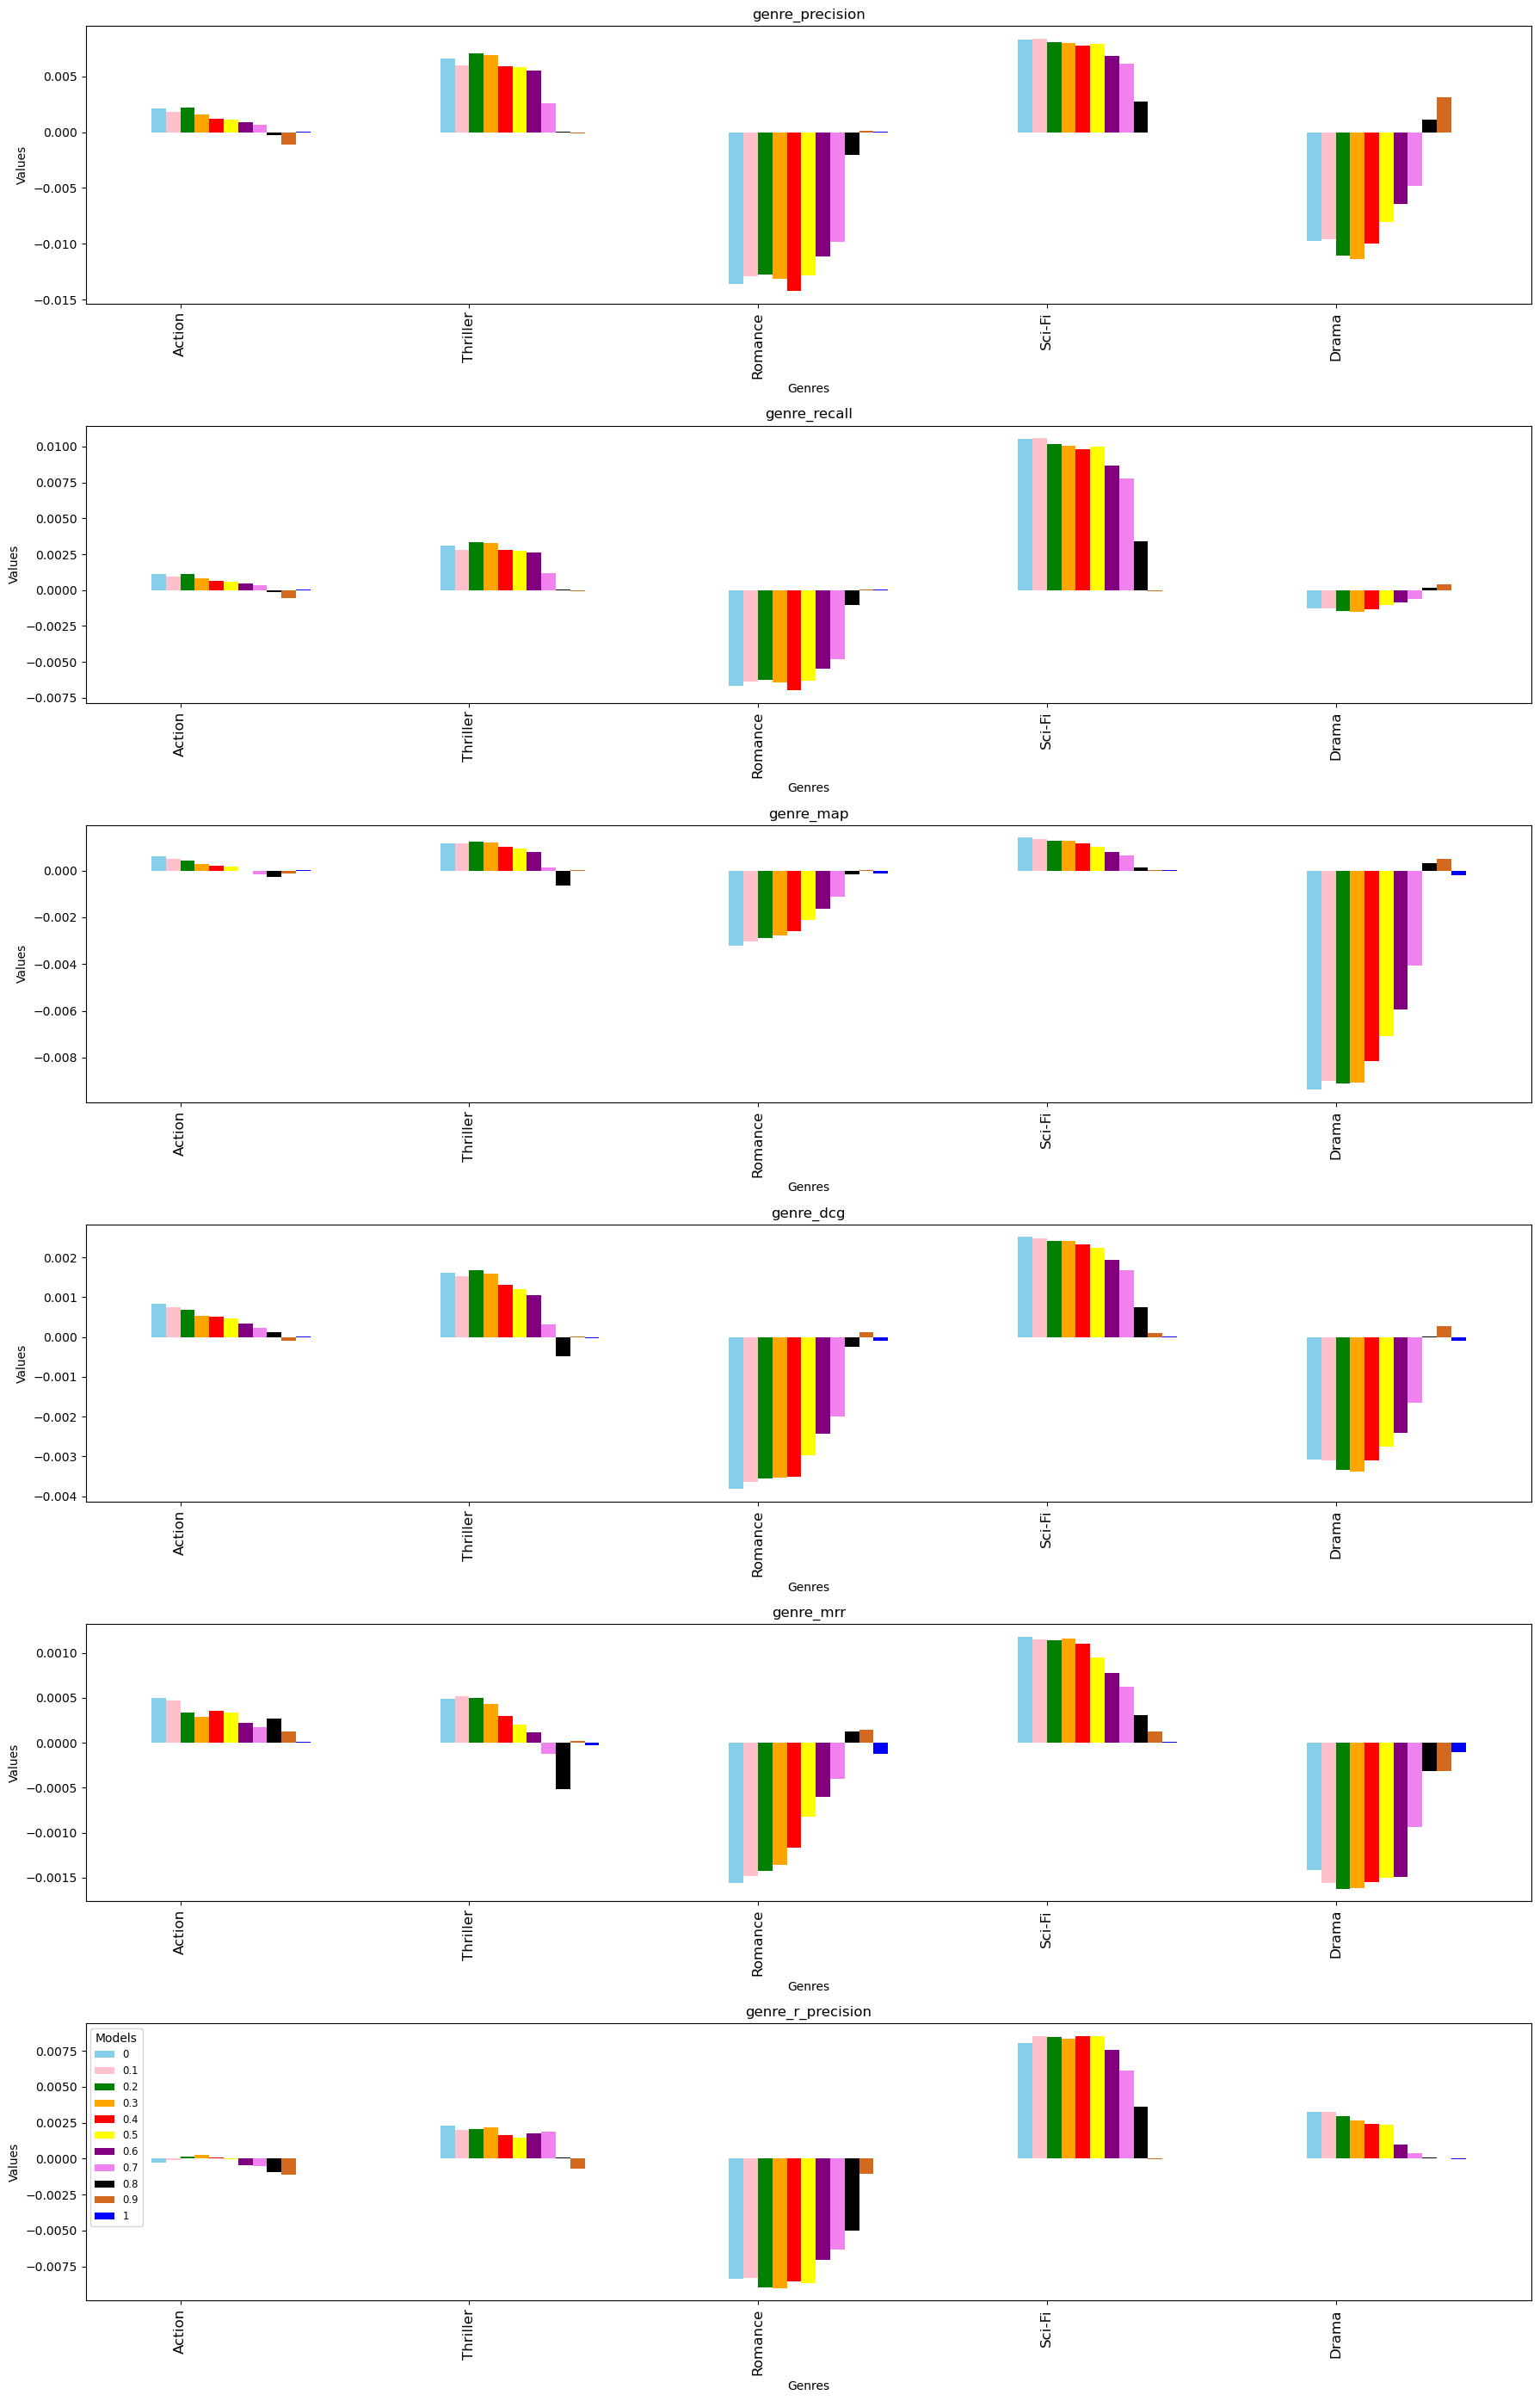

In [43]:
import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]
matrices_6 = [
    model_gps[5][indices],
    model_grs[5][indices],
    model_gms[5][indices],
    model_gdcgs[5][indices],
    model_gmrrs[5][indices],
    model_grps[5][indices],
]
matrices_7 = [
    model_gps[6][indices],
    model_grs[6][indices],
    model_gms[6][indices],
    model_gdcgs[6][indices],
    model_gmrrs[6][indices],
    model_grps[6][indices],
]
matrices_8 = [
    model_gps[7][indices],
    model_grs[7][indices],
    model_gms[7][indices],
    model_gdcgs[7][indices],
    model_gmrrs[7][indices],
    model_grps[7][indices],
]
matrices_9 = [
    model_gps[8][indices],
    model_grs[8][indices],
    model_gms[8][indices],
    model_gdcgs[8][indices],
    model_gmrrs[8][indices],
    model_grps[8][indices],
]
matrices_10 = [
    model_gps[9][indices],
    model_grs[9][indices],
    model_gms[9][indices],
    model_gdcgs[9][indices],
    model_gmrrs[9][indices],
    model_grps[9][indices],
]
matrices_11 = [
    model_gps[10][indices],
    model_grs[10][indices],
    model_gms[10][indices],
    model_gdcgs[10][indices],
    model_gmrrs[10][indices],
    model_grps[10][indices],
]
# matrices_12 = [
#     model_gps[11][indices],
#     model_grs[11][indices],
#     model_gms[11][indices],
#     model_gdcgs[11][indices],
#     model_gmrrs[11][indices],
#     model_grps[11][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label=alpha_values[0]
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label=alpha_values[1]
    )
    axs[i].bar(
        x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    )
    axs[i].bar(
        x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    )
    axs[i].bar(
        x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    )
    axs[i].bar(
        x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    )
    axs[i].bar(
        x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    )
    axs[i].bar(
        x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    )
    axs[i].bar(
        x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    )
    axs[i].bar(
        x + 15 * bar_width / 2,
        matrices_10[i],
        bar_width,
        color="chocolate",
       label=alpha_values[9]
    )
    axs[i].bar(
        x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    )
    # axs[i].bar(
    #     x + 19 * bar_width / 2, matrices_12[i], bar_width, color="blue", label=alpha_values[11]
    # )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="blue", label=alpha_values[12]
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]
matrices_6 = [
    model_gps[5][indices],
    model_grs[5][indices],
    model_gms[5][indices],
    model_gdcgs[5][indices],
    model_gmrrs[5][indices],
    model_grps[5][indices],
]
matrices_7 = [
    model_gps[6][indices],
    model_grs[6][indices],
    model_gms[6][indices],
    model_gdcgs[6][indices],
    model_gmrrs[6][indices],
    model_grps[6][indices],
]
matrices_8 = [
    model_gps[7][indices],
    model_grs[7][indices],
    model_gms[7][indices],
    model_gdcgs[7][indices],
    model_gmrrs[7][indices],
    model_grps[7][indices],
]
matrices_9 = [
    model_gps[8][indices],
    model_grs[8][indices],
    model_gms[8][indices],
    model_gdcgs[8][indices],
    model_gmrrs[8][indices],
    model_grps[8][indices],
]
matrices_10 = [
    model_gps[9][indices],
    model_grs[9][indices],
    model_gms[9][indices],
    model_gdcgs[9][indices],
    model_gmrrs[9][indices],
    model_grps[9][indices],
]
matrices_11 = [
    model_gps[10][indices],
    model_grs[10][indices],
    model_gms[10][indices],
    model_gdcgs[10][indices],
    model_gmrrs[10][indices],
    model_grps[10][indices],
]
matrices_12 = [
    model_gps[11][indices],
    model_grs[11][indices],
    model_gms[11][indices],
    model_gdcgs[11][indices],
    model_gmrrs[11][indices],
    model_grps[11][indices],
]
matrices_13 = [
    model_gps[12][indices],
    model_grs[12][indices],
    model_gms[12][indices],
    model_gdcgs[12][indices],
    model_gmrrs[12][indices],
    model_grps[12][indices],
]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label=alpha_values[0]
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label=alpha_values[1]
    )
    axs[i].bar(
        x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    )
    axs[i].bar(
        x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    )
    axs[i].bar(
        x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    )
    axs[i].bar(
        x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    )
    axs[i].bar(
        x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    )
    axs[i].bar(
        x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    )
    axs[i].bar(
        x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    )
    axs[i].bar(
        x + 15 * bar_width / 2,
        matrices_10[i],
        bar_width,
        color="chocolate",
       label=alpha_values[9]
    )
    axs[i].bar(
        x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    )
    axs[i].bar(
        x + 19 * bar_width / 2, matrices_12[i], bar_width, color="blue", label=alpha_values[11]
    )
    axs[i].bar(
        x + 21 * bar_width / 2, matrices_13[i], bar_width, color="blue", label=alpha_values[12]
    )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
model_gdcgs.__len__()

In [44]:


all_values = [
    ["a=0 mf", 0.9496, 0.5751, 0.6638, 0.0519, 0.1983, 0.0942, 0.0462, 0.1156, 4.0811, 0.5796],
    ["a=0.1 mf", 0.9487, 0.5746, 0.6628, 0.0521, 0.1983, 0.0946, 0.0467, 0.1163, 78.9054, 0.5221],
    ["a=0.2 mf", 0.9481, 0.5740, 0.6649, 0.0523, 0.2007, 0.0957, 0.0474, 0.1178, 74.9921, 0.5396],
    ["a=0.3 mf", 0.9476, 0.5731, 0.6670, 0.0528, 0.2024, 0.0967, 0.0480, 0.1195, 77.3394, 0.5548],
    ["a=0.4 mf", 0.9477, 0.5717, 0.6702, 0.0529, 0.2021, 0.0977, 0.0487, 0.1217, 79.6838, 0.6393],
    ["a=0.5 mf", 0.9488, 0.5699, 0.6755, 0.0529, 0.1971, 0.0976, 0.0492, 0.1224, 80.1330, 0.6858],
    ["a=0.6 mf", 0.9516, 0.5669, 0.6596, 0.0517, 0.1838, 0.0954, 0.0494, 0.1223, 79.4244, 0.5781],
    ["a=0.7 mf", 0.9573, 0.5617, 0.6458, 0.0505, 0.1734, 0.0934, 0.0495, 0.1223, 79.2458, 0.5635],
    ["a=0.8 mf", 0.9680, 0.5529, 0.6288, 0.0496, 0.1623, 0.0900, 0.0478, 0.1194, 107.8650, 0.5947],
    ["a=0.9 mf", 0.9900, 0.5412, 0.6108, 0.0509, 0.1531, 0.0903, 0.0460, 0.1204, 2601.1016, 0.6456],
    ["a=1 mf", 1.1290, 0.0001, 0.5695, 0.0182, 0.0816, 0.0441, 0.0300, 0.0590, 8355.3494, 0.5074]
]


rmse_values_extracted = [values[1] for values in all_values]
auc_values_extracted = [values[2] for values in all_values]


In [45]:
rmse_values_extracted

[0.9496,
 0.9487,
 0.9481,
 0.9476,
 0.9477,
 0.9488,
 0.9516,
 0.9573,
 0.968,
 0.99,
 1.129]

In [46]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [47]:
gp_sum

[0.07989311683341535,
 0.07696446704207899,
 0.08193308184352963,
 0.08165763854719083,
 0.07856556412078809,
 0.07010423705647588,
 0.06691288247407652,
 0.05404539937674262,
 0.028792754177828787,
 0.009274138465183265,
 0.000882335574872873]

In [ ]:
gp_sum

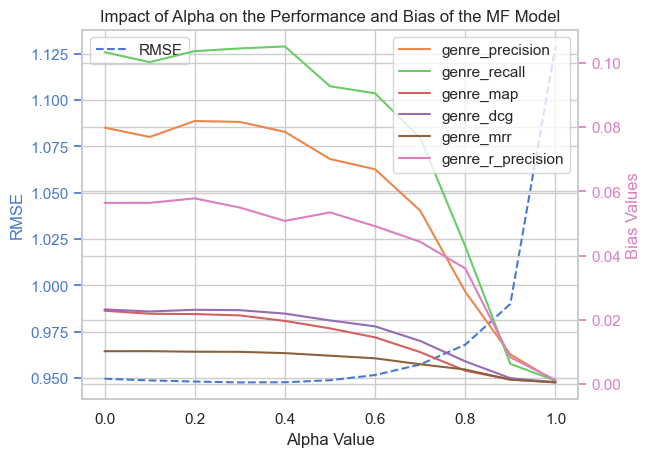

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns


x = alpha_values
upper_bound = 13

sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()

ax1.plot(x[0:upper_bound], rmse_values_extracted[0:upper_bound], linestyle="--", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("RMSE", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.show()


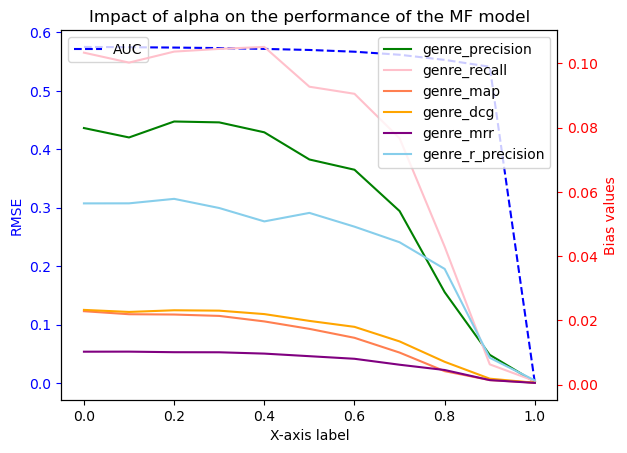

In [49]:
import matplotlib.pyplot as plt

# Sample data
x = alpha_values


# Data for the primary y-axis
# Data for the secondary y-axis

# Create a figure and a set of subplots
fig, ax1 = plt.subplots()
upper_bound=13
# Plot data on the primary y-axis
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound],color= "skyblue", label="AUC")
ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], "b--", label="AUC")
ax1.set_xlabel("X-axis label")
ax1.set_ylabel("RMSE", color="b")
ax1.tick_params("y", colors="b")

# Create a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color="green")
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color="pink")
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color="coral")
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color="orange")
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color="purple")
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color="skyblue")
ax2.set_ylabel("Bias values", color="r")
ax2.tick_params("y", colors="r")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Show the plot
plt.title("Impact of alpha on the performance of the MF model")
plt.show()

In [ ]:
top_k = 20
reco_matrix_n = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(reco_matrix[0].shape[0]):
    reco_matrix_n[i] = reco_matrix[1][i][:top_k]

reco_matrix_n.shape

In [ ]:
reco_matrix[1].shape[0]
# top_k = 50
# reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
# for i in range(reco_matrix_all_items.shape[0]):
#     reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [ ]:
sum(model_gdcg_2)

In [ ]:
# np.where(reco_matrix_mapped_items[1][0]==0)
# reco_matrix_all[1][0][258]
reco_matrix_mapped_scores[1][1][1552]

# reco_matrix_mapped_items[1][1][1552]
# reco_matrix_mapped_items[1][0][258]
# reco_items_scores_all[0]
# mapped_item_index

In [ ]:
reco_items_scores_all[0][0]
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# unique_genres = ['Crime',
#  'Film-Noir',
#  'Adventure',
#  'Fantasy',
#  'Sci-Fi',
#  'Documentary',
#  'Drama',
#  'Horror',
#  'War',
#  'Animation',
#  'Romance',
#  "Children's",
#  'Western',
#  'Mystery',
#  'Thriller',
#  'Musical',
#  'Action',
#  'Comedy']

In [ ]:
# tahsin kheya
# last modified 21/07/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger
import random


class Calibration(object):
    def __init__(self, config, movies, top_k, unique_genres, users):
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(self.device)
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []

        # self.logger = getLogger()
        self.top_k = top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.unique_genres = list(self.actual_genre_dist.columns)[1:]

        # self.actual_genre_dist = self.actual_genre_dist.drop(columns=["userID"])

        self.config = config
        self.item_df = movies
        self.actual_distribution_without_id = self.actual_genre_dist.drop(
            columns=["userID"]
        ).to_numpy()
        print(self.unique_genres)
        # print(self.actual_distribution_without_id)

        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(topk_reco.shape[0]), self.top_k),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(np.arange(1, self.top_k + 1), topk_reco.shape[0]),
            }
        )

        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[self.unique_genres].div(
            merged_df[self.unique_genres].sum(axis=1), axis=0
        )

        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None] * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        #         reco_distribution[self.unique_genres] = reco_distribution[
        #             self.unique_genres
        #         ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):

        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))

        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        #         print(item_genre_weights)
        # Normalize genre weights so sum is 1
        #         item_genre_weights /= torch.sum(item_genre_weights, axis=1, keepdims=True)

        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)

        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    # def get_gender_representation_one_user(self, reco_dist, uid):
    #     c = []
    #     retVal = []
    #     print(self.actual_distribution[uid])

    #     for i in range(len(self.unique_genres)):
    #         c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
    #     # Assuming self.unique_genres is a list or array-like
    #     genre_columns_count = len(self.unique_genres)

    #     reco_dist_slice = reco_dist[:genre_columns_count]
    #     actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

    #     log_ratios = np.log(reco_dist_slice / actual_dist_slice)
    #     retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
        #
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])
        # print(f"reco item {reco_items}, genre_dist_actual_user {self.actual_distribution_without_id[uid]}, reco genre distribution {reco_dist}")
        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution_without_id[uid], alpha, uid
        )

        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids = self.gender_df[self.gender_df["Gender"] == 0]["userID"]
        male_user_ids = male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        # gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)
        gender_kl = 0

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[reco_items[r]]

        # print(f"genderkl {gender_kl}, kl {kl} score{sum_score}")

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")
        # print(f"score {sum_score}, kl {kl}, gender_kl {gender_kl}")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl

    # c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items, items, scores):

        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(
            reco=top_items, scores=scores, all_items=items
        )

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(
            self.actual_genre_dist, self.gender_df, on="userID"
        )
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores, all_items):
        """reco is 6040x50 and scores is 6040x3416"""

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        #####
        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        b = 0.69  # beta
        l = 0.29  # lambda
        all_users = []

        #####

        top_k = self.top_k

        n_users, n_items = all_items.shape

        for u in range(0, 50):
            # remaining_items = all_items
            remaining_items = list(all_items[u])
            # print(remaining_items)

            #             u_calibrated = [623, 1612, 558, 1087, 1347, 3368, 196, 3256, 3127, 882, 831, 1271, 1870, 2594, 3279, 2624, 393, 1496, 3099, 2414, 1232, 1773, 1313, 610, 500, 2855, 1973, 1872, 3334, 3296, 649, 769, 1573, 2474, 2133, 2161, 3387, 2640, 1583, 3287, 753, 384, 2192, 709, 1981, 3311 ]
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores[u], user_reco_dist, b
                    )
                    for i in remaining_items
                ]
                max_index = np.argmax(diversity_scores)

                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)

In [ ]:
reco_matrix_all[1].shape

In [ ]:
score_dicts[1][889]
reco_matrix_all[1][0][0]
score_dicts[1][0]

In [ ]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file": "./cornac/data_c/user_genre_dist_new.csv"}
c = Calibration(
    config=config, movies=movies, top_k=50, unique_genres=unique_genres, users=users
)
# for itemknn

reranked_reco = c.get_improved_reco(reco_matrix[1], reco_matrix_all[1], score_dicts)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)

    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if movies.at[index, genre] == 1:
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd, movies, how="inner", on="itemID")
mergde_pd

In [ ]:
user_genre_means = mergde_pd.groupby("userID")[unique_genres].mean()
user_genre_means

In [ ]:
users

In [ ]:
useer = pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z = inter_movies[["userID", "itemID", "Gender"]]
mergz = pd.merge(z, movies, on="itemID", how="left")
mergz
user_genre_gender = mergz.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="feMale (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="female (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv("biased_movie_lens.csv")

In [ ]:
movies_df

In [ ]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)np.save('reco_items_scores_all.npy' , reco_matrix_all_edited)

#reco_matrix_all_items